# Single-Run Deep Dive — Same-Ren vs Different-Ren at Matched Model Size

The two methodologies reduce a different fraction of their original scenario
tree, so comparing runs with the same *original* scenario count (as the
batch-analysis section further below does) compares runs that actually solve
different-sized models. This section instead compares the two methods at the
**same effective model size** — the same number of *reduced* (post-selection)
scenarios actually solved — by picking the largest `num_scenarios_reduced`
value achieved by an `ok` run of **both** methods.

Among completed runs, the common reduced-scenario counts are
`{55, 76, 108, 146}`; the maximum, **146**, is reached by:

- **Same-Ren**: `sc=560` (560 → 146 reduced) — `results/FTC_20251031_20251130_c30_sc560_15min_same_ren/DA`
- **Different-Ren**: `sc=170` (170 → 146 reduced) — `results/FTC_20251031_20251130_c30_sc170_15min_different_ren/DA`

The two sub-sections below run the full single-run analyzer (Fig 1–9,
descriptive stats, correlation heatmap, commitment-failure dashboard) once
per method against these two folders, so their detailed operational
behavior can be compared directly at matched model size.


# MSSP Results Analyzer — Same-Ren (sc=560 → 146 reduced scenarios)
*Matched-reduced-scenario comparison, method A of 2 — see intro above. Reduced scenarios in model: **146** (from 560 original).*
### Energy System Market Analysis

**Variables:**
| Group | Variables |
|---|---|
| Flexible Demand | `var_fd`, `var_afd_p`, `var_afd_m` |
| Generation | `pPV`, `pW` |
| BESS | `cV_dV` (net charge rate), `idV` (state), `socV` (SoC) |
| Day-Ahead | `eDA_p`, `eDA_m`, `ieDA_p`, `ieDA_m` |
| Reserves | `rU`, `rD`, `rU_B`, `rD_B`, `rU_FD`, `rD_FD` |
| Imbalance | `eIM`, `eIM1`,`eIM2`, `eIM3`, `pIB_m`, `pIB_p` |

**Data format expected:** one CSV per variable — rows = time steps, columns = scenarios.  
CI bands show P10–P90 across scenarios unless otherwise noted.


## 0 · Imports & Setup

In [1]:
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator
from scipy import stats

warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})
print("Libraries loaded ✓")


Libraries loaded ✓


## 1 · Configuration

Edit the block below to point to your data. Three loading modes are supported:
- **Option A** – one CSV per variable (rows = timesteps, cols = scenarios) → set `data_dir`
- **Option B** – single wide CSV with `(variable, scenario)` MultiIndex columns → set `single_csv`
- **Option C** – HDF5 store with variable names as keys → set `hdf5_file`

If no files are found the script falls back to **synthetic data** so every cell runs out-of-the-box.


In [2]:
CONFIG = dict(
    # ── Data location ─────────────────────────────────────────────────────
    data_dir   = "results/FTC_20251031_20251130_c30_sc560_15min_same_ren/DA",
    file_ext   = ".txt",       # Option A: folder with one TXT per variable (nested dirs allowed)
    single_csv = None,         # Option B: path to wide CSV
    hdf5_file  = None,         # Option C: path to HDF5

    # ── Time axis ─────────────────────────────────────────────────────────
    n_periods    = 24,         # number of time steps (e.g. 24 h)
    period_label = "Hour",     # x-axis label

    # ── CI percentiles ────────────────────────────────────────────────────
    ci_low  = 10,
    ci_high = 90,

    # ── Save figures ──────────────────────────────────────────────────────
    save_figs  = False,        # set True to export PNGs
    fig_dir    = "figures/",
    fig_format = "png",
    dpi        = 150,
)

UNITS = {
    "var_fd":"MW",  "var_afd_p":"MW",  "var_afd_m":"MW",
    "pPV":"MW",     "pW":"MW",
    "cV_dV":"MW",   "idV":"–",         "socV":"MWh",
    "eDA_p":"MWh",  "eDA_m":"MWh",     "ieDA_p":"MWh",  "ieDA_m":"MWh",
    "rU":"MW",      "rD":"MW",
    "rU_B":"MW",    "rD_B":"MW",       "rU_FD":"MW",    "rD_FD":"MW",
    "eIM":"MWh", "eIM_1":"MWh", "eIM_2":"MWh", "eIM_3":"MWh",    "pIB_m":"MWh",     "pIB_p":"MWh",
}

COLORS = dict(
    median="#1a1a2e", ci_fill="#4a90d9",
    pos="#27ae60",    neg="#e74c3c",
    bess="#8e44ad",   pv="#f39c12",
    wind="#2980b9",   reserve="#16a085",
    imbal="#c0392b",  fd="#d35400",
    da="#2c3e50",
)
print("Configuration set ✓")


Configuration set ✓


## 2 · Data Loader

In [3]:
def _synthetic_data(cfg):
    """Fallback synthetic data – replace with real loader if needed."""
    rng = np.random.default_rng(42)
    T, S = cfg["n_periods"], 50
    t = np.linspace(0, 2*np.pi, T)
    scen = [f"s{i:03d}" for i in range(S)]
    data = {}

    def _df(base, noise=0.15, lo=None, hi=None):
        mat = base[:,None] + rng.normal(0, noise*(np.abs(base).mean()+0.01), (T,S))
        if lo is not None: mat = np.clip(mat, lo, None)
        if hi is not None: mat = np.clip(mat, None, hi)
        return pd.DataFrame(mat, columns=scen)

    solar = np.maximum(0, np.sin(t - np.pi/3))
    wind  = 0.4 + 0.3*np.sin(2*t + 0.5)
    dem   = 1.0 + 0.4*np.sin(t - np.pi/2)
    sf_b  = np.where(rng.random(T) > 0.75, rng.uniform(0,0.3,T), 0)

    data["pPV"]      = _df(solar*2.0, lo=0)
    data["pW"]       = _df(wind*1.5,  lo=0)
    data["socV"]     = _df(0.5+0.3*np.sin(t), noise=0.05, lo=0, hi=1.0)
    data["cV_dV"]    = _df(0.3*np.sin(t+1.0), noise=0.2)
    data["idV"]      = pd.DataFrame((rng.random((T,S))>0.5).astype(float), columns=scen)
    data["var_fd"]   = _df(dem, lo=0)
    data["var_afd_p"]= _df(np.abs(0.1*np.sin(t)), lo=0)
    data["var_afd_m"]= _df(np.abs(0.1*np.cos(t)), lo=0)
    eDA              = dem*0.9
    data["eDA_p"]    = _df(eDA, lo=0)
    data["eDA_m"]    = _df(eDA*0.1, lo=0)
    data["ieDA_p"]   = _df(sf_b, noise=0.3, lo=0)
    data["ieDA_m"]   = _df(sf_b*0.5, noise=0.3, lo=0)
    data["rU"]       = _df(0.2+0.1*np.sin(t), lo=0)
    data["rD"]       = _df(0.2+0.1*np.cos(t), lo=0)
    data["rU_B"]     = _df(0.1*np.abs(np.sin(t)), lo=0)
    data["rD_B"]     = _df(0.1*np.abs(np.cos(t)), lo=0)
    data["rU_FD"]    = _df(0.1*np.abs(np.sin(t+0.5)), lo=0)
    data["rD_FD"]    = _df(0.1*np.abs(np.cos(t+0.5)), lo=0)
    data["eIM"]      = _df(0.05*np.sin(3*t))
    data["pIB_p"]    = _df(sf_b*0.8, noise=0.4, lo=0)
    data["pIB_m"]    = _df(sf_b*0.6, noise=0.4, lo=0)
    return data

def load_data(cfg):
    data = {}
    if cfg.get("hdf5_file") and os.path.exists(cfg["hdf5_file"]):
        with pd.HDFStore(cfg["hdf5_file"], mode="r") as s:
            for k in s.keys():
                data[k.lstrip("/").replace("-","_")] = s[k]
        return data
    if cfg.get("single_csv") and os.path.exists(cfg["single_csv"]):
        wide = pd.read_csv(cfg["single_csv"], header=[0,1], index_col=0)
        for v in wide.columns.get_level_values(0).unique():
            data[v.replace("-","_")] = wide[v]
        return data
    files = glob.glob(os.path.join(cfg["data_dir"], "**", f"*{cfg['file_ext']}"), recursive=True)
    if not files:
        print("⚠️  No result files found – using SYNTHETIC data.")
        return _synthetic_data(cfg)

    # MMOBEC 15-min block files: one scenario is stored as n_periods rows.
    # First row of each block starts with: scenario probability q1 q2 ... qN.
    BLOCK_TXT_VARS = {
        "lPIB", "lNIB", "pIB_p", "pIB_m", "lI_1", "lI_2", "lI_3",
        "eDA_p", "eDA_m", "pW", "pPV", "dV", "cV", "var_fd", "eIM",
        "eIM_1", "eIM_2", "eIM_3",
    }

    def _scen_name(val):
        try:
            return f"s{int(float(val)):03d}"
        except Exception:
            return str(val)

    def _wide_from_matrix(values, scen_names, n_q=None):
        values = values.astype(float).T
        values.columns = scen_names
        n_t_cfg = int(cfg.get("n_periods", 24))
        if n_q is None and values.shape[0] % n_t_cfg == 0:
            n_q = values.shape[0] // n_t_cfg
        if n_q and values.shape[0] % n_q == 0:
            n_t = values.shape[0] // n_q
            values.index = pd.MultiIndex.from_tuples(
                [(t, q) for t in range(1, n_t + 1) for q in range(1, n_q + 1)],
                names=["t", "q"],
            )
        else:
            values.index = np.arange(1, values.shape[0] + 1)
        return values

    def _load_block_txt(path, name):
        rows = []
        with open(path, "r", encoding="utf-8") as fh:
            for line in fh:
                line = line.strip()
                if line and not line.startswith("#"):
                    rows.append(line.split())
        if not rows:
            return None

        n_t = int(cfg.get("n_periods", 24))
        i = 0
        scen_names, vectors = [], []
        while i < len(rows):
            header = rows[i]
            if len(header) < 3 or i + n_t > len(rows):
                return None
            scenario = header[0]
            first_period_values = [float(x) for x in header[2:]]
            n_q = len(first_period_values)
            vector = first_period_values[:]

            for j in range(1, n_t):
                period_values = [float(x) for x in rows[i + j]]
                if len(period_values) != n_q:
                    return None
                vector.extend(period_values)

            scen_names.append(_scen_name(scenario))
            vectors.append(vector)
            i += n_t

        cfg.setdefault("_txt_subperiods", {})[name] = n_q
        return _wide_from_matrix(pd.DataFrame(vectors, index=scen_names), scen_names, n_q=n_q)

    def _load_txt(path, name):
        if name in BLOCK_TXT_VARS:
            block_df = _load_block_txt(path, name)
            if block_df is not None:
                return block_df

        df = pd.read_csv(path, sep=r"\s+", header=None, comment="#", engine="python")
        if df.shape[1] <= 2 or df.shape[0] < 2:
            return None
        scen_names = [_scen_name(v) for v in df.iloc[:, 0]]
        values = df.iloc[:, 2:].astype(float)
        return _wide_from_matrix(values, scen_names)

    for f in sorted(files):
        base = os.path.splitext(os.path.basename(f))[0]
        if base.endswith("_params") or base in {"numscen", "profit_ec", "time_ec", "pIB_p-pIB_m", "solver_log", "scenarios", "tree"}:
            continue
        name = base.replace("-","_")
        if name == "eIM_TOT":
            name = "eIM"

        df = _load_txt(f, name)
        if df is None:
            continue
        data[name] = df
    return data

# ── helpers ──────────────────────────────────────────────────────────────────
def _t(df):
    if isinstance(df.index, pd.MultiIndex) and {"t", "q"}.issubset(df.index.names):
        t_vals = df.index.get_level_values("t").astype(float).to_numpy()
        q_vals = df.index.get_level_values("q").astype(float).to_numpy()
        n_q = max(1, int(df.index.get_level_values("q").nunique()))
        return t_vals + (q_vals - 1) / n_q
    return np.arange(1, df.shape[0] + 1)

def _format_hour_axis(ax, t=None):
    n_periods = int(CONFIG.get("n_periods", 24))
    ticks = np.arange(1, n_periods + 1)
    ax.set_xticks(ticks)
    ax.set_xticklabels([str(i) for i in ticks])
    ax.set_xlim(1, n_periods + 1 - 1 / max(1, int(CONFIG.get("_active_n_q", 1))))

def _operational_ts_data(data, ref_names=("socV", "cV", "pIB_p", "pPV")):
    """Keep variables that share the operational (t, q) time index."""
    ref = next((data[name] for name in ref_names if name in data), None)
    if ref is None:
        return {}
    return {
        name: df
        for name, df in data.items()
        if isinstance(df, pd.DataFrame) and df.index.equals(ref.index)
    }


def _ci(df, lo=None, hi=None):
    lo = lo or CONFIG["ci_low"]; hi = hi or CONFIG["ci_high"]
    return df.median(axis=1).values, np.percentile(df.values,lo,axis=1), np.percentile(df.values,hi,axis=1)

def _band(ax, t, df, color, label, alpha=0.18, lw=2, lo=None, hi=None):
    med, low, high = _ci(df, lo, hi)
    ax.fill_between(t, low, high, color=color, alpha=alpha, zorder=1)
    ax.plot(t, med, color=color, lw=lw, label=label, zorder=2)
    _format_hour_axis(ax, t)
    return med, low, high

def _annotate_socv_initial(ax):
    init = data_meta.get("socV_initial")
    if init is None:
        return
    init_mean = float(init.mean())
    ax.axhline(init_mean, color=COLORS["bess"], lw=1.2, ls=":", alpha=0.9,
               label=f"Initial SoC mean ({init_mean:.3f})")


def _save(fig, name):
    if CONFIG["save_figs"]:
        os.makedirs(CONFIG["fig_dir"], exist_ok=True)
        fig.savefig(os.path.join(CONFIG["fig_dir"], f"{name}.{CONFIG['fig_format']}"),
                    dpi=CONFIG["dpi"], bbox_inches="tight")

# ── LOAD ─────────────────────────────────────────────────────────────────────
data = load_data(CONFIG)
data_meta = {}

def _trim_initial_socv(data):
    """socV is saved with one extra initial state; plots use only operational steps."""
    if "socV" not in data:
        return data
    ref_name = next((name for name in ["cV", "dV", "cV_dV", "pIB_p"] if name in data), None)
    if ref_name is None:
        return data

    soc = data["socV"]
    ref = data[ref_name]
    if soc.shape[0] == ref.shape[0] + 1:
        data_meta["socV_initial"] = soc.iloc[0].copy()
        soc_plot = soc.iloc[1:].copy()
        if len(soc_plot) == len(ref):
            soc_plot.index = ref.index
        data["socV"] = soc_plot
        if isinstance(soc_plot.index, pd.MultiIndex) and "q" in soc_plot.index.names:
            CONFIG["_active_n_q"] = int(soc_plot.index.get_level_values("q").nunique())
        init_mean = data_meta["socV_initial"].mean()
        print(f"Dropped initial socV state for plots: socV now shape={data['socV'].shape}; initial mean={init_mean:.4f}")
    return data

data = _trim_initial_socv(data)
print(f"Variables loaded ({len(data)}): {sorted(data.keys())}")
for v, df in sorted(data.items()):

    print(f"  {v:<14} shape={df.shape}   NaN={df.isna().sum().sum()}")

Dropped initial socV state for plots: socV now shape=(96, 146); initial mean=0.4000
Variables loaded (33): ['cV', 'cV_dV', 'dV', 'eDA_m', 'eDA_p', 'eIM', 'eIM_1', 'eIM_2', 'eIM_3', 'idV', 'ieDA_m', 'ieDA_p', 'lD', 'lI_1', 'lI_2', 'lI_3', 'lNIB', 'lPIB', 'lR', 'pIB_m', 'pIB_p', 'pPV', 'pW', 'rD', 'rD_B', 'rD_FD', 'rU', 'rU_B', 'rU_FD', 'socV', 'var_afd_m', 'var_afd_p', 'var_fd']
  cV             shape=(96, 146)   NaN=0
  cV_dV          shape=(96, 146)   NaN=0
  dV             shape=(96, 146)   NaN=0
  eDA_m          shape=(96, 146)   NaN=0
  eDA_p          shape=(96, 146)   NaN=0
  eIM            shape=(96, 146)   NaN=0
  eIM_1          shape=(96, 146)   NaN=0
  eIM_2          shape=(96, 146)   NaN=0
  eIM_3          shape=(96, 146)   NaN=0
  idV            shape=(96, 146)   NaN=0
  ieDA_m         shape=(96, 146)   NaN=0
  ieDA_p         shape=(96, 146)   NaN=0
  lD             shape=(96, 146)   NaN=0
  lI_1           shape=(96, 146)   NaN=0
  lI_2           shape=(96, 146)   NaN=0
  lI

## 2b ? How `pIB_p` and `pIB_m` are calculated

The model defines both variables as non-negative and enforces this balance in `model_builder.py`:

`pIB_p[t,q,s] - pIB_m[t,q,s] = eDA_m + pW + pPV + dV*dQ - eDA_p - eIM - var_fd - cV*dQ`

Therefore the saved values are the positive and negative parts of the same net imbalance:

- `pIB_p = max(balance, 0)`
- `pIB_m = max(-balance, 0)`

If hydrogen variables are loaded, the model also adds `+ eFC_on - eEL - eCOMP + eFC_sb` to the balance.


In [4]:
try:
    display
except NameError:
    display = print

def _align_for_calc(data, names):
    dfs = [data[n] for n in names if n in data]
    if not dfs:
        return {}
    common_index = dfs[0].index
    common_cols = dfs[0].columns
    for df in dfs[1:]:
        common_index = common_index.intersection(df.index)
        common_cols = common_cols.intersection(df.columns)
    return {n: data[n].loc[common_index, common_cols] for n in names if n in data}

needed = ["eDA_m", "pW", "pPV", "dV", "eDA_p", "eIM", "var_fd", "cV"]
available = _align_for_calc(data, needed + ["eFC_on", "eEL", "eCOMP", "eFC_sb", "pIB_p", "pIB_m"])
missing = [n for n in needed if n not in available]

if missing:
    print("Cannot recalculate pIB_p/pIB_m. Missing variables:", missing)
else:
    sample_df = available[needed[0]]
    if isinstance(sample_df.index, pd.MultiIndex) and "q" in sample_df.index.names:
        n_q = sample_df.index.get_level_values("q").nunique()
    else:
        n_q = max(1, sample_df.shape[0] // CONFIG["n_periods"])
    dQ = 1 / n_q

    balance = (
        available["eDA_m"]
        + available["pW"]
        + available["pPV"]
        + available["dV"] * dQ
        - available["eDA_p"]
        - available["eIM"]
        - available["var_fd"]
        - available["cV"] * dQ
    )
    if {"eFC_on", "eEL", "eCOMP", "eFC_sb"}.issubset(available):
        balance = balance + available["eFC_on"] - available["eEL"] - available["eCOMP"] + available["eFC_sb"]

    pIB_p_calc = balance.clip(lower=0)
    pIB_m_calc = (-balance).clip(lower=0)

    print(f"Detected n_q={n_q}; using dQ={dQ:.4f}")
    display(pd.DataFrame({
        "balance_mean": balance.mean(axis=1),
        "pIB_p_calc_mean": pIB_p_calc.mean(axis=1),
        "pIB_m_calc_mean": pIB_m_calc.mean(axis=1),
    }).head(12))

    if "pIB_p" in available and "pIB_m" in available:
        print("Absolute error vs stored pIB_p:")
        display((available["pIB_p"] - pIB_p_calc).abs().stack().describe())
        print("Absolute error vs stored pIB_m:")
        display((available["pIB_m"] - pIB_m_calc).abs().stack().describe())


Detected n_q=4; using dQ=0.2500


balance_mean  pIB_p_calc_mean  pIB_m_calc_mean
t q                                                
1 1     -0.001781     1.752023e-15         0.001781
  2     -0.021547     6.387585e-16         0.021547
  3     -0.051205     4.015053e-16         0.051205
  4     -0.050861     5.475072e-17         0.050861
2 1     -0.002094     8.119129e-03         0.010213
  2     -0.019139     1.279623e-03         0.020418
  3     -0.047139     9.736504e-15         0.047139
  4     -0.056653     4.258390e-17         0.056653
3 1     -0.004239     7.756353e-16         0.004239
  2     -0.012536     7.604267e-16         0.012536
  3     -0.012812     1.733773e-16         0.012812
  4     -0.026861     6.205082e-16         0.026861

Absolute error vs stored pIB_p:


count    1.401600e+04
mean     1.261822e-15
std      7.352308e-15
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      3.428438e-13
dtype: float64

Absolute error vs stored pIB_m:


count    1.401600e+04
mean     1.982274e-11
std      1.361441e-09
min      0.000000e+00
25%      0.000000e+00
50%      1.804112e-16
75%      1.665335e-15
max      9.920635e-08
dtype: float64

## 3 · Descriptive Statistics

Summary table: mean, std, min, P10, median, P90, max, % zeros and % negatives across all time steps and scenarios.

In [5]:
rows = []
for var, df in sorted(data.items()):
    flat = df.values.flatten()
    rows.append({
        "Variable" : var,
        "Unit"     : UNITS.get(var,"–"),
        "T"        : df.shape[0],
        "S"        : df.shape[1],
        "Mean"     : np.nanmean(flat),
        "Std"      : np.nanstd(flat),
        "Min"      : np.nanmin(flat),
        "P10"      : np.nanpercentile(flat,10),
        "Median"   : np.nanmedian(flat),
        "P90"      : np.nanpercentile(flat,90),
        "Max"      : np.nanmax(flat),
        "% zero"   : 100*np.mean(flat==0),
        "% neg"    : 100*np.mean(flat<0),
    })

summary = pd.DataFrame(rows).set_index("Variable")
pd.set_option("display.float_format", "{:.4f}".format)
display(summary)


,Unit,T,S,Mean,Std,Min,P10,Median,P90,Max,% zero,% neg
Variable,,,,,,,,,,,,
cV,–,96,146,0.3604,0.9389,0.0000,0.0000,0.0000,3.0000,3.0000,80.2012,0.0000
cV_dV,MW,96,146,-0.0871,1.5134,-3.0000,-3.0000,0.0000,3.0000,3.0000,63.7486,16.4526
dV,–,96,146,0.4474,1.0423,0.0000,0.0000,0.0000,3.0000,3.0000,83.5474,0.0000
eDA_m,MWh,96,146,6.2744,3.4169,2.3220,2.5607,4.2720,10.2200,10.7000,0.0000,0.0000
eDA_p,MWh,96,146,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,100.0000,0.0000
eIM,MWh,96,146,0.4477,2.1000,-2.6463,-1.7064,-0.6597,3.5759,4.9950,0.0000,53.1393
eIM_1,MWh,96,146,0.2370,1.5933,-2.2505,-1.5760,0.0000,3.4803,4.9950,37.1932,26.3199
eIM_2,MWh,96,146,-0.1992,1.4742,-2.6463,-1.5778,0.0000,0.6340,4.9950,40.7035,44.1281
eIM_3,MWh,96,146,0.4099,1.8697,-2.6405,-1.6553,0.0000,3.4120,4.9950,48.1378,27.2974


### Per-timestep spread (mean over scenarios → variability over time)

In [6]:
spread = []
for var, df in sorted(data.items()):
    spread.append({
        "Variable"          : var,
        "Unit"              : UNITS.get(var,"–"),
        "Time-mean of mean" : df.mean(axis=1).mean(),
        "Std of mean"       : df.mean(axis=1).std(),
        "Avg scen spread"   : df.std(axis=1).mean(),
        "Max scen spread"   : df.std(axis=1).max(),
    })
pd.DataFrame(spread).set_index("Variable")


,Unit,Time-mean of mean,Std of mean,Avg scen spread,Max scen spread
Variable,,,,,
cV,–,0.3604,0.8845,0.1466,1.2977
cV_dV,MW,-0.0871,1.4044,0.3884,1.3774
dV,–,0.4474,0.9299,0.2508,1.3774
eDA_m,MWh,6.2744,3.3402,0.3443,2.8578
eDA_p,MWh,0.0000,0.0000,0.0000,0.0000
eIM,MWh,0.4477,1.9245,0.6093,2.7941
eIM_1,MWh,0.2370,1.1241,0.9235,2.4114
eIM_2,MWh,-0.1992,0.9867,0.8843,2.4458
eIM_3,MWh,0.4099,1.6384,0.5508,2.3373


## 4 · Fig 1 – Renewable Generation & BESS SoC

**What to look for:**
- Width of the CI band → how uncertain is each generation source.
- SoC dip/peak alignment with PV peak → confirms solar-driven charging.
- If SoC CI is wide, the BESS dispatch varies significantly across scenarios.


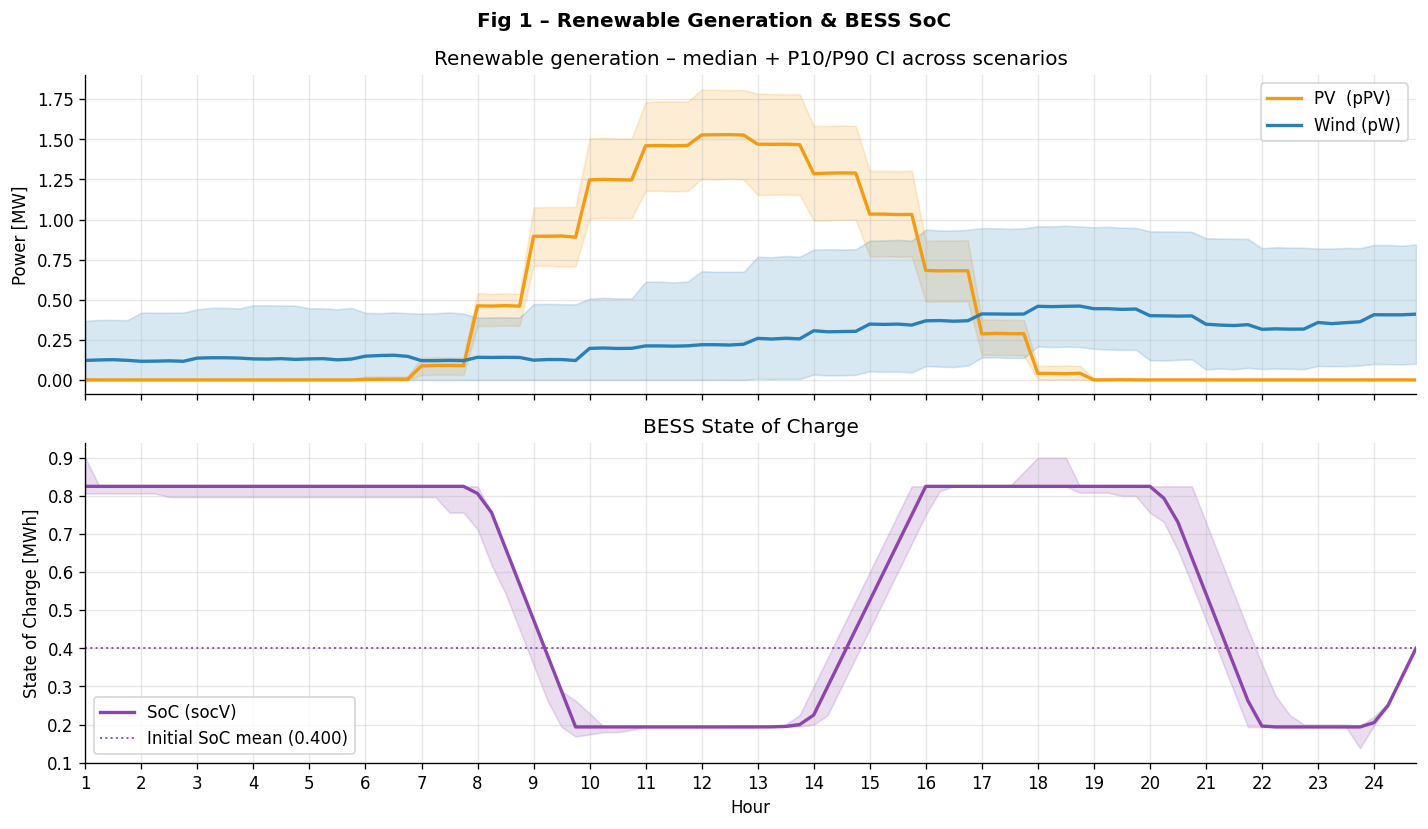

In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,7), sharex=True)
fig.suptitle("Fig 1 – Renewable Generation & BESS SoC", fontweight="bold")
t = _t(next(iter(data.values())))

if "pPV" in data: _band(ax1, t, data["pPV"], COLORS["pv"],   "PV  (pPV)")
if "pW"  in data: _band(ax1, t, data["pW"],  COLORS["wind"], "Wind (pW)")
ax1.set_ylabel("Power [MW]"); ax1.legend(); ax1.grid(alpha=0.3)
ax1.set_title("Renewable generation – median + P10/P90 CI across scenarios")

if "socV" in data:
    _band(ax2, t, data["socV"], COLORS["bess"], "SoC (socV)")
    _annotate_socv_initial(ax2)
ax2.set_ylabel("State of Charge [MWh]"); ax2.legend(); ax2.grid(alpha=0.3)
ax2.set_title("BESS State of Charge")
ax2.set_xlabel(CONFIG["period_label"])
_format_hour_axis(ax2, t if "t" in globals() else None)

plt.tight_layout(); _save(fig, "fig1_generation"); plt.show()


## 5 · Fig 2 – BESS Operation (cV_dV & idV)

**What to look for:**
- `cV_dV > 0` → BESS is charging; `< 0` → discharging. Diverging colours make this instant to read.
- `idV` bar height → in what fraction of scenarios is the BESS actually dispatched to discharge at that hour.
- Discrepancy between median `cV_dV < 0` and low `idV` → some scenarios charge while others discharge (high uncertainty in dispatch decision).


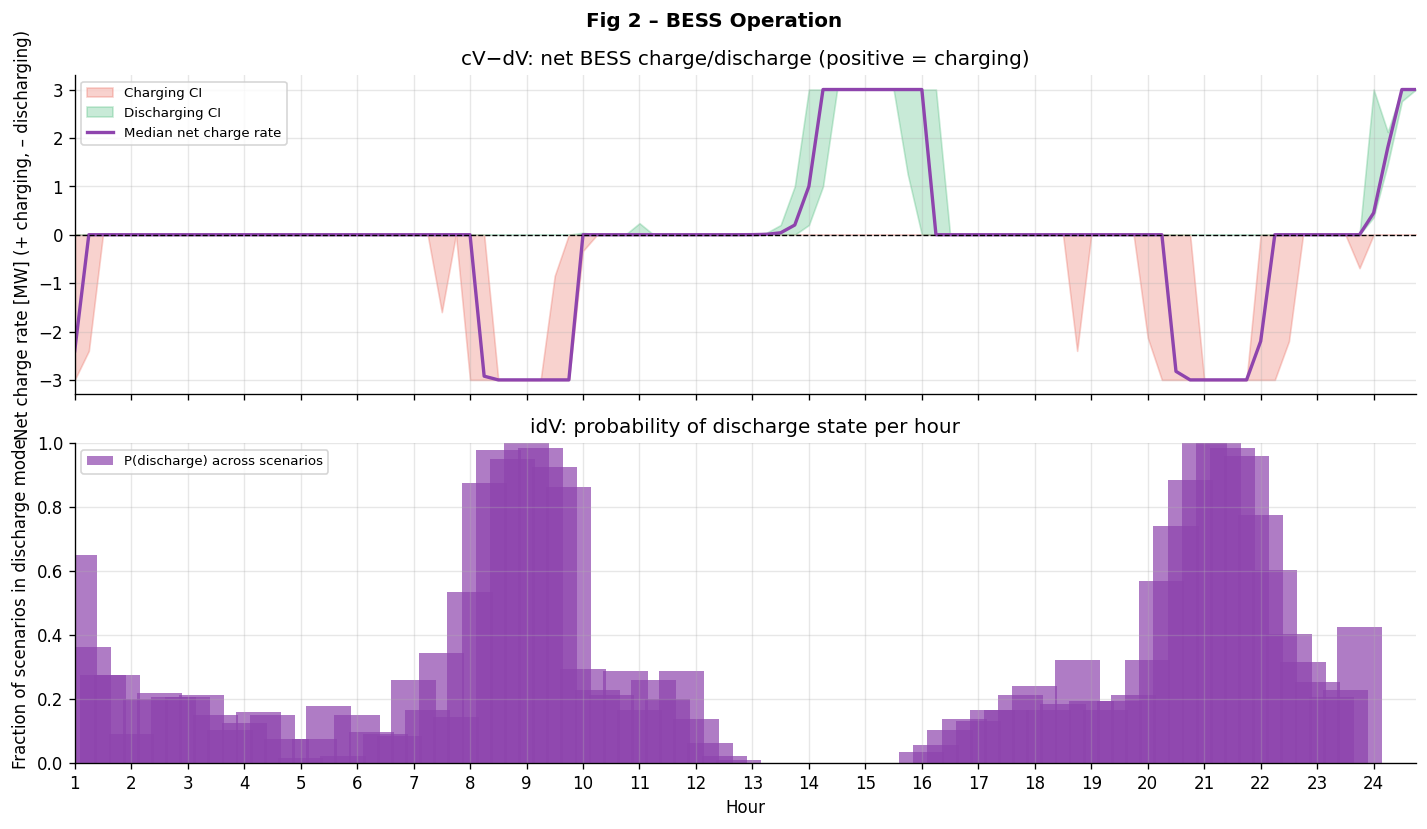

In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,7), sharex=True)
fig.suptitle("Fig 2 – BESS Operation", fontweight="bold")
t = _t(next(iter(data.values())))

if "cV_dV" in data:
    med, lo, hi = _ci(data["cV_dV"])
    ax1.fill_between(t, np.minimum(lo,0), np.minimum(hi,0), color=COLORS["neg"], alpha=0.25, label="Charging CI")
    ax1.fill_between(t, np.maximum(lo,0), np.maximum(hi,0), color=COLORS["pos"], alpha=0.25, label="Discharging CI")
    ax1.plot(t, med, color=COLORS["bess"], lw=2, label="Median net charge rate")
    ax1.axhline(0, color="k", lw=0.8, ls="--")
ax1.set_ylabel("Net charge rate [MW] (+ charging, – discharging)")
ax1.legend(fontsize=8); ax1.grid(alpha=0.3)
ax1.set_title("cV−dV: net BESS charge/discharge (positive = charging)")

if "idV" in data:
    ax2.bar(t, data["idV"].mean(axis=1), color=COLORS["bess"], alpha=0.7, label="P(discharge) across scenarios")
    ax2.set_ylim(0,1)
    ax2.set_ylabel("Fraction of scenarios in discharge mode")
    ax2.legend(fontsize=8); ax2.grid(alpha=0.3)
    ax2.set_title("idV: probability of discharge state per hour")
ax2.set_xlabel(CONFIG["period_label"])
_format_hour_axis(ax2, t if "t" in globals() else None)

plt.tight_layout(); _save(fig, "fig2_bess_operation"); plt.show()


## 6 · Fig 3 – Flexible Demand

**What to look for:**
- Panel (a): total `var_fd` — does the EC smooth its demand effectively?
- Panel (b): mirrored `var_afd_p` / `var_afd_m` — are both shifts active simultaneously (arbitrage) or mutually exclusive?
- Panel (c): boxplot of **net shift** — wide boxes indicate high scenario uncertainty in how the FD is used. Outliers suggest extreme activation events.


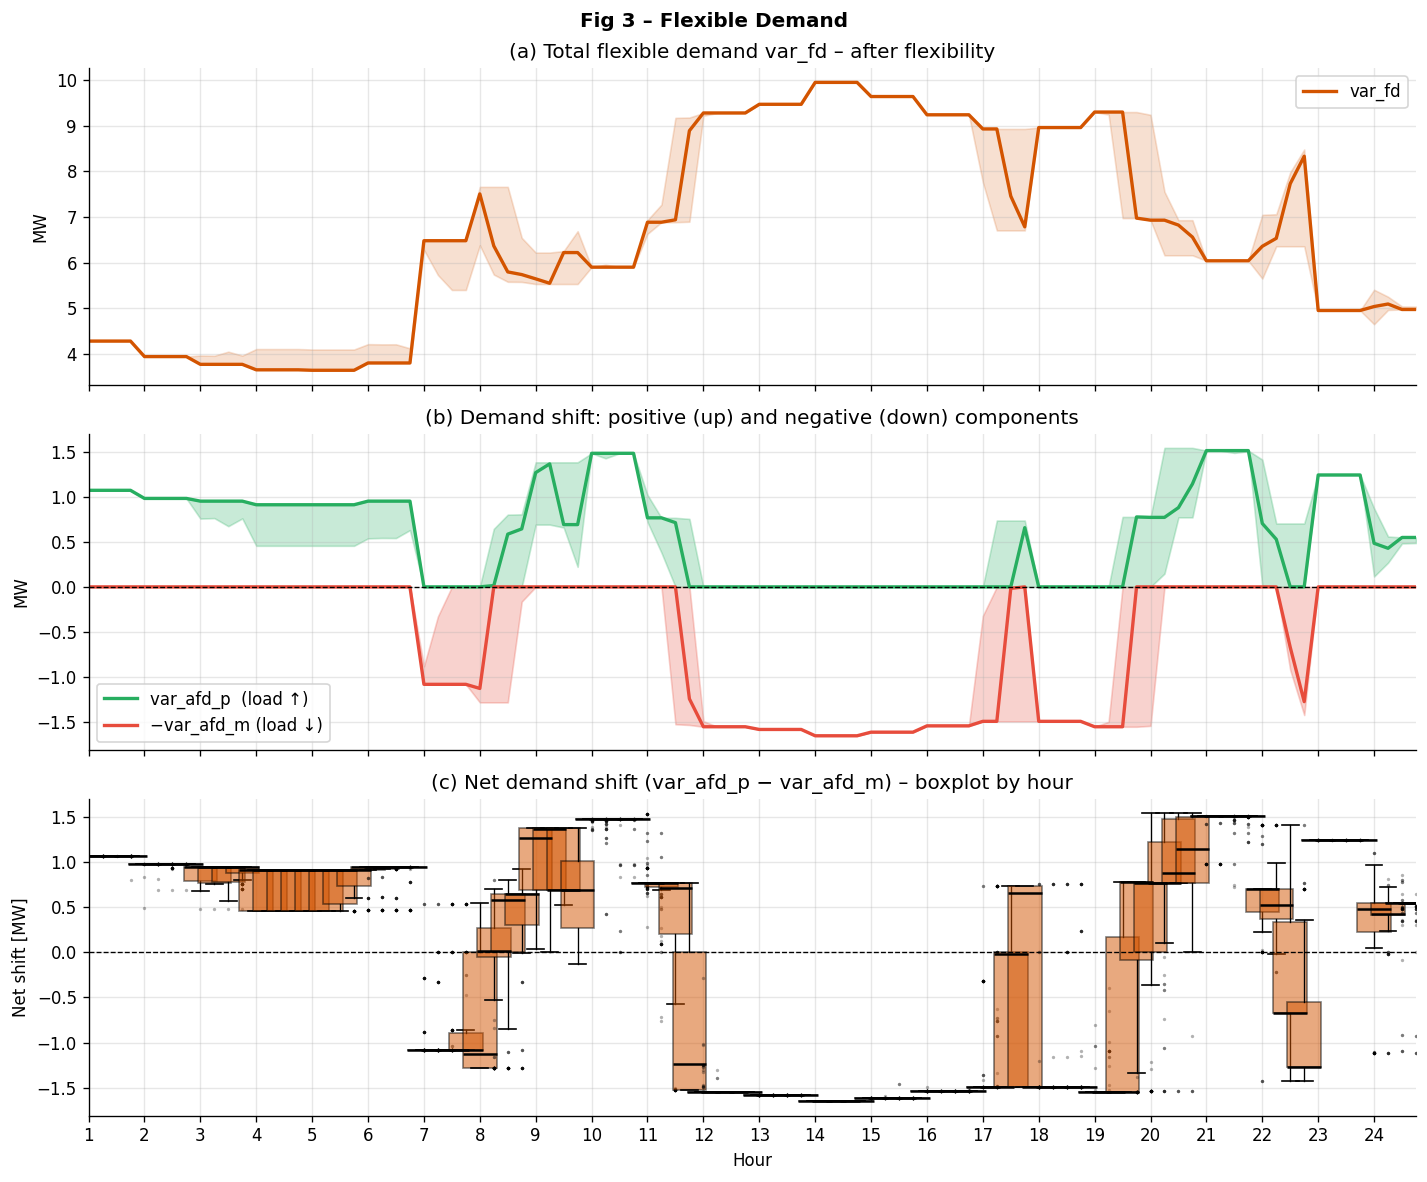

In [9]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12,10), sharex=True)
fig.suptitle("Fig 3 – Flexible Demand", fontweight="bold")
t = _t(next(iter(data.values())))

# (a) total flexible demand
if "var_fd" in data:
    _band(ax1, t, data["var_fd"], COLORS["fd"], "var_fd")
ax1.set_ylabel("MW"); ax1.legend(); ax1.grid(alpha=0.3)
ax1.set_title("(a) Total flexible demand var_fd – after flexibility")

# (b) positive / negative shifts mirrored
if "var_afd_p" in data and "var_afd_m" in data:
    med_p, lp, hp = _ci(data["var_afd_p"])
    med_m, lm, hm = _ci(data["var_afd_m"])
    ax2.fill_between(t,  lp,  hp, color=COLORS["pos"], alpha=0.25)
    ax2.plot(t, med_p, color=COLORS["pos"], lw=2, label="var_afd_p  (load ↑)")
    ax2.fill_between(t, -hm, -lm, color=COLORS["neg"], alpha=0.25)
    ax2.plot(t, -med_m, color=COLORS["neg"], lw=2, label="−var_afd_m (load ↓)")
    ax2.axhline(0, color="k", lw=0.8, ls="--")
ax2.set_ylabel("MW"); ax2.legend(); ax2.grid(alpha=0.3)
ax2.set_title("(b) Demand shift: positive (up) and negative (down) components")

# (c) net shift boxplot per hour
if "var_afd_p" in data and "var_afd_m" in data:
    net = (data["var_afd_p"] - data["var_afd_m"]).values
    ax3.boxplot([net[i,:] for i in range(len(t))],
                positions=t, widths=0.6, patch_artist=True,
                boxprops=dict(facecolor=COLORS["fd"], alpha=0.5),
                medianprops=dict(color="k", lw=1.5),
                whiskerprops=dict(lw=0.8),
                flierprops=dict(marker=".", ms=2, alpha=0.3))
    ax3.axhline(0, color="k", lw=0.8, ls="--")
ax3.set_ylabel("Net shift [MW]"); ax3.grid(alpha=0.3)
ax3.set_title("(c) Net demand shift (var_afd_p − var_afd_m) – boxplot by hour")
ax3.set_xlabel(CONFIG["period_label"])
_format_hour_axis(ax3, t if "t" in globals() else None)

plt.tight_layout(); _save(fig, "fig3_flexible_demand"); plt.show()


## 7 · Fig 4 – Day-Ahead Commitment 
**What to look for:**
- **Panel (a):** committed energy in DA
- **Panel (b):** commited energy in RM
- **Panel (c):** commited energy in IM1
- **Panel (d):** commited energy in IM2
- **Panel (e):** commited energy in IM3


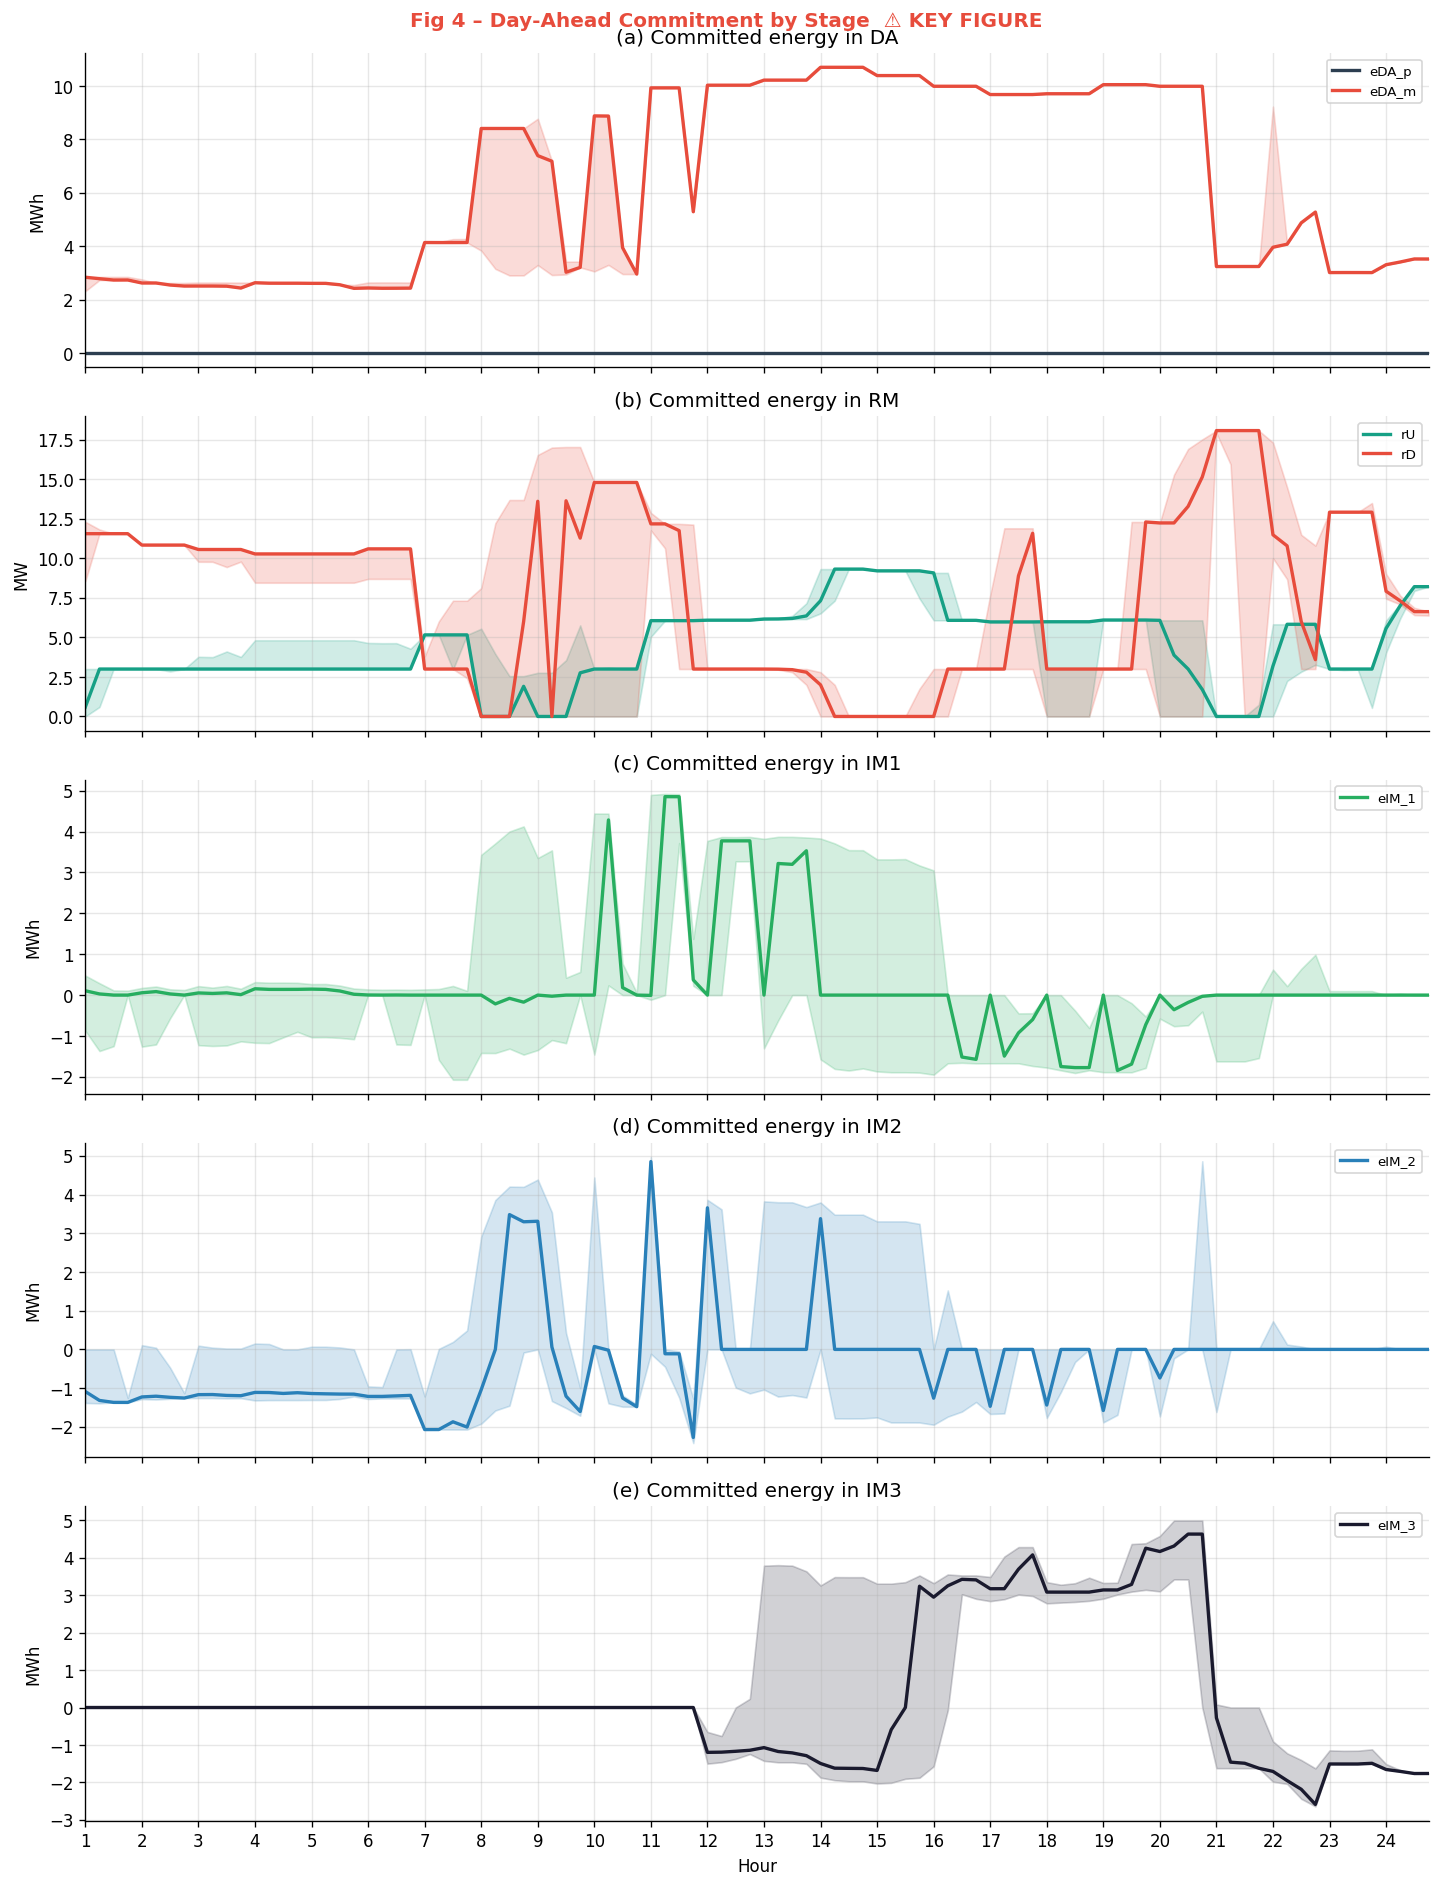

In [10]:
fig, axs = plt.subplots(5, 1, figsize=(12,16), sharex=True)
fig.suptitle("Fig 4 – Day-Ahead Commitment by Stage  ⚠️ KEY FIGURE",
             fontweight="bold", color=COLORS["neg"])
t = _t(next(iter(data.values())))

# (a) committed energy in DA
if "eDA_p" in data:
    med, lo, hi = _ci(data["eDA_p"])
    axs[0].fill_between(t, lo, hi, color=COLORS["da"], alpha=0.2)
    axs[0].plot(t, med, lw=2, color=COLORS["da"], label="eDA_p")
if "eDA_m" in data:
    med, lo, hi = _ci(data["eDA_m"])
    axs[0].fill_between(t, lo, hi, color=COLORS["neg"], alpha=0.2)
    axs[0].plot(t, med, lw=2, color=COLORS["neg"], label="eDA_m")
axs[0].set_ylabel("MWh"); axs[0].legend(fontsize=8); axs[0].grid(alpha=0.3)
axs[0].set_title("(a) Committed energy in DA")

# (b) committed energy in RM
if "rU" in data:
    med, lo, hi = _ci(data["rU"])
    axs[1].fill_between(t, lo, hi, color=COLORS["reserve"], alpha=0.2)
    axs[1].plot(t, med, lw=2, color=COLORS["reserve"], label="rU")
if "rD" in data:
    med, lo, hi = _ci(data["rD"])
    axs[1].fill_between(t, lo, hi, color=COLORS["neg"], alpha=0.2)
    axs[1].plot(t, med, lw=2, color=COLORS["neg"], label="rD")
axs[1].set_ylabel("MW"); axs[1].legend(fontsize=8); axs[1].grid(alpha=0.3)
axs[1].set_title("(b) Committed energy in RM")

# (c) committed energy in IM1
if "eIM_1" in data:
    med, lo, hi = _ci(data["eIM_1"])
    axs[2].fill_between(t, lo, hi, color=COLORS["pos"], alpha=0.2)
    axs[2].plot(t, med, lw=2, color=COLORS["pos"], label="eIM_1")
axs[2].set_ylabel("MWh"); axs[2].legend(fontsize=8); axs[2].grid(alpha=0.3)
axs[2].set_title("(c) Committed energy in IM1")

# (d) committed energy in IM2
if "eIM_2" in data:
    med, lo, hi = _ci(data["eIM_2"])
    axs[3].fill_between(t, lo, hi, color=COLORS["wind"], alpha=0.2)
    axs[3].plot(t, med, lw=2, color=COLORS["wind"], label="eIM_2")
axs[3].set_ylabel("MWh"); axs[3].legend(fontsize=8); axs[3].grid(alpha=0.3)
axs[3].set_title("(d) Committed energy in IM2")

# (e) committed energy in IM3
if "eIM_3" in data:
    med, lo, hi = _ci(data["eIM_3"])
    axs[4].fill_between(t, lo, hi, color=COLORS["median"], alpha=0.2)
    axs[4].plot(t, med, lw=2, color=COLORS["median"], label="eIM_3")
axs[4].set_ylabel("MWh"); axs[4].legend(fontsize=8); axs[4].grid(alpha=0.3)
axs[4].set_title("(e) Committed energy in IM3")
axs[4].set_xlabel(CONFIG["period_label"])
_format_hour_axis(axs[4], t if "t" in globals() else None)

plt.tight_layout(); _save(fig, "fig4_da_commitment"); plt.show()

## 8 · Fig 5 – Reserve Provision (Upward & Downward)

**What to look for:**
- Which asset (BESS vs FD) carries the bulk of reserve provision at each hour.
- Dashed total line vs. stacked area → if total > BESS + FD something is off (data check).
- Wide CI on the total reserve → significant scenario uncertainty in reserve matching.


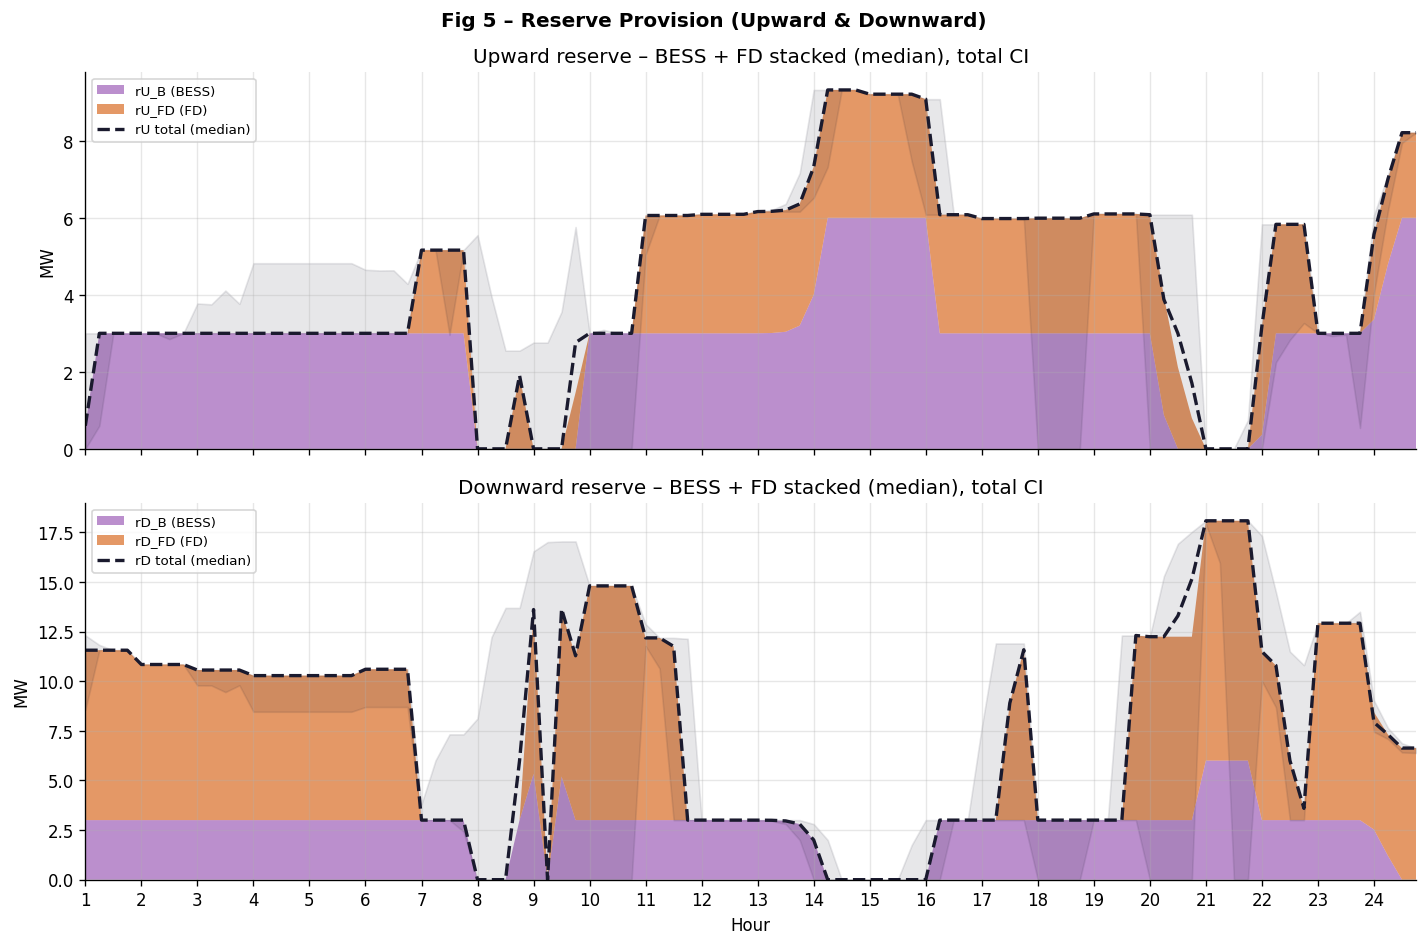

In [11]:
fig, (ax_u, ax_d) = plt.subplots(2, 1, figsize=(12,8), sharex=True)
fig.suptitle("Fig 5 – Reserve Provision (Upward & Downward)", fontweight="bold")
t = _t(next(iter(data.values())))

for ax, label, r_tot, r_b, r_fd in [
    (ax_u, "Upward",   "rU",  "rU_B",  "rU_FD"),
    (ax_d, "Downward", "rD",  "rD_B",  "rD_FD"),
]:
    med_b  = data[r_b ].median(axis=1).values if r_b  in data else np.zeros(len(t))
    med_fd = data[r_fd].median(axis=1).values if r_fd in data else np.zeros(len(t))
    ax.stackplot(t, med_b, med_fd,
                 labels=[f"{r_b} (BESS)", f"{r_fd} (FD)"],
                 colors=[COLORS["bess"], COLORS["fd"]], alpha=0.6)
    if r_tot in data:
        med_tot, lo, hi = _ci(data[r_tot])
        ax.plot(t, med_tot, color=COLORS["median"], lw=2, ls="--",
                label=f"{r_tot} total (median)")
        ax.fill_between(t, lo, hi, color=COLORS["median"], alpha=0.1)
    ax.set_ylabel("MW"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax.set_title(f"{label} reserve – BESS + FD stacked (median), total CI")

ax_d.set_xlabel(CONFIG["period_label"])
_format_hour_axis(ax_d, t if "t" in globals() else None)
plt.tight_layout(); _save(fig, "fig5_reserves"); plt.show()


## 9 · Fig 6 – Imbalance & Intraday Position ⚠️ KEY FIGURE

**What to look for:**
- **Panel (a):** mirrored pIB_p / pIB_m — does the EC mostly over-deliver or under-deliver?
- **Panel (b):** net imbalance bars — red hours = under-delivery (penalty exposure); green = over-delivery (spill or revenue).
- **Panel (c):** `eIM` — does intraday trading reduce imbalance at the same hours where panel (b) is red? If yes, the intraday market is effective.


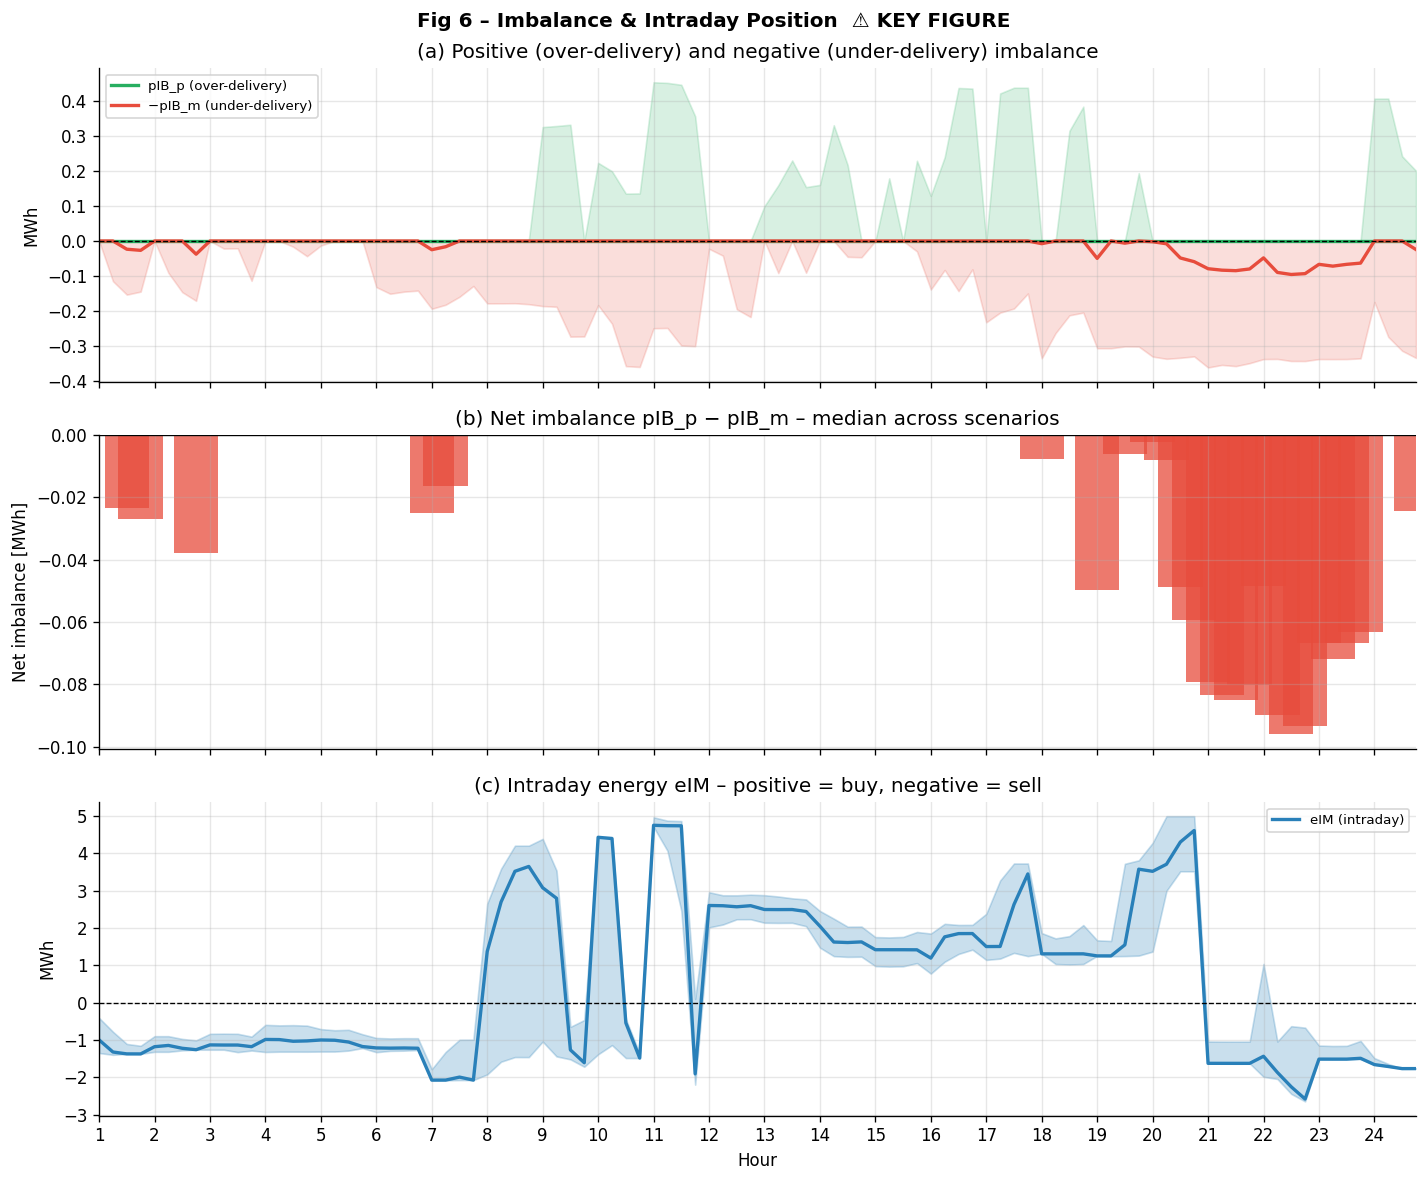

In [12]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12,10), sharex=True)
fig.suptitle("Fig 6 – Imbalance & Intraday Position  ⚠️ KEY FIGURE", fontweight="bold")
t = _t(next(iter(data.values())))

# (a) pIB_p / pIB_m mirrored
if "pIB_p" in data:
    _band(ax1, t, data["pIB_p"], COLORS["pos"], "pIB_p (over-delivery)")
if "pIB_m" in data:
    med_m, lo_m, hi_m = _ci(data["pIB_m"])
    ax1.fill_between(t, -hi_m, -lo_m, color=COLORS["neg"], alpha=0.18)
    ax1.plot(t, -med_m, color=COLORS["neg"], lw=2, label="−pIB_m (under-delivery)")
ax1.axhline(0, color="k", lw=0.8, ls="--")
ax1.set_ylabel("MWh"); ax1.legend(fontsize=8); ax1.grid(alpha=0.3)
ax1.set_title("(a) Positive (over-delivery) and negative (under-delivery) imbalance")

# (b) net imbalance bar
if "pIB_p" in data and "pIB_m" in data:
    net_med = (data["pIB_p"] - data["pIB_m"]).median(axis=1).values
    ax2.bar(t, net_med, color=[COLORS["pos"] if v>=0 else COLORS["neg"] for v in net_med], alpha=0.75)
    ax2.axhline(0, color="k", lw=0.8)
ax2.set_ylabel("Net imbalance [MWh]"); ax2.grid(alpha=0.3)
ax2.set_title("(b) Net imbalance pIB_p − pIB_m – median across scenarios")

# (c) eIM intraday
if "eIM" in data:
    med_im, lo_im, hi_im = _ci(data["eIM"])
    ax3.fill_between(t, lo_im, hi_im, color=COLORS["wind"], alpha=0.25)
    ax3.plot(t, med_im, color=COLORS["wind"], lw=2, label="eIM (intraday)")
    ax3.axhline(0, color="k", lw=0.8, ls="--")
ax3.set_ylabel("MWh"); ax3.legend(fontsize=8); ax3.grid(alpha=0.3)
ax3.set_title("(c) Intraday energy eIM – positive = buy, negative = sell")
ax3.set_xlabel(CONFIG["period_label"])
_format_hour_axis(ax3, t if "t" in globals() else None)

plt.tight_layout(); _save(fig, "fig6_imbalance"); plt.show()


## 10 · Fig 7 – Scenario Fan Charts (spaghetti)

**What to look for:**
- Are traces clustered (low spread) or spread widely (high uncertainty)?
- Bimodal shapes → two distinct operating regimes across scenarios.
- Extreme outlier traces → which scenario drives the worst case?

> You can change `vars_to_show` to inspect any subset of variables.


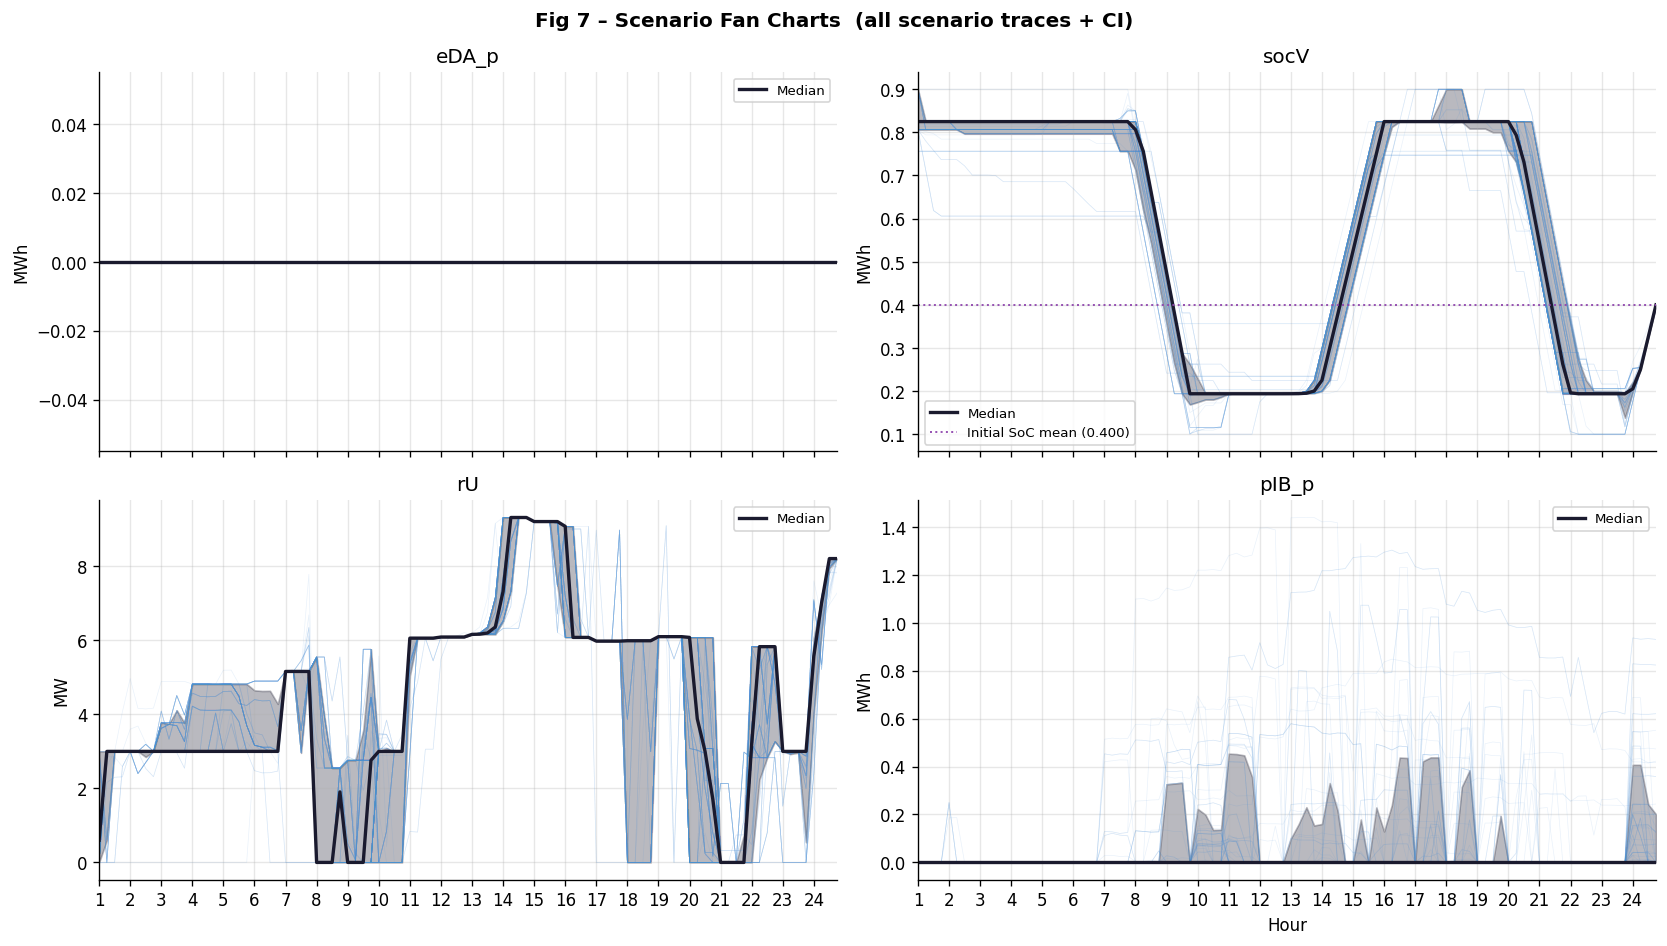

In [13]:
vars_to_show = ["eDA_p", "socV", "rU", "pIB_p"]   # ← edit here
vars_to_show = [v for v in vars_to_show if v in data]

ncols = 2
nrows = int(np.ceil(len(vars_to_show)/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4*nrows), sharex=True)
axes = np.array(axes).flatten()
fig.suptitle("Fig 7 – Scenario Fan Charts  (all scenario traces + CI)", fontweight="bold")
t = _t(next(iter(data.values())))

for ax, var in zip(axes, vars_to_show):
    df = data[var]
    for col in df.columns:
        ax.plot(t, df[col].values, color=COLORS["ci_fill"], lw=0.4, alpha=0.12)
    _band(ax, t, df, COLORS["median"], "Median", alpha=0.3)
    if var == "socV":
        _annotate_socv_initial(ax)
    ax.set_title(var); ax.set_ylabel(UNITS.get(var,"–")); ax.grid(alpha=0.3); ax.legend(fontsize=8)

for ax in axes[len(vars_to_show):]: ax.set_visible(False)
axes[-1].set_xlabel(CONFIG["period_label"])
_format_hour_axis(axes[-1], t if "t" in globals() else None)
plt.tight_layout(); _save(fig, "fig7_scenario_fans"); plt.show()


## 11 ? Market Benefit Distribution

Boxplot of total scenario benefit by market. CI markers show P10-P90 across scenarios.


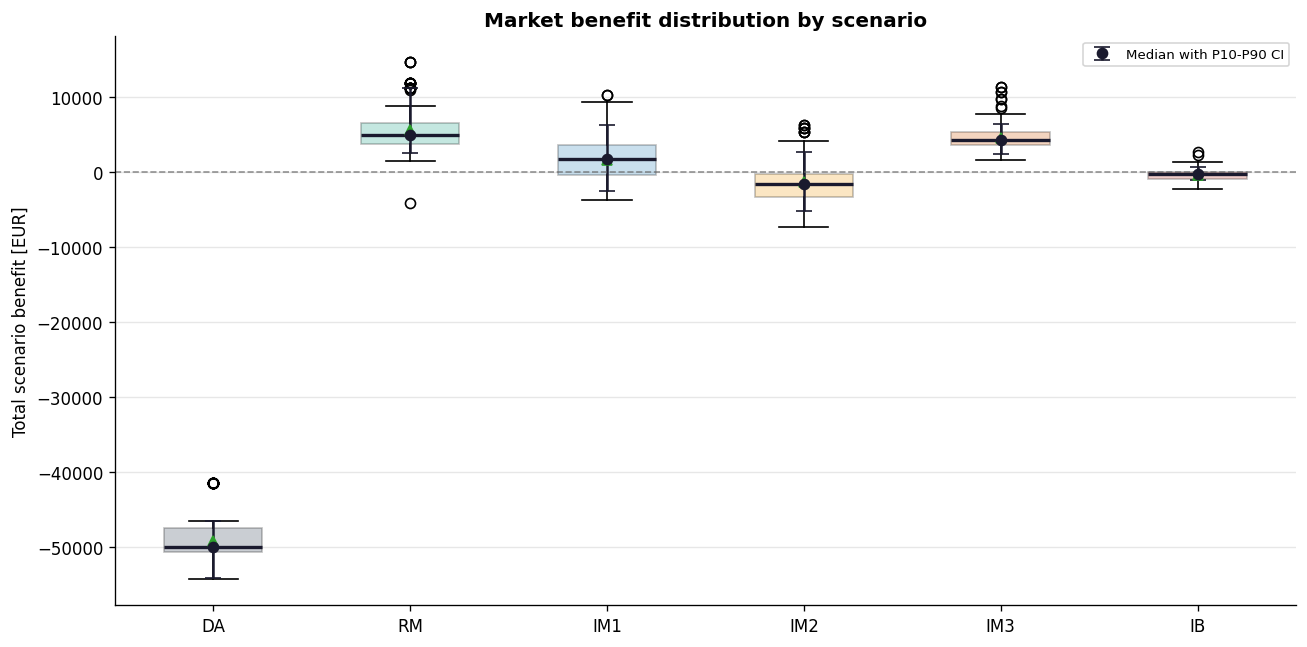

,median,P10,P90,mean
DA,-49917.4889,-54097.0778,-46493.0325,-49108.0893
RM,4899.7095,2509.7601,11188.1744,5653.8585
IM1,1692.8551,-2577.3788,6284.3372,1630.9980
IM2,-1563.0987,-5203.3333,2642.9270,-1378.0173
IM3,4317.8423,2381.3420,6406.9567,4556.0613
IB,-323.1326,-1128.3788,692.1506,-342.2351


In [14]:
def _aligned_product_total(*dfs):
    dfs = [df for df in dfs if df is not None]
    if not dfs:
        return None
    common_index = dfs[0].index
    common_cols = dfs[0].columns
    for df in dfs[1:]:
        common_index = common_index.intersection(df.index)
        common_cols = common_cols.intersection(df.columns)
    if len(common_index) == 0 or len(common_cols) == 0:
        return None
    prod = dfs[0].loc[common_index, common_cols].copy()
    for df in dfs[1:]:
        prod = prod * df.loc[common_index, common_cols]
    return prod.sum(axis=0)

market_benefits = {}

if {"lD", "eDA_p", "eDA_m"}.issubset(data):
    da_net = data["eDA_p"] - data["eDA_m"]
    market_benefits["DA"] = _aligned_product_total(data["lD"], da_net)

if {"lR", "rU", "rD"}.issubset(data):
    rm_reserve = data["rU"] + data["rD"]
    market_benefits["RM"] = _aligned_product_total(data["lR"], rm_reserve)

for i in [1, 2, 3]:
    li = f"lI_{i}"
    ei = f"eIM_{i}"
    if {li, ei}.issubset(data):
        market_benefits[f"IM{i}"] = _aligned_product_total(data[li], data[ei])

if {"lPIB", "pIB_p", "lNIB", "pIB_m"}.issubset(data):
    ib_income = _aligned_product_total(data["lPIB"], data["pIB_p"])
    ib_costs = _aligned_product_total(data["lNIB"], data["pIB_m"])
    if ib_income is not None and ib_costs is not None:
        common_cols = ib_income.index.intersection(ib_costs.index)
        market_benefits["IB"] = ib_income.loc[common_cols] - ib_costs.loc[common_cols]

market_order = ["DA", "RM", "IM1", "IM2", "IM3", "IB"]
market_benefits = {k: market_benefits[k].dropna() for k in market_order if k in market_benefits and market_benefits[k] is not None}

if not market_benefits:
    print("No market benefit data available for this run.")
else:
    labels = list(market_benefits.keys())
    values = [market_benefits[k].values for k in labels]
    positions = np.arange(1, len(labels) + 1)

    fig, ax = plt.subplots(figsize=(11, 5.5))
    bp = ax.boxplot(values, positions=positions, labels=labels, patch_artist=True, showmeans=True)
    for patch, color in zip(bp["boxes"], [COLORS["da"], COLORS["reserve"], COLORS["wind"], COLORS["pv"], COLORS["fd"], COLORS["imbal"]]):
        patch.set_facecolor(color)
        patch.set_alpha(0.25)
    for med in bp["medians"]:
        med.set_color(COLORS["median"])
        med.set_linewidth(2)

    ci_low, ci_high = CONFIG["ci_low"], CONFIG["ci_high"]
    medians = np.array([np.median(v) for v in values])
    lo = np.array([np.percentile(v, ci_low) for v in values])
    hi = np.array([np.percentile(v, ci_high) for v in values])
    ax.errorbar(positions, medians, yerr=[medians - lo, hi - medians], fmt="o",
                color=COLORS["median"], ecolor=COLORS["median"], capsize=5,
                label=f"Median with P{ci_low}-P{ci_high} CI")
    ax.axhline(0, color="#666666", lw=1, ls="--", alpha=0.7)
    ax.set_ylabel("Total scenario benefit [EUR]")
    ax.set_title("Market benefit distribution by scenario", fontweight="bold")
    ax.grid(axis="y", alpha=0.3)
    ax.legend(fontsize=8)
    plt.tight_layout(); _save(fig, "fig_market_benefits_boxplot"); plt.show()

    benefit_summary = pd.DataFrame({
        "median": medians,
        f"P{ci_low}": lo,
        f"P{ci_high}": hi,
        "mean": [np.mean(v) for v in values],
    }, index=labels)
    display(benefit_summary)


## 11 · Fig 8 – Correlation Heatmap

**What to look for:**
- Strong positive correlation (dark blue) between PV/Wind and reserve/FD → renewable surplus drives reserve provision.
- Strong negative correlation between `socV` and `pIB_m` → better SoC management reduces imbalance penalties.
- Any unexpected high correlation that reveals hidden structural coupling in the model.


Excluded constant variables from correlation heatmap: ['eDA_p', 'ieDA_m', 'ieDA_p', 'pIB_p']
Correlation heatmap uses 29 operational variables with shared index 96 time points.


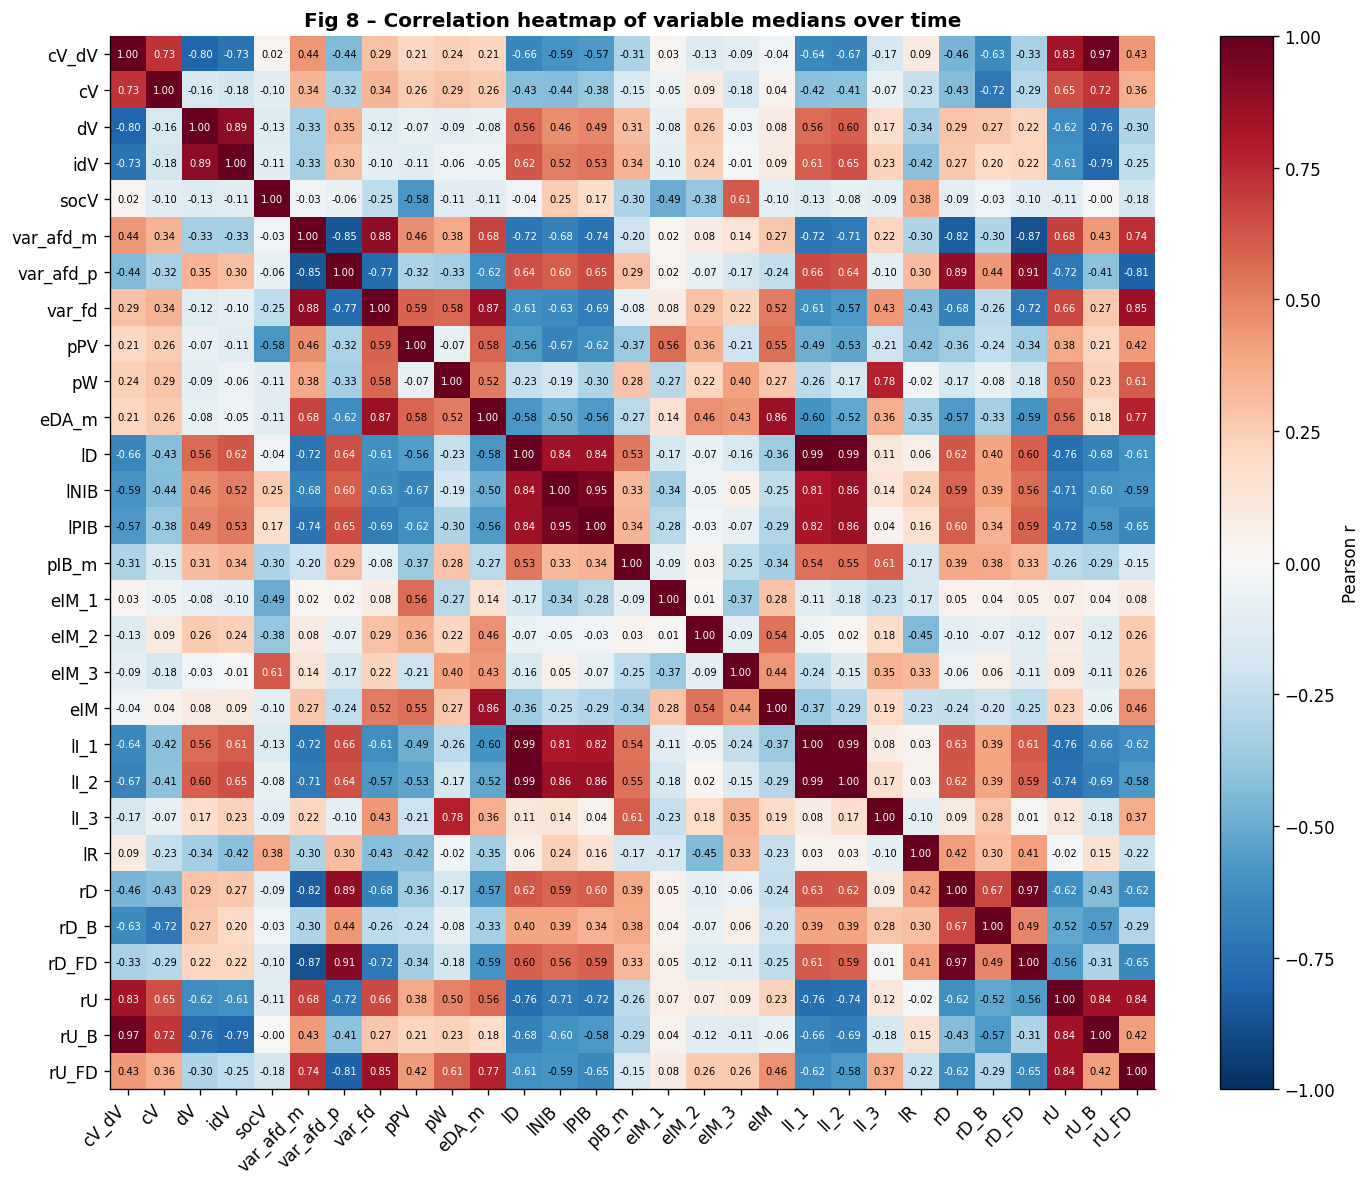

In [15]:
op_data = _operational_ts_data(data)
med_df = pd.DataFrame({v: df.median(axis=1) for v, df in op_data.items()})
empty_vars = med_df.columns[med_df.isna().all()].tolist()
if empty_vars:
    print("Dropped empty variables from correlation heatmap:", empty_vars)
med_df = med_df.dropna(axis=1, how="all")
std = med_df.std(axis=0)
constant_vars = std[std <= 1e-12].index.tolist()
if constant_vars:
    print("Excluded constant variables from correlation heatmap:", constant_vars)
med_df = med_df.loc[:, std > 1e-12]
corr = med_df.corr(min_periods=2)
if corr.isna().any().any():
    print("Warning: correlation contains NaN values due to insufficient data for some variable pairs. NaN values are preserved.")
print(f"Correlation heatmap uses {med_df.shape[1]} operational variables with shared index {med_df.shape[0]} time points.")

fig, ax = plt.subplots(figsize=(12,10))
cmap = plt.get_cmap("RdBu_r").copy()
cmap.set_bad("#d3d3d3")
im = ax.imshow(corr.values, cmap=cmap, vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, label="Pearson r")
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        val = corr.values[i,j]
        text = f"{val:.2f}" if not np.isnan(val) else "NaN"
        color = "white" if not np.isnan(val) and abs(val) > 0.6 else "black"
        ax.text(j, i, text, ha="center", va="center",
                fontsize=6, color=color)
ax.set_title("Fig 8 – Correlation heatmap of variable medians over time", fontweight="bold")
plt.tight_layout(); _save(fig, "fig8_correlation"); plt.show()


## 12 · Fig 9 – Commitment Failure Dashboard ⚠️ KEY FIGURE

One-page answer to *"when and how severely did the EC miss its day-ahead commitments?"*

| Sub-panel | What it shows |
|---|---|
| **(a) Risk strip** | colour = fraction of scenarios with `pIB_m > 0`; red hours = most risky |
| **(b) Shortfall bars** | median magnitude of `pIB_m` (CI band) |
| **(c) Delivered power** | actual delivered power from `pPV + pW - cV_dV` when available; otherwise show `pIB_m` under-delivery proxy |
| **(d) CDF** | cumulative distribution of total daily under-delivery across all scenarios; P90 marks the tail risk |


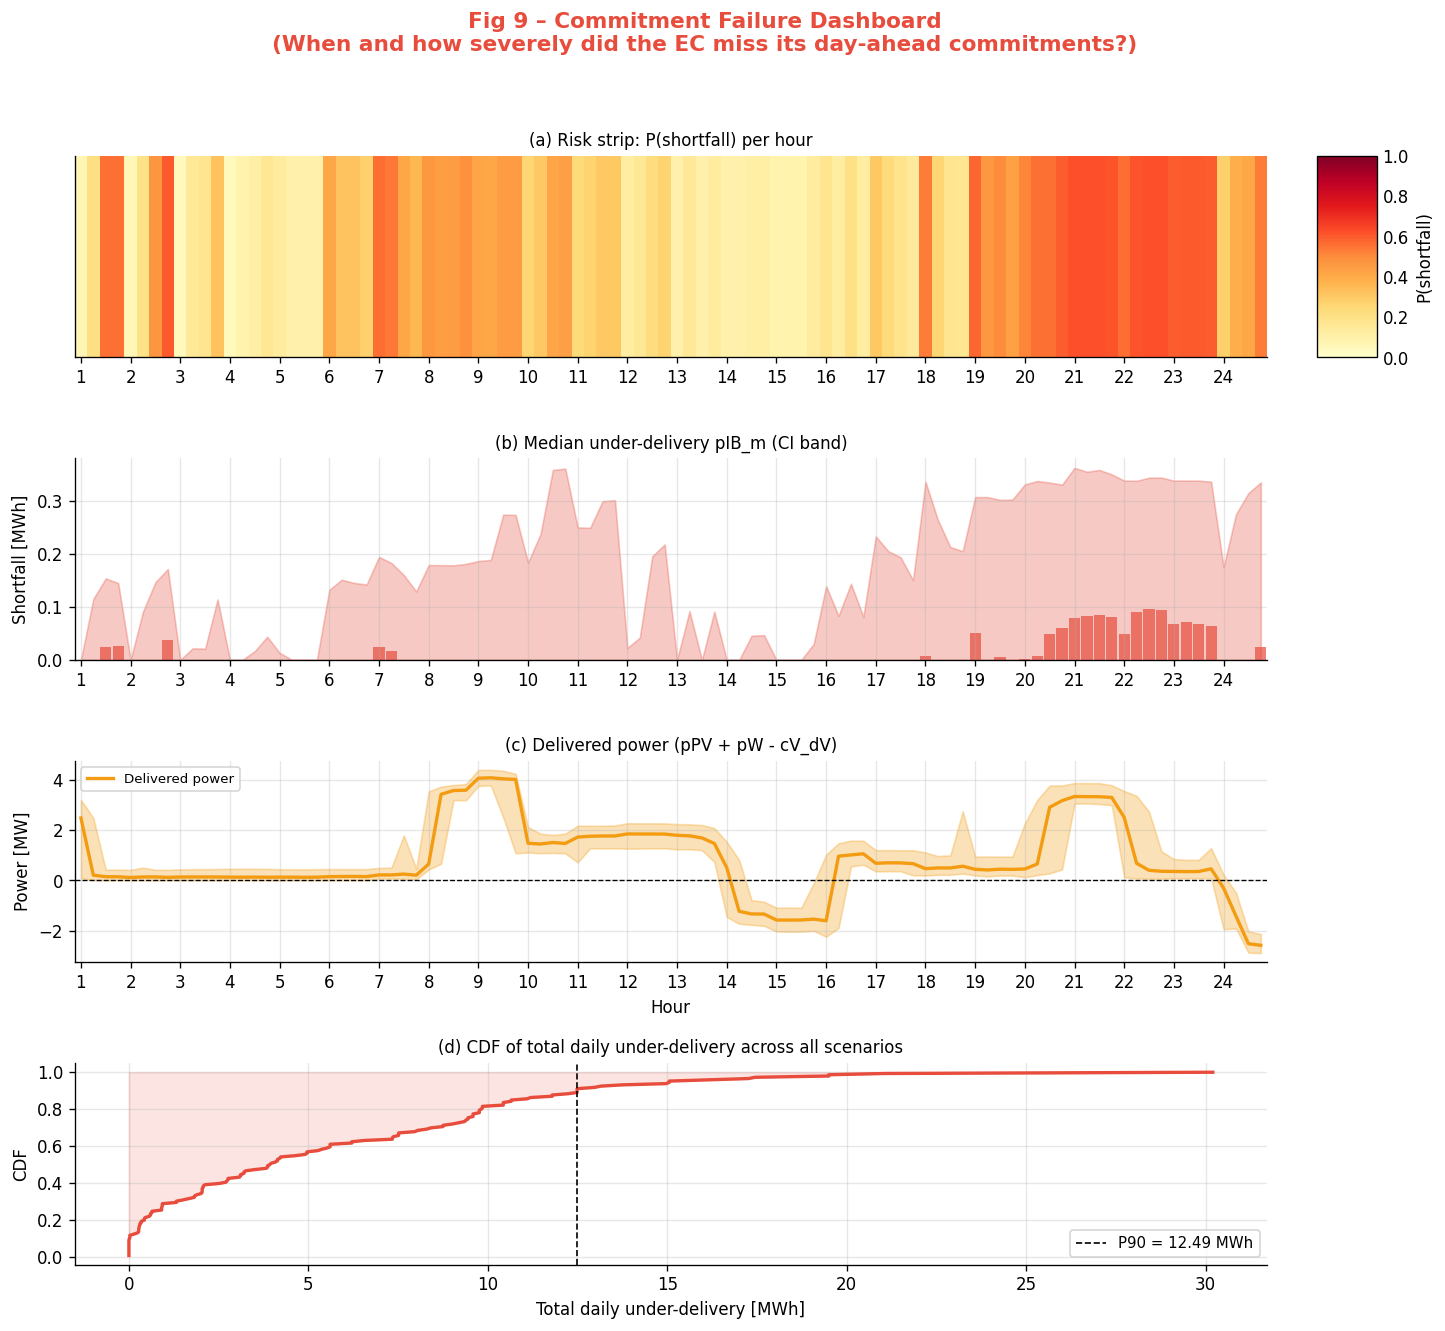

In [16]:
fig = plt.figure(figsize=(14,12))
fig.suptitle("Fig 9 – Commitment Failure Dashboard\n"
             "(When and how severely did the EC miss its day-ahead commitments?)",
             fontweight="bold", color=COLORS["neg"], fontsize=13)

gs = gridspec.GridSpec(4, 2, width_ratios=[20, 1], wspace=0.08, hspace=0.5)
ax1 = fig.add_subplot(gs[0, 0])
cax = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
ax3 = fig.add_subplot(gs[2, 0], sharex=ax1)
ax4 = fig.add_subplot(gs[3, 0])

t_arr = _t(next(iter(data.values())))
T = len(t_arr)
step = float(np.min(np.diff(t_arr))) if len(t_arr) > 1 else 1.0
x_edges = np.concatenate([t_arr - step/2, [t_arr[-1] + step/2]])
bar_width = min(0.8, step * 0.9)

# (a) risk heat-strip
prob = np.zeros(T)
if "pIB_m" in data:
    prob = (data["pIB_m"] > 1e-6).mean(axis=1).values
heat = ax1.pcolormesh(x_edges, [0, 1], prob[None, :], cmap="YlOrRd",
                      vmin=0, vmax=1, shading="auto")
fig.colorbar(heat, cax=cax, orientation="vertical")
cax.set_ylabel("P(shortfall)")
cax.yaxis.set_label_position("right")
cax.tick_params(axis="both", which="both", length=0)
ax1.set_yticks([])
ax1.set_title("(a) Risk strip: P(shortfall) per hour", fontsize=10)
ax1.set_xticks(np.arange(1, int(CONFIG["n_periods"]) + 1))
ax1.set_xticklabels([str(i) for i in range(1, int(CONFIG["n_periods"]) + 1)])
ax1.set_xlim(x_edges[0], x_edges[-1])

# (b) shortfall bars
if "pIB_m" in data:
    med, lo, hi = _ci(data["pIB_m"])
    ax2.fill_between(t_arr, lo, hi, color=COLORS["neg"], alpha=0.3)
    ax2.bar(t_arr, med, color=COLORS["neg"], alpha=0.7, width=bar_width)
ax2.set_ylabel("Shortfall [MWh]"); ax2.grid(alpha=0.3)
ax2.set_title("(b) Median under-delivery pIB_m (CI band)", fontsize=10)

# (c) delivered power
if {"pPV", "pW", "cV_dV"}.issubset(data):
    delivered = data["pPV"] + data["pW"] - data["cV_dV"]
    med_del, lo_del, hi_del = _ci(delivered)
    ax3.fill_between(t_arr, lo_del, hi_del, color=COLORS["pv"], alpha=0.3)
    ax3.plot(t_arr, med_del, color=COLORS["pv"], lw=2, label="Delivered power")
    ax3.axhline(0, color="k", lw=0.8, ls="--")
    ax3.set_ylabel("Power [MW]"); ax3.set_xlabel(CONFIG["period_label"])
    ax3.set_xticks(np.arange(1, int(CONFIG["n_periods"]) + 1))
    ax3.set_xticklabels([str(i) for i in range(1, int(CONFIG["n_periods"]) + 1)])
    ax3.set_xlim(x_edges[0], x_edges[-1])
    ax3.legend(fontsize=8); ax3.grid(alpha=0.3)
    ax3.set_title("(c) Delivered power (pPV + pW - cV_dV)", fontsize=10)
else:
    if "pIB_m" in data:
        med_ib, lo_ib, hi_ib = _ci(data["pIB_m"])
        ax3.fill_between(t_arr, lo_ib, hi_ib, color=COLORS["imbal"], alpha=0.3)
        ax3.plot(t_arr, med_ib, color=COLORS["imbal"], lw=2, label="pIB_m median")
    ax3.set_ylabel("pIB_m [MWh]"); ax3.set_xlabel(CONFIG["period_label"])
    ax3.set_xticks(np.arange(1, int(CONFIG["n_periods"]) + 1))
    ax3.set_xticklabels([str(i) for i in range(1, int(CONFIG["n_periods"]) + 1)])
    ax3.set_xlim(x_edges[0], x_edges[-1])
    ax3.legend(fontsize=8); ax3.grid(alpha=0.3)
    ax3.set_title("(c) Negative imbalance pIB_m – proxy for under-delivery cost", fontsize=10)

# (d) CDF of total daily under-delivery
if "pIB_m" in data:
    sf_tot = data["pIB_m"].sum(axis=0).values
    sf_s   = np.sort(sf_tot)
    cdf    = np.arange(1,len(sf_s)+1)/len(sf_s)
    ax4.plot(sf_s, cdf, color=COLORS["neg"], lw=2)
    ax4.fill_betweenx(cdf, 0, sf_s, color=COLORS["neg"], alpha=0.15)
    p90 = np.percentile(sf_s,90)
    ax4.axvline(p90, color="k", ls="--", lw=1, label=f"P90 = {p90:.2f} MWh")
    ax4.set_xlabel("Total daily under-delivery [MWh]")
    ax4.set_ylabel("CDF"); ax4.legend(fontsize=9); ax4.grid(alpha=0.3)
    ax4.set_title("(d) CDF of total daily under-delivery across all scenarios", fontsize=10)
else:
    ax4.text(0.5, 0.5, "No pIB_m data available for daily under-delivery CDF",
             ha="center", va="center", transform=ax4.transAxes)
    ax4.set_axis_off()

_save(fig, "fig9_commitment_dashboard"); plt.show()

## 13 · Export Descriptive Statistics to CSV

In [17]:
if CONFIG["save_figs"]:
    os.makedirs(CONFIG["fig_dir"], exist_ok=True)
    out = os.path.join(CONFIG["fig_dir"], "descriptive_stats.csv")
    summary.to_csv(out)
    print(f"Saved → {out}")
else:
    print("Set CONFIG['save_figs'] = True to export.")


Set CONFIG['save_figs'] = True to export.


# MSSP Results Analyzer — Different-Ren (sc=170 → 146 reduced scenarios)
*Matched-reduced-scenario comparison, method B of 2 — see intro above. Reduced scenarios in model: **146** (from 170 original).*
### Energy System Market Analysis

**Variables:**
| Group | Variables |
|---|---|
| Flexible Demand | `var_fd`, `var_afd_p`, `var_afd_m` |
| Generation | `pPV`, `pW` |
| BESS | `cV_dV` (net charge rate), `idV` (state), `socV` (SoC) |
| Day-Ahead | `eDA_p`, `eDA_m`, `ieDA_p`, `ieDA_m` |
| Reserves | `rU`, `rD`, `rU_B`, `rD_B`, `rU_FD`, `rD_FD` |
| Imbalance | `eIM`, `eIM1`,`eIM2`, `eIM3`, `pIB_m`, `pIB_p` |

**Data format expected:** one CSV per variable — rows = time steps, columns = scenarios.  
CI bands show P10–P90 across scenarios unless otherwise noted.


## 0 · Imports & Setup

In [18]:
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator
from scipy import stats

warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})
print("Libraries loaded ✓")


Libraries loaded ✓


## 1 · Configuration

Edit the block below to point to your data. Three loading modes are supported:
- **Option A** – one CSV per variable (rows = timesteps, cols = scenarios) → set `data_dir`
- **Option B** – single wide CSV with `(variable, scenario)` MultiIndex columns → set `single_csv`
- **Option C** – HDF5 store with variable names as keys → set `hdf5_file`

If no files are found the script falls back to **synthetic data** so every cell runs out-of-the-box.


In [19]:
CONFIG = dict(
    # ── Data location ─────────────────────────────────────────────────────
    data_dir   = "results/FTC_20251031_20251130_c30_sc170_15min_different_ren/DA",
    file_ext   = ".txt",       # Option A: folder with one TXT per variable (nested dirs allowed)
    single_csv = None,         # Option B: path to wide CSV
    hdf5_file  = None,         # Option C: path to HDF5

    # ── Time axis ─────────────────────────────────────────────────────────
    n_periods    = 24,         # number of time steps (e.g. 24 h)
    period_label = "Hour",     # x-axis label

    # ── CI percentiles ────────────────────────────────────────────────────
    ci_low  = 10,
    ci_high = 90,

    # ── Save figures ──────────────────────────────────────────────────────
    save_figs  = False,        # set True to export PNGs
    fig_dir    = "figures/",
    fig_format = "png",
    dpi        = 150,
)

UNITS = {
    "var_fd":"MW",  "var_afd_p":"MW",  "var_afd_m":"MW",
    "pPV":"MW",     "pW":"MW",
    "cV_dV":"MW",   "idV":"–",         "socV":"MWh",
    "eDA_p":"MWh",  "eDA_m":"MWh",     "ieDA_p":"MWh",  "ieDA_m":"MWh",
    "rU":"MW",      "rD":"MW",
    "rU_B":"MW",    "rD_B":"MW",       "rU_FD":"MW",    "rD_FD":"MW",
    "eIM":"MWh", "eIM_1":"MWh", "eIM_2":"MWh", "eIM_3":"MWh",    "pIB_m":"MWh",     "pIB_p":"MWh",
}

COLORS = dict(
    median="#1a1a2e", ci_fill="#4a90d9",
    pos="#27ae60",    neg="#e74c3c",
    bess="#8e44ad",   pv="#f39c12",
    wind="#2980b9",   reserve="#16a085",
    imbal="#c0392b",  fd="#d35400",
    da="#2c3e50",
)
print("Configuration set ✓")


Configuration set ✓


## 2 · Data Loader

In [20]:
def _synthetic_data(cfg):
    """Fallback synthetic data – replace with real loader if needed."""
    rng = np.random.default_rng(42)
    T, S = cfg["n_periods"], 50
    t = np.linspace(0, 2*np.pi, T)
    scen = [f"s{i:03d}" for i in range(S)]
    data = {}

    def _df(base, noise=0.15, lo=None, hi=None):
        mat = base[:,None] + rng.normal(0, noise*(np.abs(base).mean()+0.01), (T,S))
        if lo is not None: mat = np.clip(mat, lo, None)
        if hi is not None: mat = np.clip(mat, None, hi)
        return pd.DataFrame(mat, columns=scen)

    solar = np.maximum(0, np.sin(t - np.pi/3))
    wind  = 0.4 + 0.3*np.sin(2*t + 0.5)
    dem   = 1.0 + 0.4*np.sin(t - np.pi/2)
    sf_b  = np.where(rng.random(T) > 0.75, rng.uniform(0,0.3,T), 0)

    data["pPV"]      = _df(solar*2.0, lo=0)
    data["pW"]       = _df(wind*1.5,  lo=0)
    data["socV"]     = _df(0.5+0.3*np.sin(t), noise=0.05, lo=0, hi=1.0)
    data["cV_dV"]    = _df(0.3*np.sin(t+1.0), noise=0.2)
    data["idV"]      = pd.DataFrame((rng.random((T,S))>0.5).astype(float), columns=scen)
    data["var_fd"]   = _df(dem, lo=0)
    data["var_afd_p"]= _df(np.abs(0.1*np.sin(t)), lo=0)
    data["var_afd_m"]= _df(np.abs(0.1*np.cos(t)), lo=0)
    eDA              = dem*0.9
    data["eDA_p"]    = _df(eDA, lo=0)
    data["eDA_m"]    = _df(eDA*0.1, lo=0)
    data["ieDA_p"]   = _df(sf_b, noise=0.3, lo=0)
    data["ieDA_m"]   = _df(sf_b*0.5, noise=0.3, lo=0)
    data["rU"]       = _df(0.2+0.1*np.sin(t), lo=0)
    data["rD"]       = _df(0.2+0.1*np.cos(t), lo=0)
    data["rU_B"]     = _df(0.1*np.abs(np.sin(t)), lo=0)
    data["rD_B"]     = _df(0.1*np.abs(np.cos(t)), lo=0)
    data["rU_FD"]    = _df(0.1*np.abs(np.sin(t+0.5)), lo=0)
    data["rD_FD"]    = _df(0.1*np.abs(np.cos(t+0.5)), lo=0)
    data["eIM"]      = _df(0.05*np.sin(3*t))
    data["pIB_p"]    = _df(sf_b*0.8, noise=0.4, lo=0)
    data["pIB_m"]    = _df(sf_b*0.6, noise=0.4, lo=0)
    return data

def load_data(cfg):
    data = {}
    if cfg.get("hdf5_file") and os.path.exists(cfg["hdf5_file"]):
        with pd.HDFStore(cfg["hdf5_file"], mode="r") as s:
            for k in s.keys():
                data[k.lstrip("/").replace("-","_")] = s[k]
        return data
    if cfg.get("single_csv") and os.path.exists(cfg["single_csv"]):
        wide = pd.read_csv(cfg["single_csv"], header=[0,1], index_col=0)
        for v in wide.columns.get_level_values(0).unique():
            data[v.replace("-","_")] = wide[v]
        return data
    files = glob.glob(os.path.join(cfg["data_dir"], "**", f"*{cfg['file_ext']}"), recursive=True)
    if not files:
        print("⚠️  No result files found – using SYNTHETIC data.")
        return _synthetic_data(cfg)

    # MMOBEC 15-min block files: one scenario is stored as n_periods rows.
    # First row of each block starts with: scenario probability q1 q2 ... qN.
    BLOCK_TXT_VARS = {
        "lPIB", "lNIB", "pIB_p", "pIB_m", "lI_1", "lI_2", "lI_3",
        "eDA_p", "eDA_m", "pW", "pPV", "dV", "cV", "var_fd", "eIM",
        "eIM_1", "eIM_2", "eIM_3",
    }

    def _scen_name(val):
        try:
            return f"s{int(float(val)):03d}"
        except Exception:
            return str(val)

    def _wide_from_matrix(values, scen_names, n_q=None):
        values = values.astype(float).T
        values.columns = scen_names
        n_t_cfg = int(cfg.get("n_periods", 24))
        if n_q is None and values.shape[0] % n_t_cfg == 0:
            n_q = values.shape[0] // n_t_cfg
        if n_q and values.shape[0] % n_q == 0:
            n_t = values.shape[0] // n_q
            values.index = pd.MultiIndex.from_tuples(
                [(t, q) for t in range(1, n_t + 1) for q in range(1, n_q + 1)],
                names=["t", "q"],
            )
        else:
            values.index = np.arange(1, values.shape[0] + 1)
        return values

    def _load_block_txt(path, name):
        rows = []
        with open(path, "r", encoding="utf-8") as fh:
            for line in fh:
                line = line.strip()
                if line and not line.startswith("#"):
                    rows.append(line.split())
        if not rows:
            return None

        n_t = int(cfg.get("n_periods", 24))
        i = 0
        scen_names, vectors = [], []
        while i < len(rows):
            header = rows[i]
            if len(header) < 3 or i + n_t > len(rows):
                return None
            scenario = header[0]
            first_period_values = [float(x) for x in header[2:]]
            n_q = len(first_period_values)
            vector = first_period_values[:]

            for j in range(1, n_t):
                period_values = [float(x) for x in rows[i + j]]
                if len(period_values) != n_q:
                    return None
                vector.extend(period_values)

            scen_names.append(_scen_name(scenario))
            vectors.append(vector)
            i += n_t

        cfg.setdefault("_txt_subperiods", {})[name] = n_q
        return _wide_from_matrix(pd.DataFrame(vectors, index=scen_names), scen_names, n_q=n_q)

    def _load_txt(path, name):
        if name in BLOCK_TXT_VARS:
            block_df = _load_block_txt(path, name)
            if block_df is not None:
                return block_df

        df = pd.read_csv(path, sep=r"\s+", header=None, comment="#", engine="python")
        if df.shape[1] <= 2 or df.shape[0] < 2:
            return None
        scen_names = [_scen_name(v) for v in df.iloc[:, 0]]
        values = df.iloc[:, 2:].astype(float)
        return _wide_from_matrix(values, scen_names)

    for f in sorted(files):
        base = os.path.splitext(os.path.basename(f))[0]
        if base.endswith("_params") or base in {"numscen", "profit_ec", "time_ec", "pIB_p-pIB_m", "solver_log", "scenarios", "tree"}:
            continue
        name = base.replace("-","_")
        if name == "eIM_TOT":
            name = "eIM"

        df = _load_txt(f, name)
        if df is None:
            continue
        data[name] = df
    return data

# ── helpers ──────────────────────────────────────────────────────────────────
def _t(df):
    if isinstance(df.index, pd.MultiIndex) and {"t", "q"}.issubset(df.index.names):
        t_vals = df.index.get_level_values("t").astype(float).to_numpy()
        q_vals = df.index.get_level_values("q").astype(float).to_numpy()
        n_q = max(1, int(df.index.get_level_values("q").nunique()))
        return t_vals + (q_vals - 1) / n_q
    return np.arange(1, df.shape[0] + 1)

def _format_hour_axis(ax, t=None):
    n_periods = int(CONFIG.get("n_periods", 24))
    ticks = np.arange(1, n_periods + 1)
    ax.set_xticks(ticks)
    ax.set_xticklabels([str(i) for i in ticks])
    ax.set_xlim(1, n_periods + 1 - 1 / max(1, int(CONFIG.get("_active_n_q", 1))))

def _operational_ts_data(data, ref_names=("socV", "cV", "pIB_p", "pPV")):
    """Keep variables that share the operational (t, q) time index."""
    ref = next((data[name] for name in ref_names if name in data), None)
    if ref is None:
        return {}
    return {
        name: df
        for name, df in data.items()
        if isinstance(df, pd.DataFrame) and df.index.equals(ref.index)
    }


def _ci(df, lo=None, hi=None):
    lo = lo or CONFIG["ci_low"]; hi = hi or CONFIG["ci_high"]
    return df.median(axis=1).values, np.percentile(df.values,lo,axis=1), np.percentile(df.values,hi,axis=1)

def _band(ax, t, df, color, label, alpha=0.18, lw=2, lo=None, hi=None):
    med, low, high = _ci(df, lo, hi)
    ax.fill_between(t, low, high, color=color, alpha=alpha, zorder=1)
    ax.plot(t, med, color=color, lw=lw, label=label, zorder=2)
    _format_hour_axis(ax, t)
    return med, low, high

def _annotate_socv_initial(ax):
    init = data_meta.get("socV_initial")
    if init is None:
        return
    init_mean = float(init.mean())
    ax.axhline(init_mean, color=COLORS["bess"], lw=1.2, ls=":", alpha=0.9,
               label=f"Initial SoC mean ({init_mean:.3f})")


def _save(fig, name):
    if CONFIG["save_figs"]:
        os.makedirs(CONFIG["fig_dir"], exist_ok=True)
        fig.savefig(os.path.join(CONFIG["fig_dir"], f"{name}.{CONFIG['fig_format']}"),
                    dpi=CONFIG["dpi"], bbox_inches="tight")

# ── LOAD ─────────────────────────────────────────────────────────────────────
data = load_data(CONFIG)
data_meta = {}

def _trim_initial_socv(data):
    """socV is saved with one extra initial state; plots use only operational steps."""
    if "socV" not in data:
        return data
    ref_name = next((name for name in ["cV", "dV", "cV_dV", "pIB_p"] if name in data), None)
    if ref_name is None:
        return data

    soc = data["socV"]
    ref = data[ref_name]
    if soc.shape[0] == ref.shape[0] + 1:
        data_meta["socV_initial"] = soc.iloc[0].copy()
        soc_plot = soc.iloc[1:].copy()
        if len(soc_plot) == len(ref):
            soc_plot.index = ref.index
        data["socV"] = soc_plot
        if isinstance(soc_plot.index, pd.MultiIndex) and "q" in soc_plot.index.names:
            CONFIG["_active_n_q"] = int(soc_plot.index.get_level_values("q").nunique())
        init_mean = data_meta["socV_initial"].mean()
        print(f"Dropped initial socV state for plots: socV now shape={data['socV'].shape}; initial mean={init_mean:.4f}")
    return data

data = _trim_initial_socv(data)
print(f"Variables loaded ({len(data)}): {sorted(data.keys())}")
for v, df in sorted(data.items()):

    print(f"  {v:<14} shape={df.shape}   NaN={df.isna().sum().sum()}")

Dropped initial socV state for plots: socV now shape=(96, 146); initial mean=0.4000
Variables loaded (30): ['cV', 'cV_dV', 'dV', 'eDA_m', 'eDA_p', 'eIM', 'eIM_1', 'eIM_2', 'eIM_3', 'idV', 'ieDA_m', 'ieDA_p', 'lD', 'lI_1', 'lI_2', 'lI_3', 'lR', 'pPV', 'pW', 'rD', 'rD_B', 'rD_FD', 'rU', 'rU_B', 'rU_FD', 'socV', 'var_afd_m', 'var_afd_p', 'var_fd', '{var_name}']
  cV             shape=(96, 146)   NaN=0
  cV_dV          shape=(96, 146)   NaN=0
  dV             shape=(96, 146)   NaN=0
  eDA_m          shape=(96, 146)   NaN=0
  eDA_p          shape=(96, 146)   NaN=0
  eIM            shape=(96, 146)   NaN=0
  eIM_1          shape=(96, 146)   NaN=0
  eIM_2          shape=(96, 146)   NaN=0
  eIM_3          shape=(96, 146)   NaN=0
  idV            shape=(96, 146)   NaN=0
  ieDA_m         shape=(96, 146)   NaN=0
  ieDA_p         shape=(96, 146)   NaN=0
  lD             shape=(96, 146)   NaN=0
  lI_1           shape=(96, 146)   NaN=0
  lI_2           shape=(96, 146)   NaN=0
  lI_3           shape=(

## 2b ? How `pIB_p` and `pIB_m` are calculated

The model defines both variables as non-negative and enforces this balance in `model_builder.py`:

`pIB_p[t,q,s] - pIB_m[t,q,s] = eDA_m + pW + pPV + dV*dQ - eDA_p - eIM - var_fd - cV*dQ`

Therefore the saved values are the positive and negative parts of the same net imbalance:

- `pIB_p = max(balance, 0)`
- `pIB_m = max(-balance, 0)`

If hydrogen variables are loaded, the model also adds `+ eFC_on - eEL - eCOMP + eFC_sb` to the balance.


In [21]:
try:
    display
except NameError:
    display = print

def _align_for_calc(data, names):
    dfs = [data[n] for n in names if n in data]
    if not dfs:
        return {}
    common_index = dfs[0].index
    common_cols = dfs[0].columns
    for df in dfs[1:]:
        common_index = common_index.intersection(df.index)
        common_cols = common_cols.intersection(df.columns)
    return {n: data[n].loc[common_index, common_cols] for n in names if n in data}

needed = ["eDA_m", "pW", "pPV", "dV", "eDA_p", "eIM", "var_fd", "cV"]
available = _align_for_calc(data, needed + ["eFC_on", "eEL", "eCOMP", "eFC_sb", "pIB_p", "pIB_m"])
missing = [n for n in needed if n not in available]

if missing:
    print("Cannot recalculate pIB_p/pIB_m. Missing variables:", missing)
else:
    sample_df = available[needed[0]]
    if isinstance(sample_df.index, pd.MultiIndex) and "q" in sample_df.index.names:
        n_q = sample_df.index.get_level_values("q").nunique()
    else:
        n_q = max(1, sample_df.shape[0] // CONFIG["n_periods"])
    dQ = 1 / n_q

    balance = (
        available["eDA_m"]
        + available["pW"]
        + available["pPV"]
        + available["dV"] * dQ
        - available["eDA_p"]
        - available["eIM"]
        - available["var_fd"]
        - available["cV"] * dQ
    )
    if {"eFC_on", "eEL", "eCOMP", "eFC_sb"}.issubset(available):
        balance = balance + available["eFC_on"] - available["eEL"] - available["eCOMP"] + available["eFC_sb"]

    pIB_p_calc = balance.clip(lower=0)
    pIB_m_calc = (-balance).clip(lower=0)

    print(f"Detected n_q={n_q}; using dQ={dQ:.4f}")
    display(pd.DataFrame({
        "balance_mean": balance.mean(axis=1),
        "pIB_p_calc_mean": pIB_p_calc.mean(axis=1),
        "pIB_m_calc_mean": pIB_m_calc.mean(axis=1),
    }).head(12))

    if "pIB_p" in available and "pIB_m" in available:
        print("Absolute error vs stored pIB_p:")
        display((available["pIB_p"] - pIB_p_calc).abs().stack().describe())
        print("Absolute error vs stored pIB_m:")
        display((available["pIB_m"] - pIB_m_calc).abs().stack().describe())


Detected n_q=4; using dQ=0.2500


balance_mean  pIB_p_calc_mean  pIB_m_calc_mean
t q                                                
1 1        0.0216           0.0558           0.0342
  2        0.0206           0.0804           0.0597
  3        0.0067           0.0762           0.0695
  4       -0.0143           0.0600           0.0743
2 1        0.0308           0.0882           0.0574
  2        0.0275           0.0859           0.0584
  3        0.0078           0.0773           0.0695
  4       -0.0094           0.0643           0.0737
3 1        0.0112           0.0699           0.0587
  2        0.0085           0.0703           0.0618
  3        0.0023           0.0702           0.0678
  4        0.0162           0.0849           0.0687

## 3 · Descriptive Statistics

Summary table: mean, std, min, P10, median, P90, max, % zeros and % negatives across all time steps and scenarios.

In [22]:
rows = []
for var, df in sorted(data.items()):
    flat = df.values.flatten()
    rows.append({
        "Variable" : var,
        "Unit"     : UNITS.get(var,"–"),
        "T"        : df.shape[0],
        "S"        : df.shape[1],
        "Mean"     : np.nanmean(flat),
        "Std"      : np.nanstd(flat),
        "Min"      : np.nanmin(flat),
        "P10"      : np.nanpercentile(flat,10),
        "Median"   : np.nanmedian(flat),
        "P90"      : np.nanpercentile(flat,90),
        "Max"      : np.nanmax(flat),
        "% zero"   : 100*np.mean(flat==0),
        "% neg"    : 100*np.mean(flat<0),
    })

summary = pd.DataFrame(rows).set_index("Variable")
pd.set_option("display.float_format", "{:.4f}".format)
display(summary)


,Unit,T,S,Mean,Std,Min,P10,Median,P90,Max,% zero,% neg
Variable,,,,,,,,,,,,
cV,–,96,146,0.4851,1.0167,0.0000,0.0000,0.0000,2.8374,3.0000,70.0913,0.0000
cV_dV,MW,96,146,0.0970,1.5068,-3.0000,-2.6472,0.0000,2.8374,3.0000,47.4743,22.6170
dV,–,96,146,0.3881,0.9275,0.0000,0.0000,0.0000,2.6472,3.0000,77.3830,0.0000
eDA_m,MWh,96,146,4.9205,2.6915,0.1204,1.9433,4.6141,8.6800,11.0300,0.0000,0.0000
eDA_p,MWh,96,146,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,100.0000,0.0000
eIM,MWh,96,146,-0.5786,2.5947,-3.3287,-2.8905,-1.5366,4.1975,5.5150,0.0000,75.2783
eIM_1,MWh,96,146,0.4077,1.4444,-2.3336,-0.1393,0.0000,3.5410,5.5150,60.6093,13.4204
eIM_2,MWh,96,146,0.1168,1.4142,-2.3336,-1.2512,0.0000,0.3002,5.5150,50.9418,24.3222
eIM_3,MWh,96,146,-1.1031,1.3986,-3.3287,-2.8905,-0.5553,0.0000,5.5150,48.9726,50.0214


### Per-timestep spread (mean over scenarios → variability over time)

In [23]:
spread = []
for var, df in sorted(data.items()):
    spread.append({
        "Variable"          : var,
        "Unit"              : UNITS.get(var,"–"),
        "Time-mean of mean" : df.mean(axis=1).mean(),
        "Std of mean"       : df.mean(axis=1).std(),
        "Avg scen spread"   : df.std(axis=1).mean(),
        "Max scen spread"   : df.std(axis=1).max(),
    })
pd.DataFrame(spread).set_index("Variable")


,Unit,Time-mean of mean,Std of mean,Avg scen spread,Max scen spread
Variable,,,,,
cV,–,0.4851,0.9845,0.1494,1.1389
cV_dV,MW,0.0970,1.4554,0.2869,1.2179
dV,–,0.3881,0.8796,0.1516,0.9897
eDA_m,MWh,4.9205,2.5706,0.4535,2.4641
eDA_p,MWh,0.0000,0.0000,0.0000,0.0000
eIM,MWh,-0.5786,2.5068,0.4730,2.2946
eIM_1,MWh,0.4077,1.0782,0.5872,2.7467
eIM_2,MWh,0.1168,1.0481,0.6035,2.7687
eIM_3,MWh,-1.1031,1.3940,0.0895,1.2201


## 4 · Fig 1 – Renewable Generation & BESS SoC

**What to look for:**
- Width of the CI band → how uncertain is each generation source.
- SoC dip/peak alignment with PV peak → confirms solar-driven charging.
- If SoC CI is wide, the BESS dispatch varies significantly across scenarios.


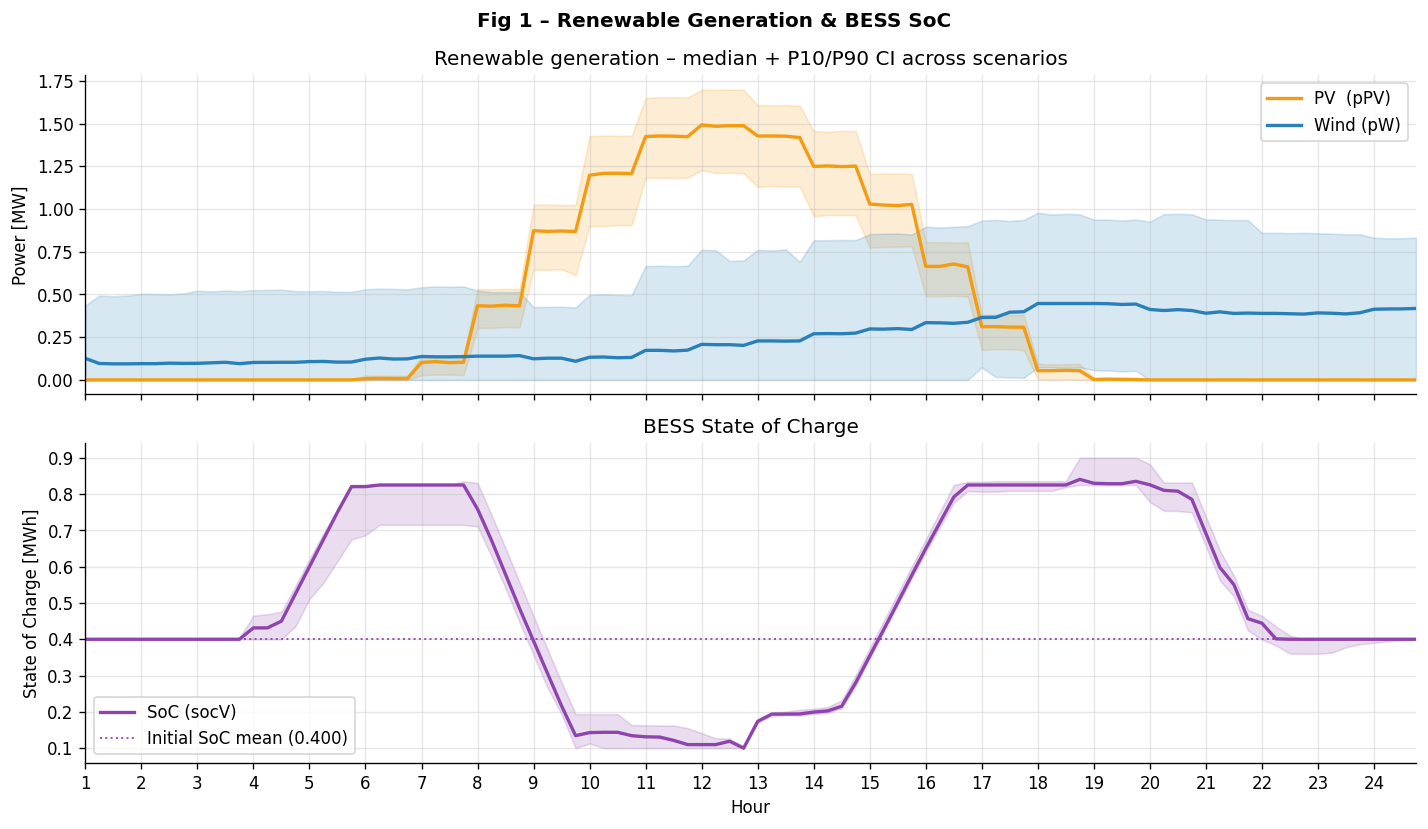

In [24]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,7), sharex=True)
fig.suptitle("Fig 1 – Renewable Generation & BESS SoC", fontweight="bold")
t = _t(next(iter(data.values())))

if "pPV" in data: _band(ax1, t, data["pPV"], COLORS["pv"],   "PV  (pPV)")
if "pW"  in data: _band(ax1, t, data["pW"],  COLORS["wind"], "Wind (pW)")
ax1.set_ylabel("Power [MW]"); ax1.legend(); ax1.grid(alpha=0.3)
ax1.set_title("Renewable generation – median + P10/P90 CI across scenarios")

if "socV" in data:
    _band(ax2, t, data["socV"], COLORS["bess"], "SoC (socV)")
    _annotate_socv_initial(ax2)
ax2.set_ylabel("State of Charge [MWh]"); ax2.legend(); ax2.grid(alpha=0.3)
ax2.set_title("BESS State of Charge")
ax2.set_xlabel(CONFIG["period_label"])
_format_hour_axis(ax2, t if "t" in globals() else None)

plt.tight_layout(); _save(fig, "fig1_generation"); plt.show()


## 5 · Fig 2 – BESS Operation (cV_dV & idV)

**What to look for:**
- `cV_dV > 0` → BESS is charging; `< 0` → discharging. Diverging colours make this instant to read.
- `idV` bar height → in what fraction of scenarios is the BESS actually dispatched to discharge at that hour.
- Discrepancy between median `cV_dV < 0` and low `idV` → some scenarios charge while others discharge (high uncertainty in dispatch decision).


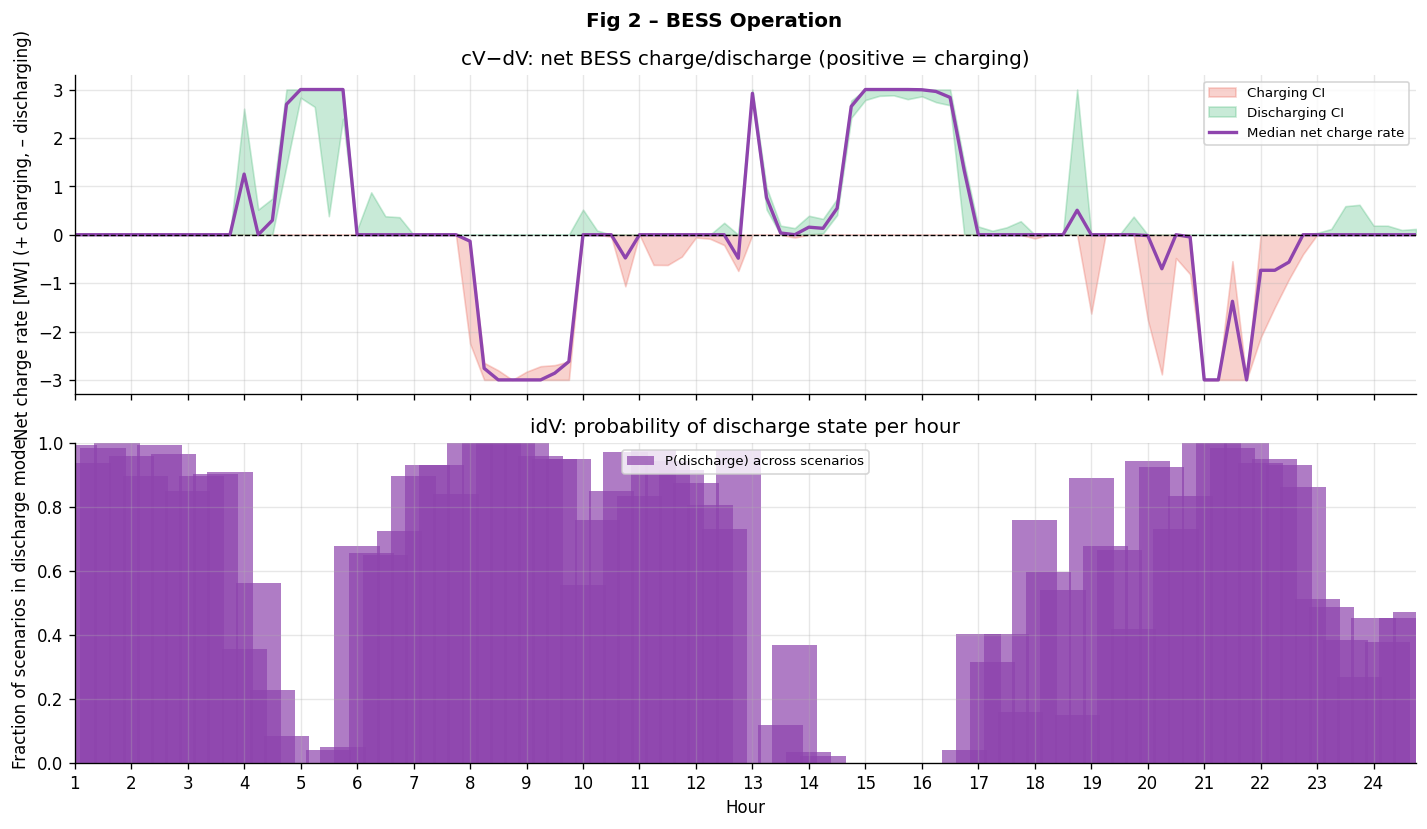

In [25]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,7), sharex=True)
fig.suptitle("Fig 2 – BESS Operation", fontweight="bold")
t = _t(next(iter(data.values())))

if "cV_dV" in data:
    med, lo, hi = _ci(data["cV_dV"])
    ax1.fill_between(t, np.minimum(lo,0), np.minimum(hi,0), color=COLORS["neg"], alpha=0.25, label="Charging CI")
    ax1.fill_between(t, np.maximum(lo,0), np.maximum(hi,0), color=COLORS["pos"], alpha=0.25, label="Discharging CI")
    ax1.plot(t, med, color=COLORS["bess"], lw=2, label="Median net charge rate")
    ax1.axhline(0, color="k", lw=0.8, ls="--")
ax1.set_ylabel("Net charge rate [MW] (+ charging, – discharging)")
ax1.legend(fontsize=8); ax1.grid(alpha=0.3)
ax1.set_title("cV−dV: net BESS charge/discharge (positive = charging)")

if "idV" in data:
    ax2.bar(t, data["idV"].mean(axis=1), color=COLORS["bess"], alpha=0.7, label="P(discharge) across scenarios")
    ax2.set_ylim(0,1)
    ax2.set_ylabel("Fraction of scenarios in discharge mode")
    ax2.legend(fontsize=8); ax2.grid(alpha=0.3)
    ax2.set_title("idV: probability of discharge state per hour")
ax2.set_xlabel(CONFIG["period_label"])
_format_hour_axis(ax2, t if "t" in globals() else None)

plt.tight_layout(); _save(fig, "fig2_bess_operation"); plt.show()


## 6 · Fig 3 – Flexible Demand

**What to look for:**
- Panel (a): total `var_fd` — does the EC smooth its demand effectively?
- Panel (b): mirrored `var_afd_p` / `var_afd_m` — are both shifts active simultaneously (arbitrage) or mutually exclusive?
- Panel (c): boxplot of **net shift** — wide boxes indicate high scenario uncertainty in how the FD is used. Outliers suggest extreme activation events.


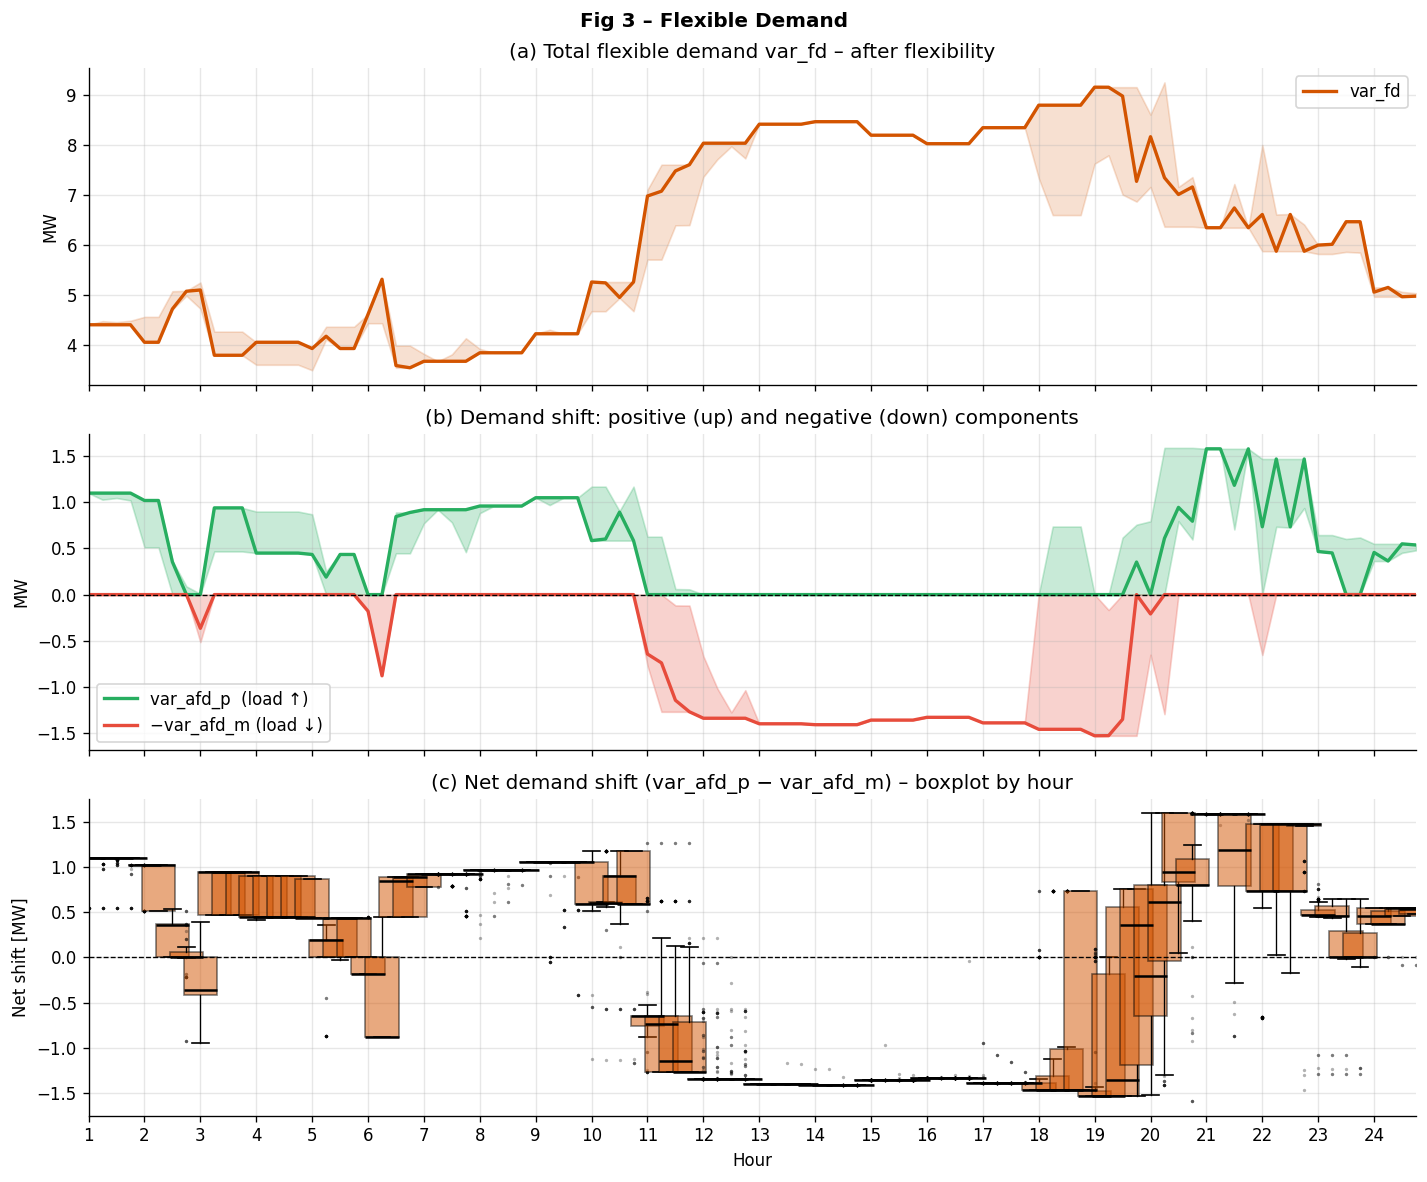

In [26]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12,10), sharex=True)
fig.suptitle("Fig 3 – Flexible Demand", fontweight="bold")
t = _t(next(iter(data.values())))

# (a) total flexible demand
if "var_fd" in data:
    _band(ax1, t, data["var_fd"], COLORS["fd"], "var_fd")
ax1.set_ylabel("MW"); ax1.legend(); ax1.grid(alpha=0.3)
ax1.set_title("(a) Total flexible demand var_fd – after flexibility")

# (b) positive / negative shifts mirrored
if "var_afd_p" in data and "var_afd_m" in data:
    med_p, lp, hp = _ci(data["var_afd_p"])
    med_m, lm, hm = _ci(data["var_afd_m"])
    ax2.fill_between(t,  lp,  hp, color=COLORS["pos"], alpha=0.25)
    ax2.plot(t, med_p, color=COLORS["pos"], lw=2, label="var_afd_p  (load ↑)")
    ax2.fill_between(t, -hm, -lm, color=COLORS["neg"], alpha=0.25)
    ax2.plot(t, -med_m, color=COLORS["neg"], lw=2, label="−var_afd_m (load ↓)")
    ax2.axhline(0, color="k", lw=0.8, ls="--")
ax2.set_ylabel("MW"); ax2.legend(); ax2.grid(alpha=0.3)
ax2.set_title("(b) Demand shift: positive (up) and negative (down) components")

# (c) net shift boxplot per hour
if "var_afd_p" in data and "var_afd_m" in data:
    net = (data["var_afd_p"] - data["var_afd_m"]).values
    ax3.boxplot([net[i,:] for i in range(len(t))],
                positions=t, widths=0.6, patch_artist=True,
                boxprops=dict(facecolor=COLORS["fd"], alpha=0.5),
                medianprops=dict(color="k", lw=1.5),
                whiskerprops=dict(lw=0.8),
                flierprops=dict(marker=".", ms=2, alpha=0.3))
    ax3.axhline(0, color="k", lw=0.8, ls="--")
ax3.set_ylabel("Net shift [MW]"); ax3.grid(alpha=0.3)
ax3.set_title("(c) Net demand shift (var_afd_p − var_afd_m) – boxplot by hour")
ax3.set_xlabel(CONFIG["period_label"])
_format_hour_axis(ax3, t if "t" in globals() else None)

plt.tight_layout(); _save(fig, "fig3_flexible_demand"); plt.show()


## 7 · Fig 4 – Day-Ahead Commitment 
**What to look for:**
- **Panel (a):** committed energy in DA
- **Panel (b):** commited energy in RM
- **Panel (c):** commited energy in IM1
- **Panel (d):** commited energy in IM2
- **Panel (e):** commited energy in IM3


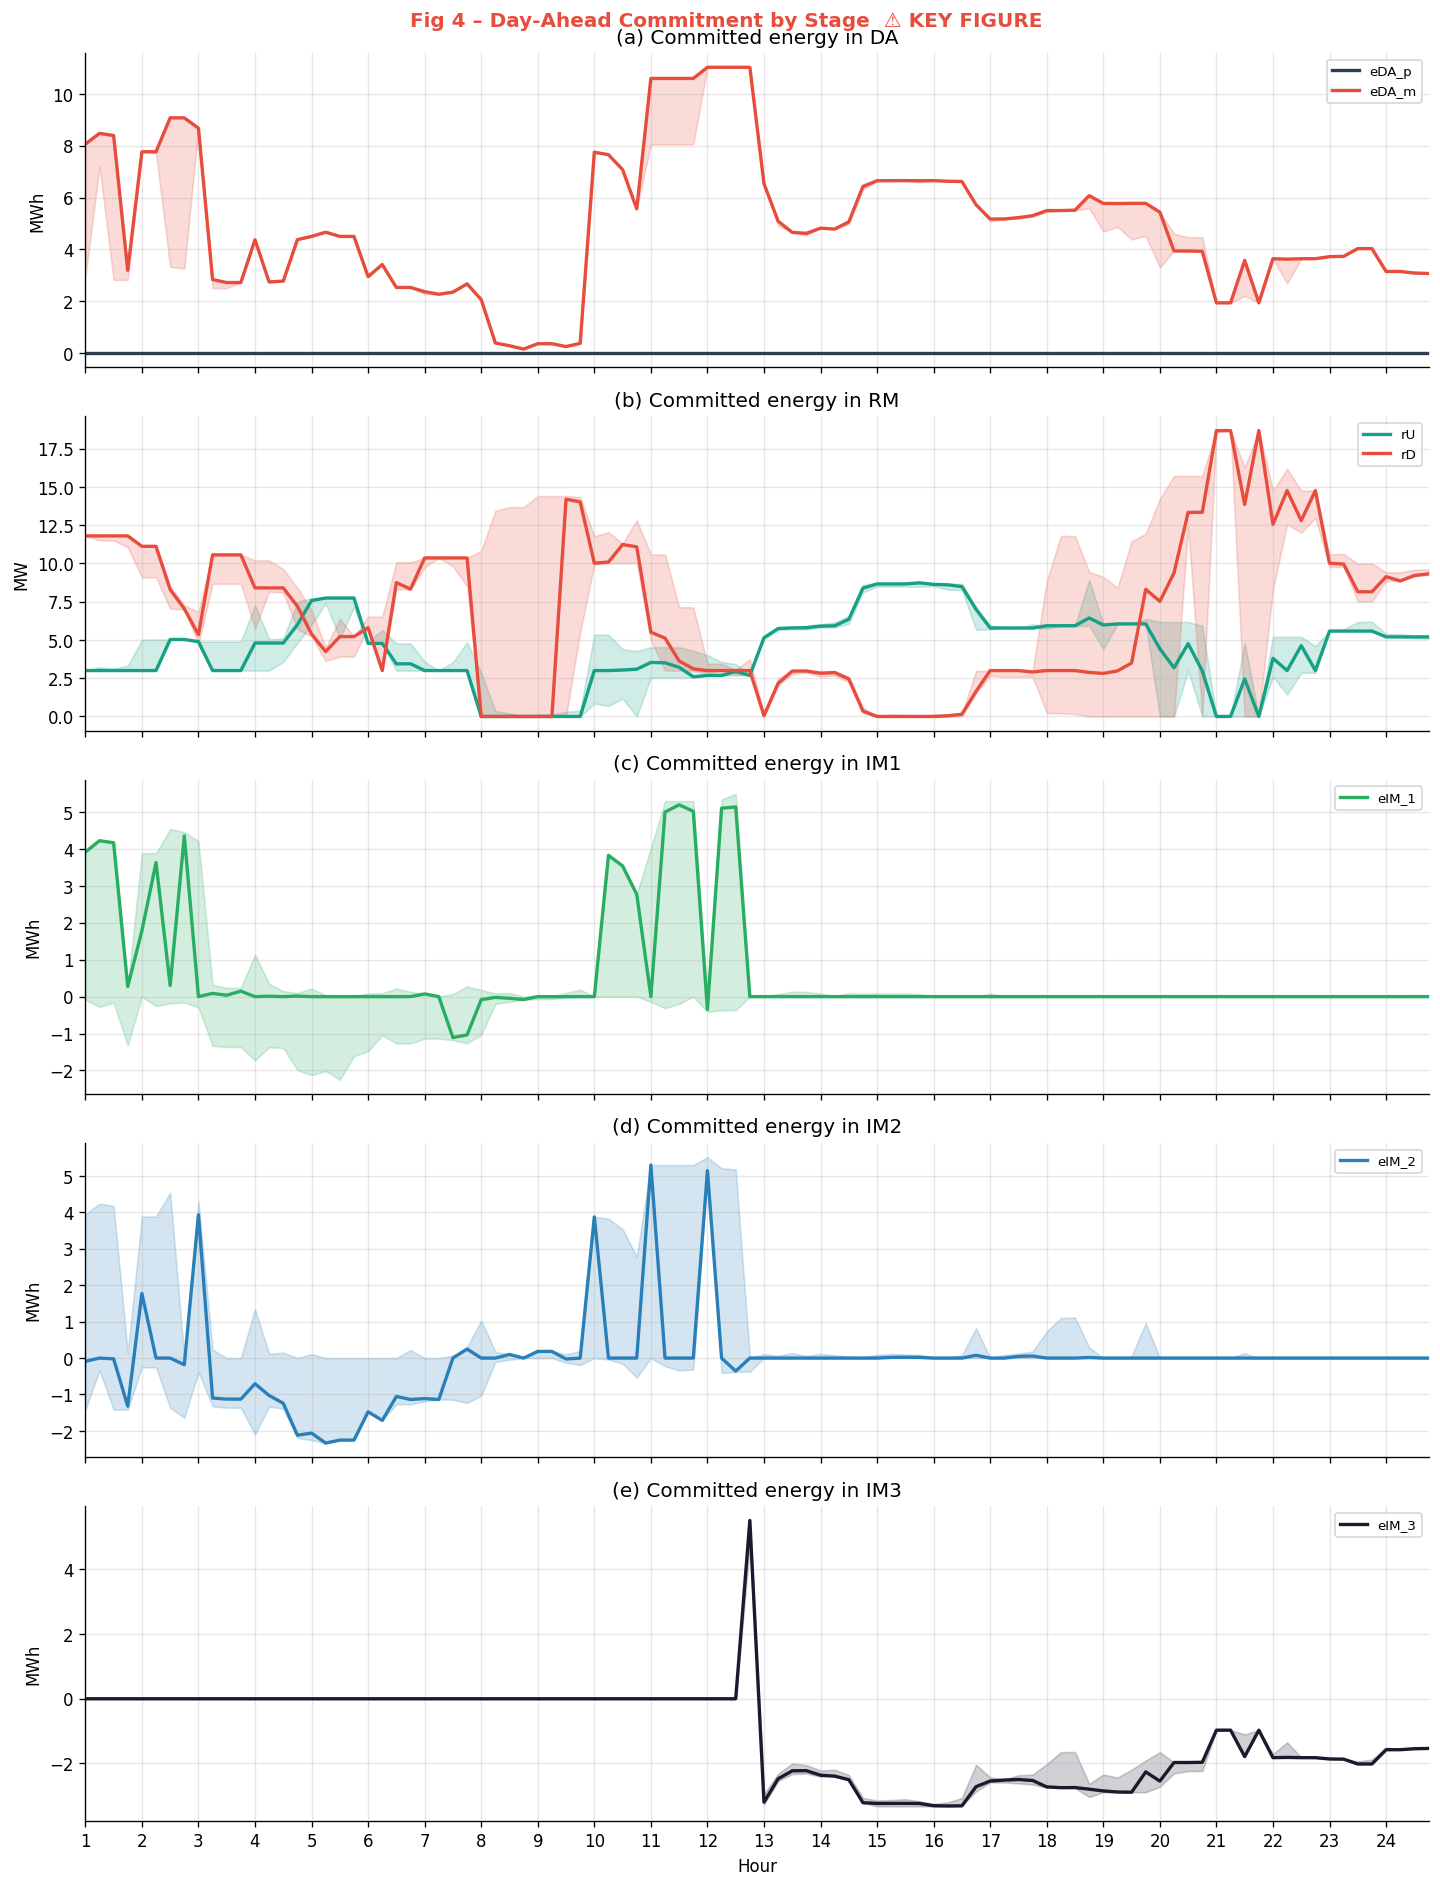

In [27]:
fig, axs = plt.subplots(5, 1, figsize=(12,16), sharex=True)
fig.suptitle("Fig 4 – Day-Ahead Commitment by Stage  ⚠️ KEY FIGURE",
             fontweight="bold", color=COLORS["neg"])
t = _t(next(iter(data.values())))

# (a) committed energy in DA
if "eDA_p" in data:
    med, lo, hi = _ci(data["eDA_p"])
    axs[0].fill_between(t, lo, hi, color=COLORS["da"], alpha=0.2)
    axs[0].plot(t, med, lw=2, color=COLORS["da"], label="eDA_p")
if "eDA_m" in data:
    med, lo, hi = _ci(data["eDA_m"])
    axs[0].fill_between(t, lo, hi, color=COLORS["neg"], alpha=0.2)
    axs[0].plot(t, med, lw=2, color=COLORS["neg"], label="eDA_m")
axs[0].set_ylabel("MWh"); axs[0].legend(fontsize=8); axs[0].grid(alpha=0.3)
axs[0].set_title("(a) Committed energy in DA")

# (b) committed energy in RM
if "rU" in data:
    med, lo, hi = _ci(data["rU"])
    axs[1].fill_between(t, lo, hi, color=COLORS["reserve"], alpha=0.2)
    axs[1].plot(t, med, lw=2, color=COLORS["reserve"], label="rU")
if "rD" in data:
    med, lo, hi = _ci(data["rD"])
    axs[1].fill_between(t, lo, hi, color=COLORS["neg"], alpha=0.2)
    axs[1].plot(t, med, lw=2, color=COLORS["neg"], label="rD")
axs[1].set_ylabel("MW"); axs[1].legend(fontsize=8); axs[1].grid(alpha=0.3)
axs[1].set_title("(b) Committed energy in RM")

# (c) committed energy in IM1
if "eIM_1" in data:
    med, lo, hi = _ci(data["eIM_1"])
    axs[2].fill_between(t, lo, hi, color=COLORS["pos"], alpha=0.2)
    axs[2].plot(t, med, lw=2, color=COLORS["pos"], label="eIM_1")
axs[2].set_ylabel("MWh"); axs[2].legend(fontsize=8); axs[2].grid(alpha=0.3)
axs[2].set_title("(c) Committed energy in IM1")

# (d) committed energy in IM2
if "eIM_2" in data:
    med, lo, hi = _ci(data["eIM_2"])
    axs[3].fill_between(t, lo, hi, color=COLORS["wind"], alpha=0.2)
    axs[3].plot(t, med, lw=2, color=COLORS["wind"], label="eIM_2")
axs[3].set_ylabel("MWh"); axs[3].legend(fontsize=8); axs[3].grid(alpha=0.3)
axs[3].set_title("(d) Committed energy in IM2")

# (e) committed energy in IM3
if "eIM_3" in data:
    med, lo, hi = _ci(data["eIM_3"])
    axs[4].fill_between(t, lo, hi, color=COLORS["median"], alpha=0.2)
    axs[4].plot(t, med, lw=2, color=COLORS["median"], label="eIM_3")
axs[4].set_ylabel("MWh"); axs[4].legend(fontsize=8); axs[4].grid(alpha=0.3)
axs[4].set_title("(e) Committed energy in IM3")
axs[4].set_xlabel(CONFIG["period_label"])
_format_hour_axis(axs[4], t if "t" in globals() else None)

plt.tight_layout(); _save(fig, "fig4_da_commitment"); plt.show()

## 8 · Fig 5 – Reserve Provision (Upward & Downward)

**What to look for:**
- Which asset (BESS vs FD) carries the bulk of reserve provision at each hour.
- Dashed total line vs. stacked area → if total > BESS + FD something is off (data check).
- Wide CI on the total reserve → significant scenario uncertainty in reserve matching.


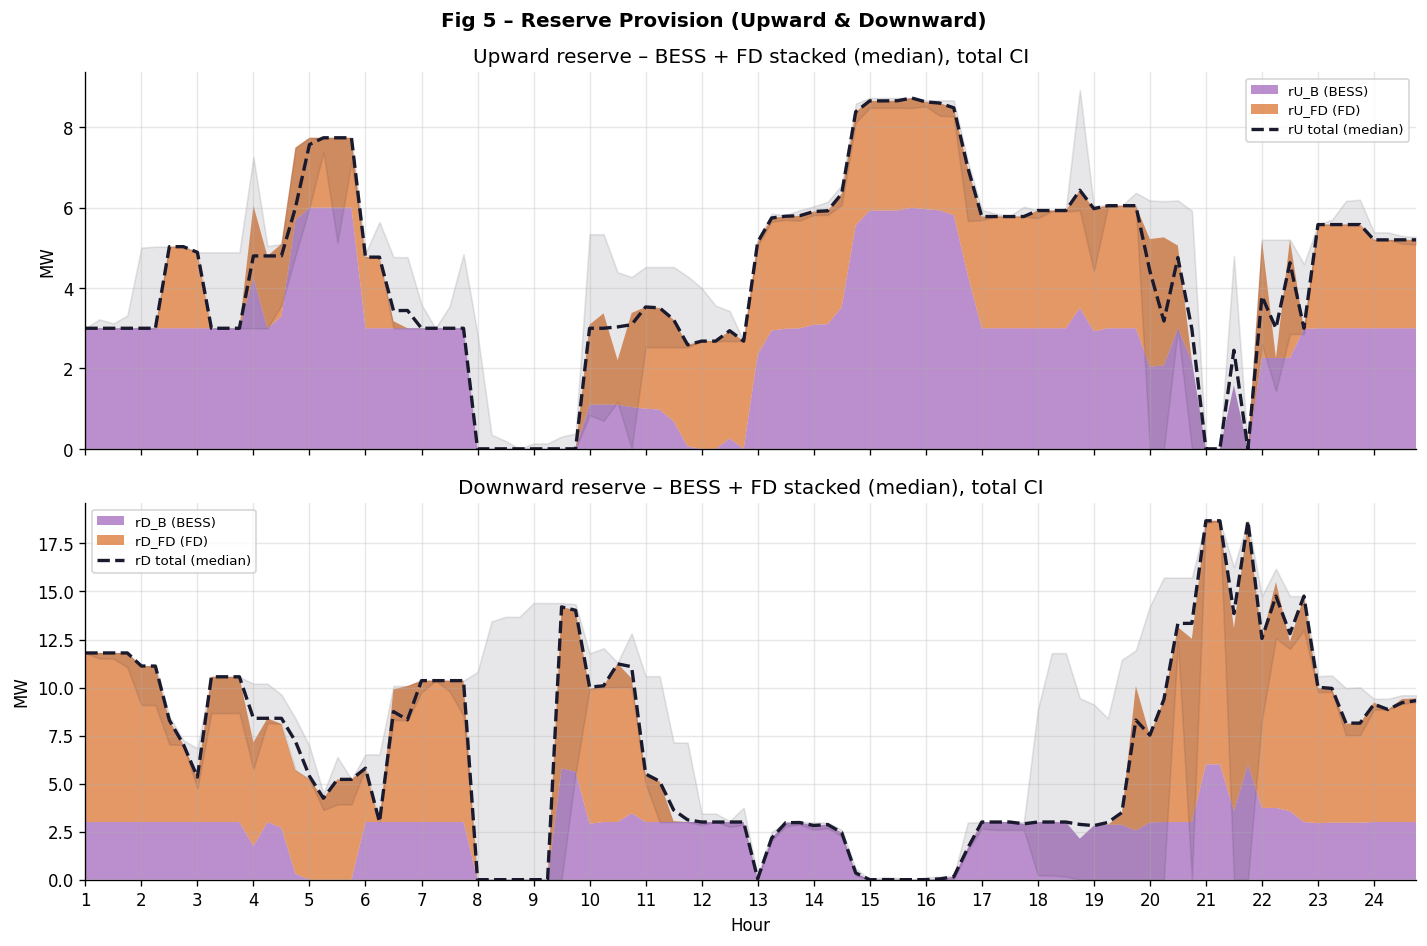

In [28]:
fig, (ax_u, ax_d) = plt.subplots(2, 1, figsize=(12,8), sharex=True)
fig.suptitle("Fig 5 – Reserve Provision (Upward & Downward)", fontweight="bold")
t = _t(next(iter(data.values())))

for ax, label, r_tot, r_b, r_fd in [
    (ax_u, "Upward",   "rU",  "rU_B",  "rU_FD"),
    (ax_d, "Downward", "rD",  "rD_B",  "rD_FD"),
]:
    med_b  = data[r_b ].median(axis=1).values if r_b  in data else np.zeros(len(t))
    med_fd = data[r_fd].median(axis=1).values if r_fd in data else np.zeros(len(t))
    ax.stackplot(t, med_b, med_fd,
                 labels=[f"{r_b} (BESS)", f"{r_fd} (FD)"],
                 colors=[COLORS["bess"], COLORS["fd"]], alpha=0.6)
    if r_tot in data:
        med_tot, lo, hi = _ci(data[r_tot])
        ax.plot(t, med_tot, color=COLORS["median"], lw=2, ls="--",
                label=f"{r_tot} total (median)")
        ax.fill_between(t, lo, hi, color=COLORS["median"], alpha=0.1)
    ax.set_ylabel("MW"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax.set_title(f"{label} reserve – BESS + FD stacked (median), total CI")

ax_d.set_xlabel(CONFIG["period_label"])
_format_hour_axis(ax_d, t if "t" in globals() else None)
plt.tight_layout(); _save(fig, "fig5_reserves"); plt.show()


## 9 · Fig 6 – Imbalance & Intraday Position ⚠️ KEY FIGURE

**What to look for:**
- **Panel (a):** mirrored pIB_p / pIB_m — does the EC mostly over-deliver or under-deliver?
- **Panel (b):** net imbalance bars — red hours = under-delivery (penalty exposure); green = over-delivery (spill or revenue).
- **Panel (c):** `eIM` — does intraday trading reduce imbalance at the same hours where panel (b) is red? If yes, the intraday market is effective.


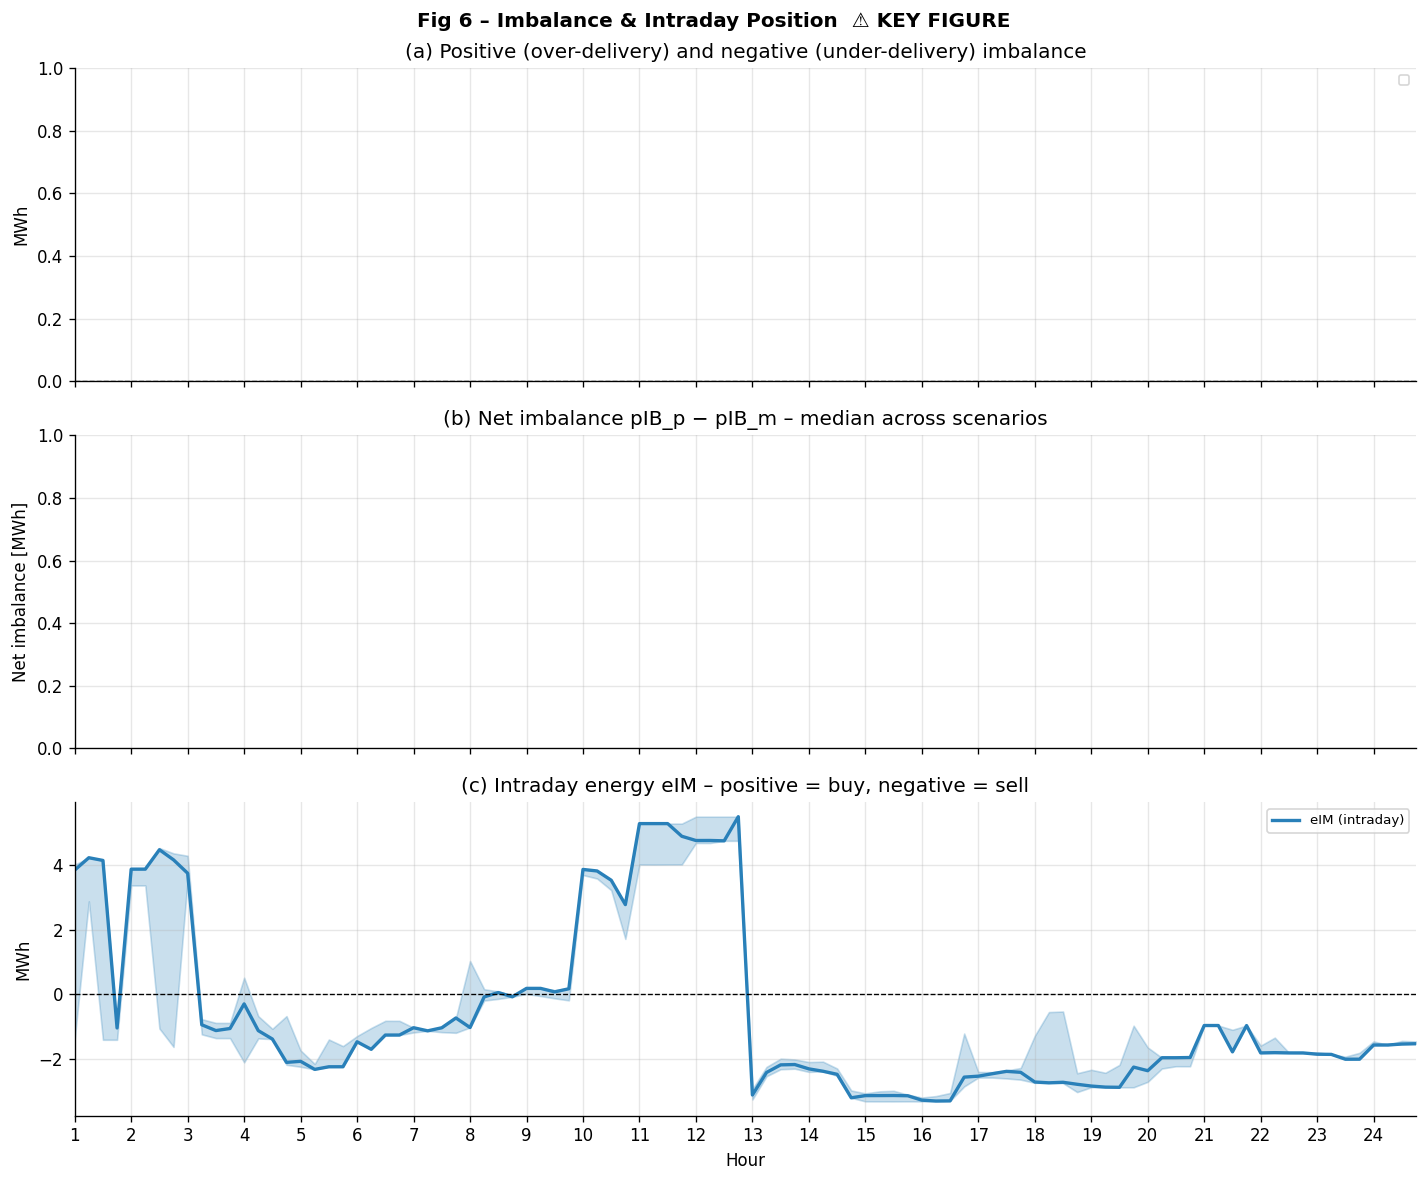

In [29]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12,10), sharex=True)
fig.suptitle("Fig 6 – Imbalance & Intraday Position  ⚠️ KEY FIGURE", fontweight="bold")
t = _t(next(iter(data.values())))

# (a) pIB_p / pIB_m mirrored
if "pIB_p" in data:
    _band(ax1, t, data["pIB_p"], COLORS["pos"], "pIB_p (over-delivery)")
if "pIB_m" in data:
    med_m, lo_m, hi_m = _ci(data["pIB_m"])
    ax1.fill_between(t, -hi_m, -lo_m, color=COLORS["neg"], alpha=0.18)
    ax1.plot(t, -med_m, color=COLORS["neg"], lw=2, label="−pIB_m (under-delivery)")
ax1.axhline(0, color="k", lw=0.8, ls="--")
ax1.set_ylabel("MWh"); ax1.legend(fontsize=8); ax1.grid(alpha=0.3)
ax1.set_title("(a) Positive (over-delivery) and negative (under-delivery) imbalance")

# (b) net imbalance bar
if "pIB_p" in data and "pIB_m" in data:
    net_med = (data["pIB_p"] - data["pIB_m"]).median(axis=1).values
    ax2.bar(t, net_med, color=[COLORS["pos"] if v>=0 else COLORS["neg"] for v in net_med], alpha=0.75)
    ax2.axhline(0, color="k", lw=0.8)
ax2.set_ylabel("Net imbalance [MWh]"); ax2.grid(alpha=0.3)
ax2.set_title("(b) Net imbalance pIB_p − pIB_m – median across scenarios")

# (c) eIM intraday
if "eIM" in data:
    med_im, lo_im, hi_im = _ci(data["eIM"])
    ax3.fill_between(t, lo_im, hi_im, color=COLORS["wind"], alpha=0.25)
    ax3.plot(t, med_im, color=COLORS["wind"], lw=2, label="eIM (intraday)")
    ax3.axhline(0, color="k", lw=0.8, ls="--")
ax3.set_ylabel("MWh"); ax3.legend(fontsize=8); ax3.grid(alpha=0.3)
ax3.set_title("(c) Intraday energy eIM – positive = buy, negative = sell")
ax3.set_xlabel(CONFIG["period_label"])
_format_hour_axis(ax3, t if "t" in globals() else None)

plt.tight_layout(); _save(fig, "fig6_imbalance"); plt.show()


## 10 · Fig 7 – Scenario Fan Charts (spaghetti)

**What to look for:**
- Are traces clustered (low spread) or spread widely (high uncertainty)?
- Bimodal shapes → two distinct operating regimes across scenarios.
- Extreme outlier traces → which scenario drives the worst case?

> You can change `vars_to_show` to inspect any subset of variables.


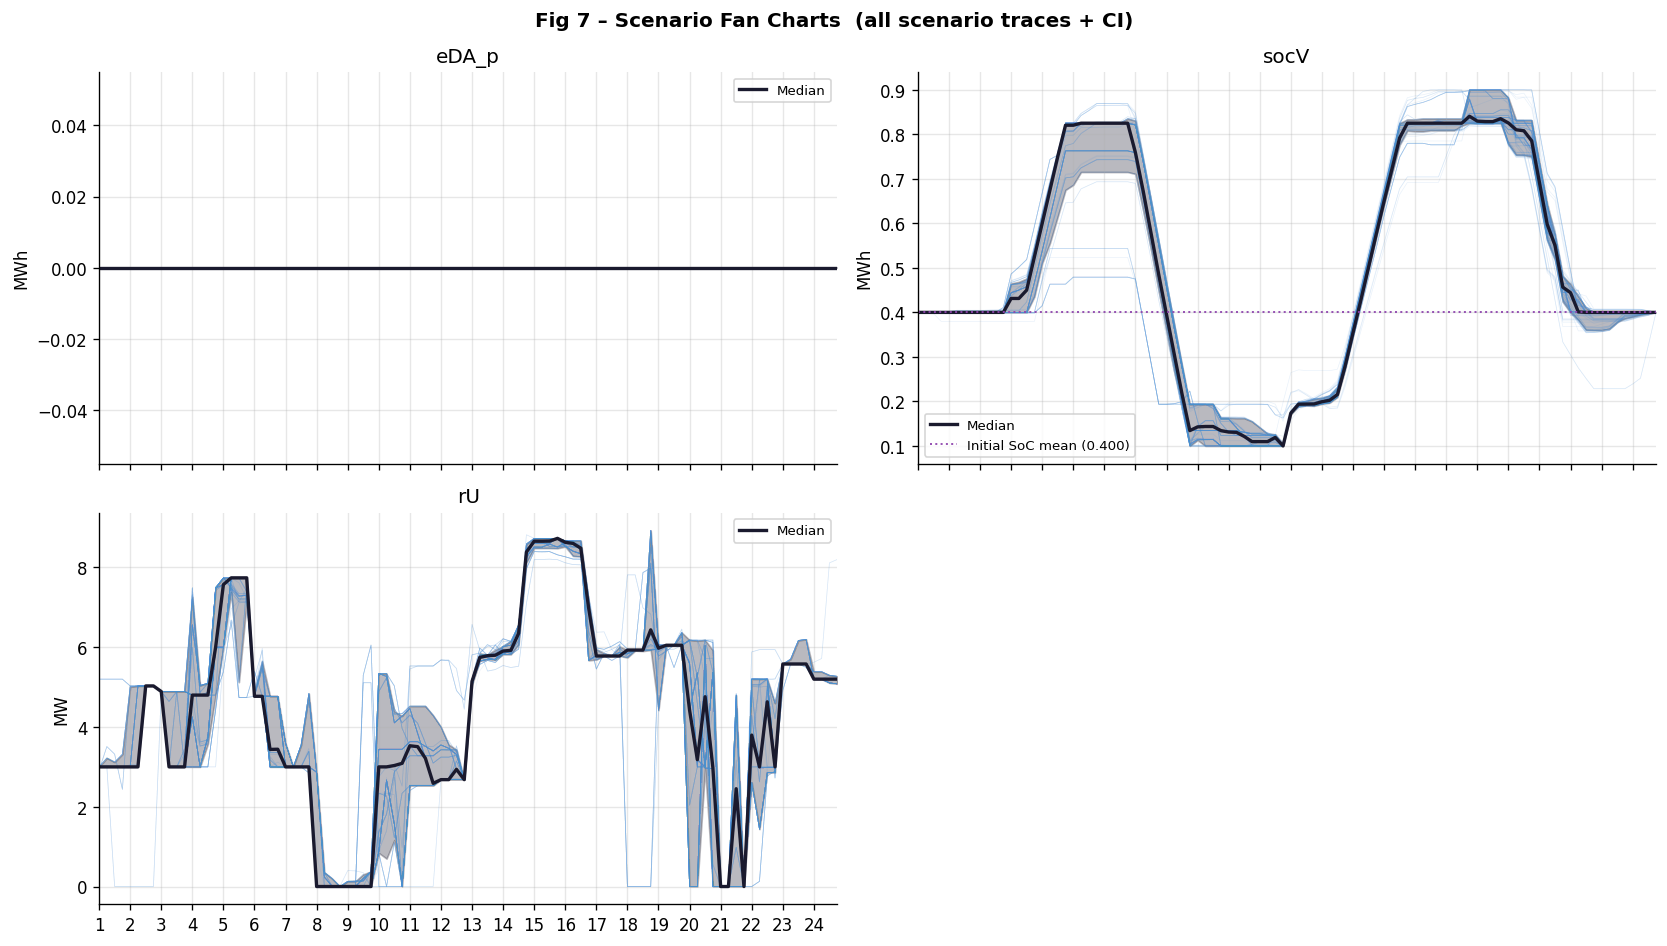

In [30]:
vars_to_show = ["eDA_p", "socV", "rU", "pIB_p"]   # ← edit here
vars_to_show = [v for v in vars_to_show if v in data]

ncols = 2
nrows = int(np.ceil(len(vars_to_show)/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4*nrows), sharex=True)
axes = np.array(axes).flatten()
fig.suptitle("Fig 7 – Scenario Fan Charts  (all scenario traces + CI)", fontweight="bold")
t = _t(next(iter(data.values())))

for ax, var in zip(axes, vars_to_show):
    df = data[var]
    for col in df.columns:
        ax.plot(t, df[col].values, color=COLORS["ci_fill"], lw=0.4, alpha=0.12)
    _band(ax, t, df, COLORS["median"], "Median", alpha=0.3)
    if var == "socV":
        _annotate_socv_initial(ax)
    ax.set_title(var); ax.set_ylabel(UNITS.get(var,"–")); ax.grid(alpha=0.3); ax.legend(fontsize=8)

for ax in axes[len(vars_to_show):]: ax.set_visible(False)
axes[-1].set_xlabel(CONFIG["period_label"])
_format_hour_axis(axes[-1], t if "t" in globals() else None)
plt.tight_layout(); _save(fig, "fig7_scenario_fans"); plt.show()


## 11 ? Market Benefit Distribution

Boxplot of total scenario benefit by market. CI markers show P10-P90 across scenarios.


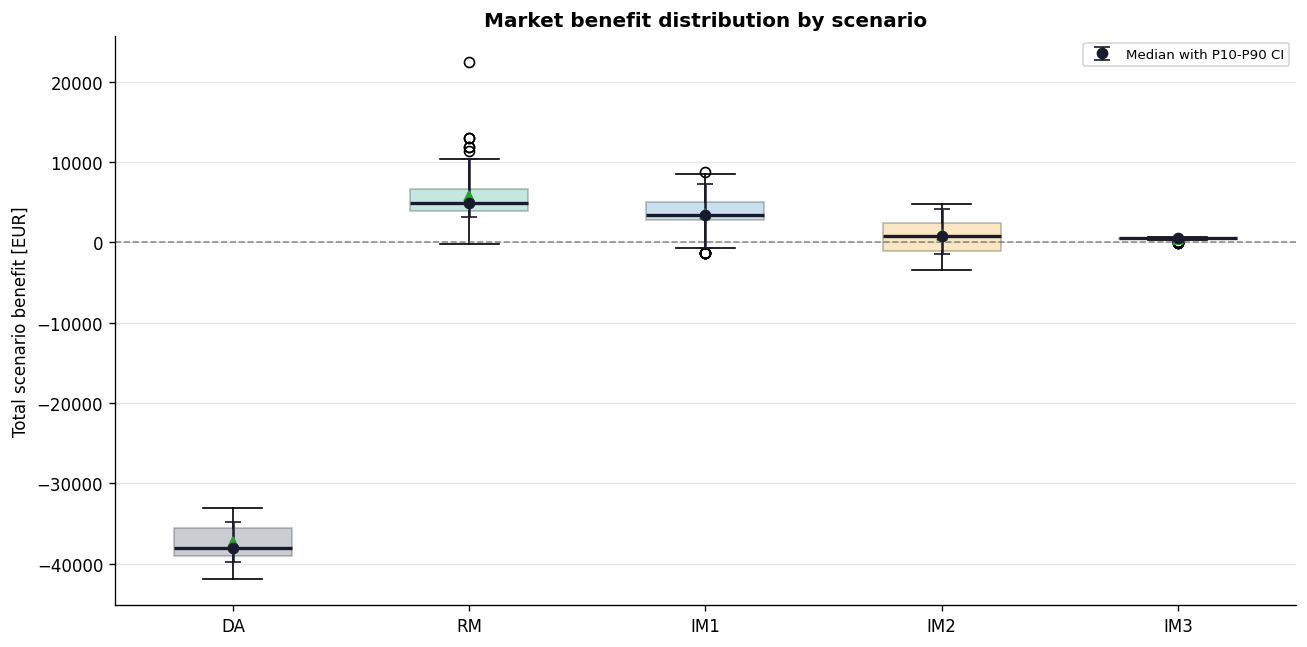

,median,P10,P90,mean
DA,-38100.8633,-39829.5263,-34819.0523,-37365.6268
RM,4884.1984,3153.9630,10378.7916,5807.7789
IM1,3381.1058,-650.6356,7212.1503,3530.3841
IM2,846.8879,-1424.5051,4127.7891,960.2406
IM3,501.7149,325.6442,602.1389,469.1066


In [31]:
def _aligned_product_total(*dfs):
    dfs = [df for df in dfs if df is not None]
    if not dfs:
        return None
    common_index = dfs[0].index
    common_cols = dfs[0].columns
    for df in dfs[1:]:
        common_index = common_index.intersection(df.index)
        common_cols = common_cols.intersection(df.columns)
    if len(common_index) == 0 or len(common_cols) == 0:
        return None
    prod = dfs[0].loc[common_index, common_cols].copy()
    for df in dfs[1:]:
        prod = prod * df.loc[common_index, common_cols]
    return prod.sum(axis=0)

market_benefits = {}

if {"lD", "eDA_p", "eDA_m"}.issubset(data):
    da_net = data["eDA_p"] - data["eDA_m"]
    market_benefits["DA"] = _aligned_product_total(data["lD"], da_net)

if {"lR", "rU", "rD"}.issubset(data):
    rm_reserve = data["rU"] + data["rD"]
    market_benefits["RM"] = _aligned_product_total(data["lR"], rm_reserve)

for i in [1, 2, 3]:
    li = f"lI_{i}"
    ei = f"eIM_{i}"
    if {li, ei}.issubset(data):
        market_benefits[f"IM{i}"] = _aligned_product_total(data[li], data[ei])

if {"lPIB", "pIB_p", "lNIB", "pIB_m"}.issubset(data):
    ib_income = _aligned_product_total(data["lPIB"], data["pIB_p"])
    ib_costs = _aligned_product_total(data["lNIB"], data["pIB_m"])
    if ib_income is not None and ib_costs is not None:
        common_cols = ib_income.index.intersection(ib_costs.index)
        market_benefits["IB"] = ib_income.loc[common_cols] - ib_costs.loc[common_cols]

market_order = ["DA", "RM", "IM1", "IM2", "IM3", "IB"]
market_benefits = {k: market_benefits[k].dropna() for k in market_order if k in market_benefits and market_benefits[k] is not None}

if not market_benefits:
    print("No market benefit data available for this run.")
else:
    labels = list(market_benefits.keys())
    values = [market_benefits[k].values for k in labels]
    positions = np.arange(1, len(labels) + 1)

    fig, ax = plt.subplots(figsize=(11, 5.5))
    bp = ax.boxplot(values, positions=positions, labels=labels, patch_artist=True, showmeans=True)
    for patch, color in zip(bp["boxes"], [COLORS["da"], COLORS["reserve"], COLORS["wind"], COLORS["pv"], COLORS["fd"], COLORS["imbal"]]):
        patch.set_facecolor(color)
        patch.set_alpha(0.25)
    for med in bp["medians"]:
        med.set_color(COLORS["median"])
        med.set_linewidth(2)

    ci_low, ci_high = CONFIG["ci_low"], CONFIG["ci_high"]
    medians = np.array([np.median(v) for v in values])
    lo = np.array([np.percentile(v, ci_low) for v in values])
    hi = np.array([np.percentile(v, ci_high) for v in values])
    ax.errorbar(positions, medians, yerr=[medians - lo, hi - medians], fmt="o",
                color=COLORS["median"], ecolor=COLORS["median"], capsize=5,
                label=f"Median with P{ci_low}-P{ci_high} CI")
    ax.axhline(0, color="#666666", lw=1, ls="--", alpha=0.7)
    ax.set_ylabel("Total scenario benefit [EUR]")
    ax.set_title("Market benefit distribution by scenario", fontweight="bold")
    ax.grid(axis="y", alpha=0.3)
    ax.legend(fontsize=8)
    plt.tight_layout(); _save(fig, "fig_market_benefits_boxplot"); plt.show()

    benefit_summary = pd.DataFrame({
        "median": medians,
        f"P{ci_low}": lo,
        f"P{ci_high}": hi,
        "mean": [np.mean(v) for v in values],
    }, index=labels)
    display(benefit_summary)


## 11 · Fig 8 – Correlation Heatmap

**What to look for:**
- Strong positive correlation (dark blue) between PV/Wind and reserve/FD → renewable surplus drives reserve provision.
- Strong negative correlation between `socV` and `pIB_m` → better SoC management reduces imbalance penalties.
- Any unexpected high correlation that reveals hidden structural coupling in the model.


Excluded constant variables from correlation heatmap: ['eDA_p', 'ieDA_m', 'ieDA_p']
Correlation heatmap uses 27 operational variables with shared index 96 time points.


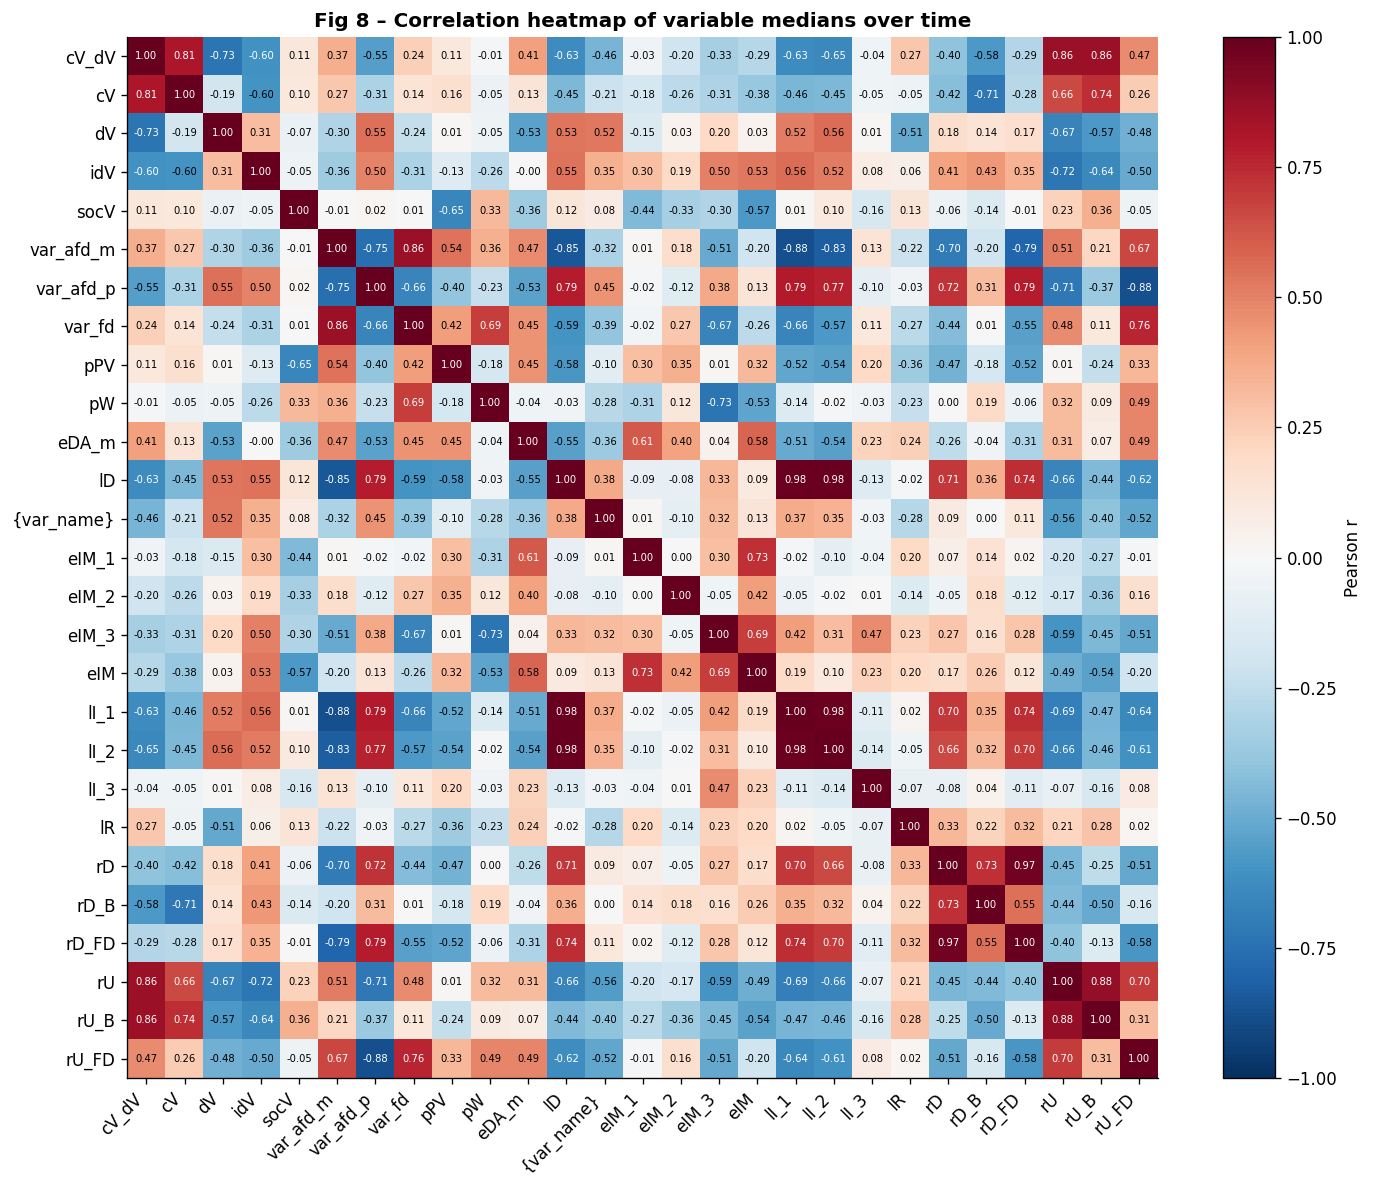

In [32]:
op_data = _operational_ts_data(data)
med_df = pd.DataFrame({v: df.median(axis=1) for v, df in op_data.items()})
empty_vars = med_df.columns[med_df.isna().all()].tolist()
if empty_vars:
    print("Dropped empty variables from correlation heatmap:", empty_vars)
med_df = med_df.dropna(axis=1, how="all")
std = med_df.std(axis=0)
constant_vars = std[std <= 1e-12].index.tolist()
if constant_vars:
    print("Excluded constant variables from correlation heatmap:", constant_vars)
med_df = med_df.loc[:, std > 1e-12]
corr = med_df.corr(min_periods=2)
if corr.isna().any().any():
    print("Warning: correlation contains NaN values due to insufficient data for some variable pairs. NaN values are preserved.")
print(f"Correlation heatmap uses {med_df.shape[1]} operational variables with shared index {med_df.shape[0]} time points.")

fig, ax = plt.subplots(figsize=(12,10))
cmap = plt.get_cmap("RdBu_r").copy()
cmap.set_bad("#d3d3d3")
im = ax.imshow(corr.values, cmap=cmap, vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, label="Pearson r")
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        val = corr.values[i,j]
        text = f"{val:.2f}" if not np.isnan(val) else "NaN"
        color = "white" if not np.isnan(val) and abs(val) > 0.6 else "black"
        ax.text(j, i, text, ha="center", va="center",
                fontsize=6, color=color)
ax.set_title("Fig 8 – Correlation heatmap of variable medians over time", fontweight="bold")
plt.tight_layout(); _save(fig, "fig8_correlation"); plt.show()


## 12 · Fig 9 – Commitment Failure Dashboard ⚠️ KEY FIGURE

One-page answer to *"when and how severely did the EC miss its day-ahead commitments?"*

| Sub-panel | What it shows |
|---|---|
| **(a) Risk strip** | colour = fraction of scenarios with `pIB_m > 0`; red hours = most risky |
| **(b) Shortfall bars** | median magnitude of `pIB_m` (CI band) |
| **(c) Delivered power** | actual delivered power from `pPV + pW - cV_dV` when available; otherwise show `pIB_m` under-delivery proxy |
| **(d) CDF** | cumulative distribution of total daily under-delivery across all scenarios; P90 marks the tail risk |


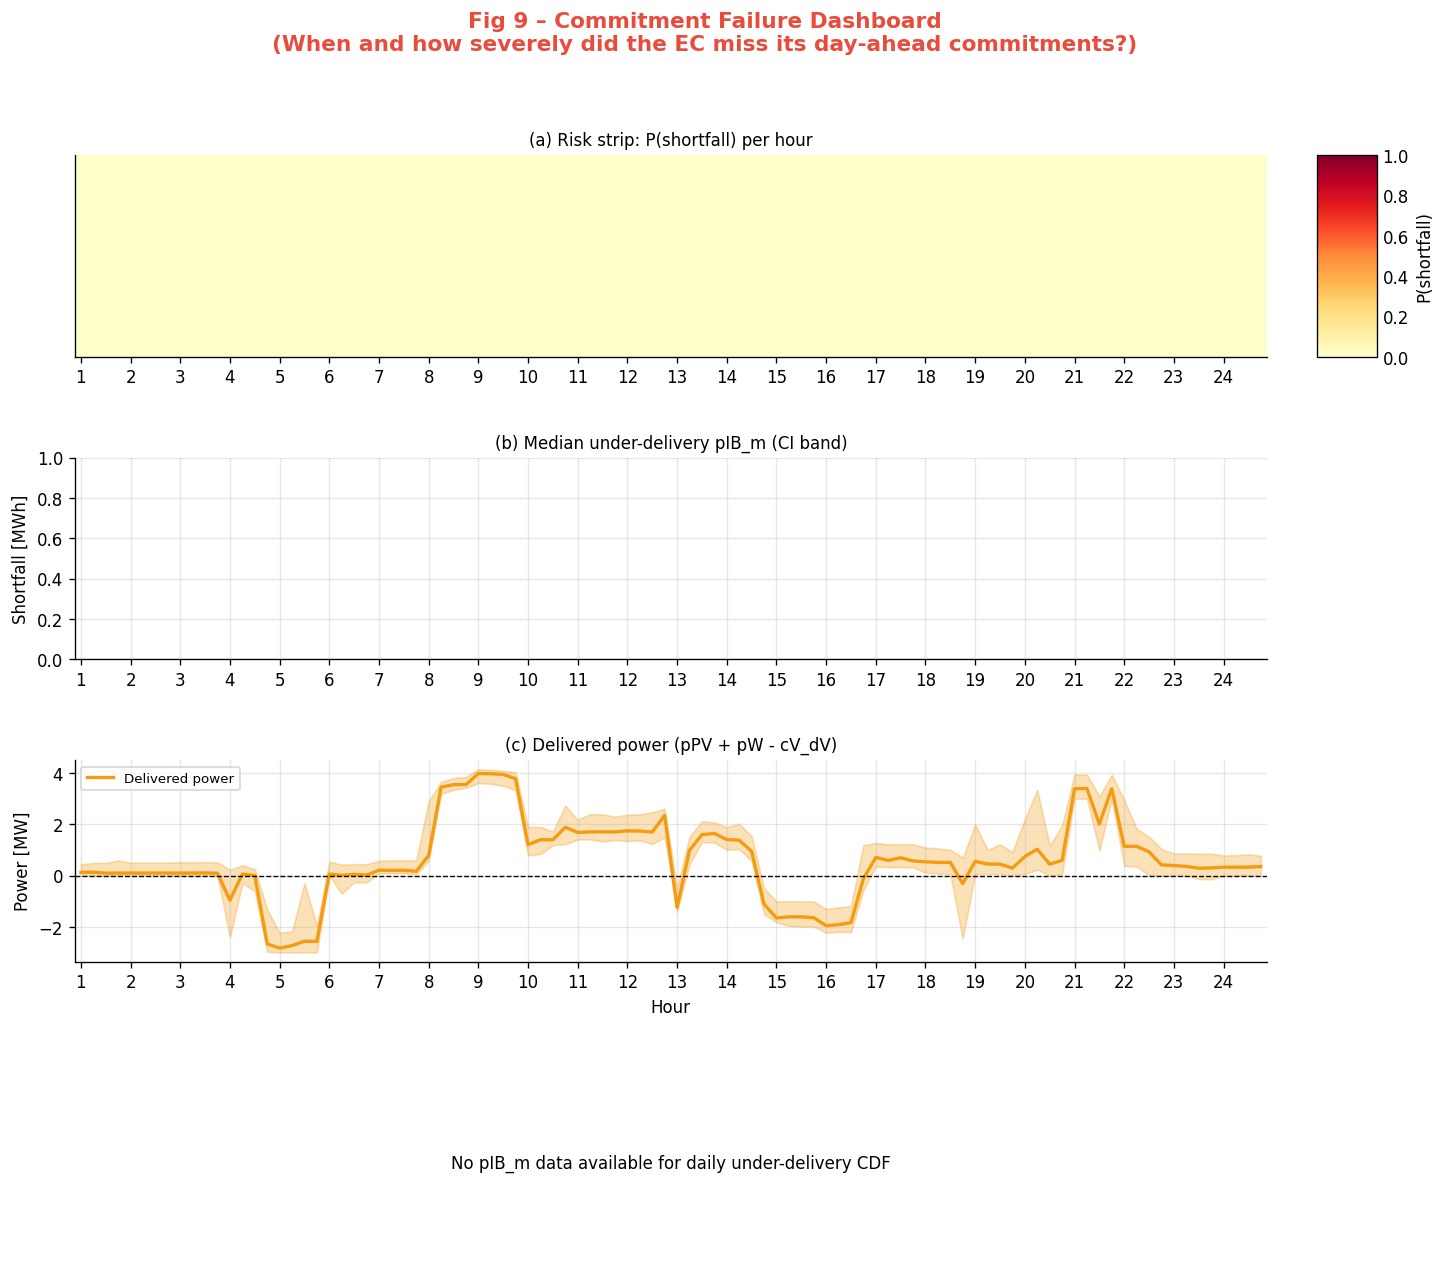

In [33]:
fig = plt.figure(figsize=(14,12))
fig.suptitle("Fig 9 – Commitment Failure Dashboard\n"
             "(When and how severely did the EC miss its day-ahead commitments?)",
             fontweight="bold", color=COLORS["neg"], fontsize=13)

gs = gridspec.GridSpec(4, 2, width_ratios=[20, 1], wspace=0.08, hspace=0.5)
ax1 = fig.add_subplot(gs[0, 0])
cax = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
ax3 = fig.add_subplot(gs[2, 0], sharex=ax1)
ax4 = fig.add_subplot(gs[3, 0])

t_arr = _t(next(iter(data.values())))
T = len(t_arr)
step = float(np.min(np.diff(t_arr))) if len(t_arr) > 1 else 1.0
x_edges = np.concatenate([t_arr - step/2, [t_arr[-1] + step/2]])
bar_width = min(0.8, step * 0.9)

# (a) risk heat-strip
prob = np.zeros(T)
if "pIB_m" in data:
    prob = (data["pIB_m"] > 1e-6).mean(axis=1).values
heat = ax1.pcolormesh(x_edges, [0, 1], prob[None, :], cmap="YlOrRd",
                      vmin=0, vmax=1, shading="auto")
fig.colorbar(heat, cax=cax, orientation="vertical")
cax.set_ylabel("P(shortfall)")
cax.yaxis.set_label_position("right")
cax.tick_params(axis="both", which="both", length=0)
ax1.set_yticks([])
ax1.set_title("(a) Risk strip: P(shortfall) per hour", fontsize=10)
ax1.set_xticks(np.arange(1, int(CONFIG["n_periods"]) + 1))
ax1.set_xticklabels([str(i) for i in range(1, int(CONFIG["n_periods"]) + 1)])
ax1.set_xlim(x_edges[0], x_edges[-1])

# (b) shortfall bars
if "pIB_m" in data:
    med, lo, hi = _ci(data["pIB_m"])
    ax2.fill_between(t_arr, lo, hi, color=COLORS["neg"], alpha=0.3)
    ax2.bar(t_arr, med, color=COLORS["neg"], alpha=0.7, width=bar_width)
ax2.set_ylabel("Shortfall [MWh]"); ax2.grid(alpha=0.3)
ax2.set_title("(b) Median under-delivery pIB_m (CI band)", fontsize=10)

# (c) delivered power
if {"pPV", "pW", "cV_dV"}.issubset(data):
    delivered = data["pPV"] + data["pW"] - data["cV_dV"]
    med_del, lo_del, hi_del = _ci(delivered)
    ax3.fill_between(t_arr, lo_del, hi_del, color=COLORS["pv"], alpha=0.3)
    ax3.plot(t_arr, med_del, color=COLORS["pv"], lw=2, label="Delivered power")
    ax3.axhline(0, color="k", lw=0.8, ls="--")
    ax3.set_ylabel("Power [MW]"); ax3.set_xlabel(CONFIG["period_label"])
    ax3.set_xticks(np.arange(1, int(CONFIG["n_periods"]) + 1))
    ax3.set_xticklabels([str(i) for i in range(1, int(CONFIG["n_periods"]) + 1)])
    ax3.set_xlim(x_edges[0], x_edges[-1])
    ax3.legend(fontsize=8); ax3.grid(alpha=0.3)
    ax3.set_title("(c) Delivered power (pPV + pW - cV_dV)", fontsize=10)
else:
    if "pIB_m" in data:
        med_ib, lo_ib, hi_ib = _ci(data["pIB_m"])
        ax3.fill_between(t_arr, lo_ib, hi_ib, color=COLORS["imbal"], alpha=0.3)
        ax3.plot(t_arr, med_ib, color=COLORS["imbal"], lw=2, label="pIB_m median")
    ax3.set_ylabel("pIB_m [MWh]"); ax3.set_xlabel(CONFIG["period_label"])
    ax3.set_xticks(np.arange(1, int(CONFIG["n_periods"]) + 1))
    ax3.set_xticklabels([str(i) for i in range(1, int(CONFIG["n_periods"]) + 1)])
    ax3.set_xlim(x_edges[0], x_edges[-1])
    ax3.legend(fontsize=8); ax3.grid(alpha=0.3)
    ax3.set_title("(c) Negative imbalance pIB_m – proxy for under-delivery cost", fontsize=10)

# (d) CDF of total daily under-delivery
if "pIB_m" in data:
    sf_tot = data["pIB_m"].sum(axis=0).values
    sf_s   = np.sort(sf_tot)
    cdf    = np.arange(1,len(sf_s)+1)/len(sf_s)
    ax4.plot(sf_s, cdf, color=COLORS["neg"], lw=2)
    ax4.fill_betweenx(cdf, 0, sf_s, color=COLORS["neg"], alpha=0.15)
    p90 = np.percentile(sf_s,90)
    ax4.axvline(p90, color="k", ls="--", lw=1, label=f"P90 = {p90:.2f} MWh")
    ax4.set_xlabel("Total daily under-delivery [MWh]")
    ax4.set_ylabel("CDF"); ax4.legend(fontsize=9); ax4.grid(alpha=0.3)
    ax4.set_title("(d) CDF of total daily under-delivery across all scenarios", fontsize=10)
else:
    ax4.text(0.5, 0.5, "No pIB_m data available for daily under-delivery CDF",
             ha="center", va="center", transform=ax4.transAxes)
    ax4.set_axis_off()

_save(fig, "fig9_commitment_dashboard"); plt.show()

## 13 · Export Descriptive Statistics to CSV

In [34]:
if CONFIG["save_figs"]:
    os.makedirs(CONFIG["fig_dir"], exist_ok=True)
    out = os.path.join(CONFIG["fig_dir"], "descriptive_stats.csv")
    summary.to_csv(out)
    print(f"Saved → {out}")
else:
    print("Set CONFIG['save_figs'] = True to export.")


Set CONFIG['save_figs'] = True to export.


## 14 · Batch Analysis — Scenario-Reduction Method Comparison (Same-Ren vs Different-Ren)

Everything above analyzes **one** simulation run in detail (per-scenario, per-timestep).
This section instead compares **many** runs produced by `codes/batch_run_scenarios.py`,
which solves the DA market once per scenario-count folder for two scenario-reduction
methodologies:

- **`same_ren`** – renewable profiles shared across the scenario tree (`results_batch_same_ren.csv`)
- **`dif_ren`** – renewable profiles differ per scenario (`results_batch_dif_ren.csv`)

**Data sources:**
1. The two batch CSVs (one row per solved scenario-count folder) — timing, resources,
   objective-function breakdown, and the `results_dir` of each run.
2. The per-run result files saved under `results/<scenario_folder>/DA/...` for that
   run (used here to compare Day-Ahead commitments, `eDA_p`/`eDA_m`).

This section is safe to run before all batch jobs finish: missing CSVs/rows/result
files are skipped with a printed warning rather than raising an error, so re-running
it later (once more scenario counts have completed) will simply show more data points.


In [35]:
try:
    display
except NameError:
    display = print

BATCH_METHOD_LABELS = {"same_ren": "Same-Ren", "dif_ren": "Different-Ren"}
BATCH_METHOD_COLORS = {"same_ren": "#2980b9", "dif_ren": "#e67e22"}

BATCH_CSVS = {
    "same_ren": "results_batch_same_ren.csv",
    "dif_ren":  "results_batch_dif_ren.csv",
}

def _find_batch_csv(path):
    for candidate in (path, os.path.join("..", path), os.path.join(os.getcwd(), path)):
        if os.path.isfile(candidate):
            return candidate
    return None

_batch_frames = []
for _method, _path in BATCH_CSVS.items():
    _found = _find_batch_csv(_path)
    if _found is None:
        print(f"[batch] {_path} not found yet - skipping '{_method}'.")
        continue
    _df = pd.read_csv(_found)
    _df["method"] = _method
    _batch_frames.append(_df)
    print(f"[batch] loaded {len(_df):>4d} rows from {_found}  (method={_method})")

batch_raw = pd.concat(_batch_frames, ignore_index=True) if _batch_frames else pd.DataFrame()
print(f"\nTotal batch rows loaded: {len(batch_raw)}")

if not batch_raw.empty:
    display(batch_raw.groupby(["method", "status"]).size().rename("n_runs").to_frame())


[batch] loaded   55 rows from results_batch_same_ren.csv  (method=same_ren)
[batch] loaded   42 rows from results_batch_dif_ren.csv  (method=dif_ren)

Total batch rows loaded: 97


n_runs
method   status                     
dif_ren  ok                       13
         timeout_no_solution      29
same_ren ok                       55

In [36]:
# Clean, de-duplicate (resumed batches append a new row per attempt, so a
# scenario count that first timed out and was later retried has one row per
# attempt) and derive convenience columns used throughout this section.
#
# We keep only the LATEST attempt per (method, num_scenarios_folder) — CSV
# rows are appended in chronological order, so `keep="last"` reflects the
# current state of each scenario-count folder rather than double-counting
# retried folders as both "failed" and "ok".
BATCH_NUMERIC_COLS = [
    "num_scenarios_folder", "num_scenarios_original", "num_scenarios_reduced", "num_scenarios_in_model",
    "preprocess_time_s", "build_instance_time_s", "solve_time_s", "wall_time_total_s",
    "num_variables", "num_constraints", "num_binary_vars", "num_integer_vars",
    "lower_bound", "upper_bound", "gurobi_gap_pct",
    "obj_fun", "obj_DA_income", "obj_RM_income", "obj_IM_income",
    "obj_IB_income", "obj_IB_costs", "obj_IB_net", "obj_FD_costs",
    "concurrency_lanes", "threads_per_solve",
]

# batch_run_scenarios.py doesn't record the --time-limit it was invoked
# with, so we track it here manually. Default is the script's own default
# (7200s = 2h); the dif_ren scenario counts below were re-run on 2026-08-22
# with --time-limit 14400 (4h) after timing out at the 2h default.
DEFAULT_TIME_LIMIT_S = 7200
RETRY_TIME_LIMIT_S = 14400
RETRY_4H_SCENARIOS = {
    "dif_ren": {140, 150, 170, 180, 190, 200, 210, 220, 230, 240, 250, 260, 270, 280, 290, 300},
}

def _time_limit_for(row):
    wanted = RETRY_4H_SCENARIOS.get(row["method"], set())
    try:
        folder = int(row["num_scenarios_folder"])
    except (TypeError, ValueError):
        return DEFAULT_TIME_LIMIT_S
    return RETRY_TIME_LIMIT_S if folder in wanted else DEFAULT_TIME_LIMIT_S

if not batch_raw.empty:
    for _c in BATCH_NUMERIC_COLS:
        if _c in batch_raw.columns:
            batch_raw[_c] = pd.to_numeric(batch_raw[_c], errors="coerce")

    batch_latest = (
        batch_raw
        .drop_duplicates(subset=["method", "num_scenarios_folder"], keep="last")
        .copy()
    )
    batch_latest["time_limit_s"] = batch_latest.apply(_time_limit_for, axis=1)
    n_retried = int((batch_latest["time_limit_s"] == RETRY_TIME_LIMIT_S).sum())
    print(f"Latest attempt per scenario-count folder: {len(batch_latest)} "
          f"(deduplicated from {len(batch_raw)} total attempts logged); "
          f"{n_retried} of those ran with the {RETRY_TIME_LIMIT_S/3600:.0f}h retry limit.")

    batch_ok = (
        batch_latest[batch_latest["status"] == "ok"]
        .sort_values("num_scenarios_original")
        .copy()
    )
    batch_ok["method_label"] = batch_ok["method"].map(BATCH_METHOD_LABELS)
    batch_ok["reduction_ratio"] = batch_ok["num_scenarios_reduced"] / batch_ok["num_scenarios_original"]
    batch_ok["solve_time_per_scenario_s"] = batch_ok["solve_time_s"] / batch_ok["num_scenarios_reduced"]
    batch_ok = batch_ok.sort_values(["method", "num_scenarios_original"]).reset_index(drop=True)

    batch_not_ok = batch_latest[batch_latest["status"] != "ok"].copy()
else:
    batch_latest = pd.DataFrame()
    batch_ok = pd.DataFrame()
    batch_not_ok = pd.DataFrame()

print(f"Usable ('ok') runs: {len(batch_ok)}   |   Non-'ok' runs (latest attempt only): {len(batch_not_ok)}")
if not batch_ok.empty:
    display(batch_ok[["method_label", "num_scenarios_original", "num_scenarios_reduced",
                       "reduction_ratio", "solve_time_s", "obj_fun"]].head(10))


Latest attempt per scenario-count folder: 81 (deduplicated from 97 total attempts logged); 16 of those ran with the 4h retry limit.
Usable ('ok') runs: 68   |   Non-'ok' runs (latest attempt only): 13


,method_label,num_scenarios_original,num_scenarios_reduced,reduction_ratio,solve_time_s,obj_fun
0,Different-Ren,50,46,0.9200,307.0591,-28014.4123
1,Different-Ren,60,51,0.8500,798.4808,-26373.8841
2,Different-Ren,70,55,0.7857,1006.8843,-27610.9758
3,Different-Ren,80,70,0.8750,929.0547,-28684.2290
4,Different-Ren,90,76,0.8444,891.8164,-27572.0586
5,Different-Ren,100,88,0.8800,2113.9994,-25736.9212
6,Different-Ren,110,98,0.8909,2725.0262,-29339.9809
7,Different-Ren,120,108,0.9000,4737.8897,-26271.7405
8,Different-Ren,130,108,0.8308,4642.1270,-27595.1381
9,Different-Ren,140,122,0.8714,9760.4829,-28158.1030


### 14.1 · Insight 1 — Time & Resources vs. Scenario Count

Compares wall-clock time (preprocessing, instance build, solve) and model size
(variables/constraints) between `same_ren` and `dif_ren`, as a function of both
the **original** number of scenarios (before reduction) and the **reduced**
number actually solved.


In [37]:
TIME_COLS = ["preprocess_time_s", "build_instance_time_s", "solve_time_s", "wall_time_total_s"]
RESOURCE_COLS = ["num_variables", "num_constraints", "num_binary_vars", "num_integer_vars"]

if batch_ok.empty:
    print("No batch data available yet - run batch_run_scenarios.py first.")
else:
    print("Mean time components [s] by method and original scenario count:")
    time_table = batch_ok.pivot_table(
        index="num_scenarios_original", columns="method_label", values=TIME_COLS, aggfunc="mean"
    ).sort_index()
    display(time_table)

    print("\nMean model-size components by method and original scenario count:")
    resource_table = batch_ok.pivot_table(
        index="num_scenarios_original", columns="method_label", values=RESOURCE_COLS, aggfunc="mean"
    ).sort_index()
    display(resource_table)


Mean time components [s] by method and original scenario count:


build_instance_time_s          preprocess_time_s  \
method_label                   Different-Ren Same-Ren     Different-Ren   
num_scenarios_original                                                    
50                                    1.0624   0.2251            0.5087   
60                                    1.2616   0.2373            0.6194   
70                                    0.4865   0.4917            0.6280   
80                                    0.6211   1.2439            0.7677   
90                                    0.6897   0.8058            0.9166   
100                                   0.7797   0.3394            0.9888   
110                                   0.8506   0.8549            1.0315   
120                                   0.9357   0.5510            1.1513   
130                                   0.9487   0.4492            1.2954   
140                                   1.0804   0.5642            1.4052   
150                                   1.1071   0.5389            1.5326   
160                                   1.2000   0.5070            1.5795   
170                                   1.3095   0.5520            1.7508   
180                                      NaN   1.7312               NaN   
190                                      NaN   0.6574               NaN   
200                                      NaN   0.6173               NaN   
210                                      NaN   0.5668               NaN   
220                                      NaN   0.6901               NaN   
230                                      NaN   0.7064               NaN   
240                                      NaN   0.8017               NaN   
250                                      NaN   0.8230               NaN   
260                                      NaN   0.9207               NaN   
270                                      NaN   0.9739               NaN   
280                                      NaN   0.9336               NaN   
290                                      NaN   0.9301               NaN   
300                                      NaN   0.9844               NaN   
310                                      NaN   0.9184               NaN   
320                                      NaN   1.1266               NaN   
330                                      NaN   1.1598               NaN   
340                                      NaN   1.0594               NaN   
350                                      NaN   1.2788               NaN   
360                                      NaN   1.2508               NaN   
370                                      NaN   1.1109               NaN   
380                                      NaN   1.1836               NaN   
390                                      NaN   1.2586               NaN   
400                                      NaN   1.2807               NaN   
410                                      NaN   1.2768               NaN   
420                                      NaN   1.2578               NaN   
430                                      NaN   1.2759               NaN   
440                                      NaN   1.3798               NaN   
450                                      NaN   1.4972               NaN   
460                                      NaN   1.3186               NaN   
470                                      NaN   1.4024               NaN   
480                                      NaN   1.6094               NaN   
490                                      NaN   1.6436               NaN   
500                                      NaN   1.6553               NaN   
510                                      NaN   1.3832               NaN   
520                                      NaN   1.6266               NaN   
530                                      NaN   1.5207               NaN   
540                                      NaN   1.6631               NaN   
550                                      NaN   1


Mean model-size components by method and original scenario count:


num_binary_vars            num_constraints  \
method_label             Different-Ren   Same-Ren   Different-Ren   
num_scenarios_original                                              
50                          13248.0000  8352.0000     454089.0000   
60                          14688.0000  8352.0000     534494.0000   
70                          15840.0000  5760.0000     589346.0000   
80                          20160.0000 15552.0000     913643.0000   
90                          21888.0000 14400.0000     937437.0000   
100                         25344.0000 11232.0000    1233539.0000   
110                         28224.0000 15840.0000    1522637.0000   
120                         31104.0000 22176.0000    1751542.0000   
130                         31104.0000 15552.0000    1696651.0000   
140                         35136.0000 21312.0000    2195163.0000   
150                         35424.0000 18432.0000    2196209.0000   
160                         39744.0000 16128.0000    2675257.0000   
170                         42048.0000 18720.0000    2904695.0000   
180                                NaN 20448.0000             NaN   
190                                NaN 22752.0000             NaN   
200                                NaN 20448.0000             NaN   
210                                NaN 16416.0000             NaN   
220                                NaN 21888.0000             NaN   
230                                NaN 22752.0000             NaN   
240                                NaN 26784.0000             NaN   
250                                NaN 26496.0000             NaN   
260                                NaN 31392.0000             NaN   
270                                NaN 33408.0000             NaN   
280                                NaN 31104.0000             NaN   
290                                NaN 30816.0000             NaN   
300                                NaN 32544.0000             NaN   
310                                NaN 28800.0000             NaN   
320                                NaN 39168.0000             NaN   
330                                NaN 40032.0000             NaN   
340                                NaN 33120.0000             NaN   
350                                NaN 42912.0000             NaN   
360                                NaN 42624.0000             NaN   
370                                NaN 33984.0000             NaN   
380                                NaN 36864.0000             NaN   
390                                NaN 40896.0000             NaN   
400                                NaN 39456.0000             NaN   
410                                NaN 40320.0000             NaN   
420                                NaN 38592.0000             NaN   
430                                NaN 38304.0000             NaN   
440                                NaN 44352.0000             NaN   
450                                NaN 47520.0000             NaN   
460                                NaN 37152.0000             NaN   
470                                NaN 41472.0000             NaN   
480                                NaN 51552.0000             NaN   
490                                NaN 51264.0000             NaN   
500                                NaN 50976.0000             NaN   
510                                NaN 33120.0000             NaN   
520                                NaN 48384.0000             NaN   
530                                NaN 44928.0000             NaN   
540                                NaN 50112.0000             NaN   
550                                NaN 47232.0000             NaN   
560                                NaN 42048.0000             NaN   
570                                NaN 42336.0000             NaN   
580                                NaN 48672.0000             NaN   
590                                NaN 55584.0000             NaN   

                    

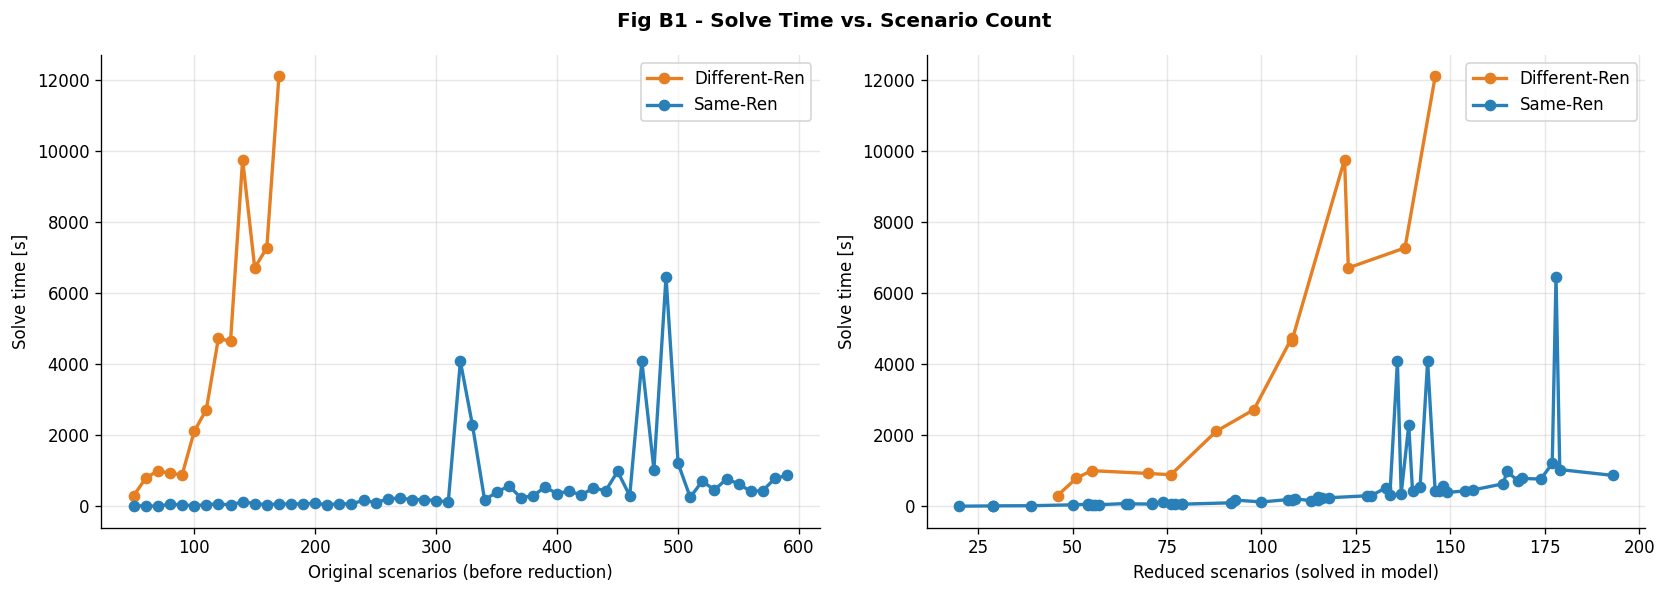

In [38]:
if not batch_ok.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Fig B1 - Solve Time vs. Scenario Count", fontweight="bold")

    for ax, xcol, xlabel in zip(
        axes,
        ["num_scenarios_original", "num_scenarios_reduced"],
        ["Original scenarios (before reduction)", "Reduced scenarios (solved in model)"],
    ):
        for method, g in batch_ok.groupby("method"):
            g = g.sort_values(xcol)
            ax.plot(g[xcol], g["solve_time_s"], marker="o", lw=2,
                    color=BATCH_METHOD_COLORS[method], label=BATCH_METHOD_LABELS[method])
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Solve time [s]")
        ax.grid(alpha=0.3)
        ax.legend()

    plt.tight_layout()
    _save(fig, "fig_b1_solve_time_vs_scenarios")
    plt.show()
else:
    print("Skipped: no batch data.")


Original scenario counts completed by BOTH methods so far: [50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170]


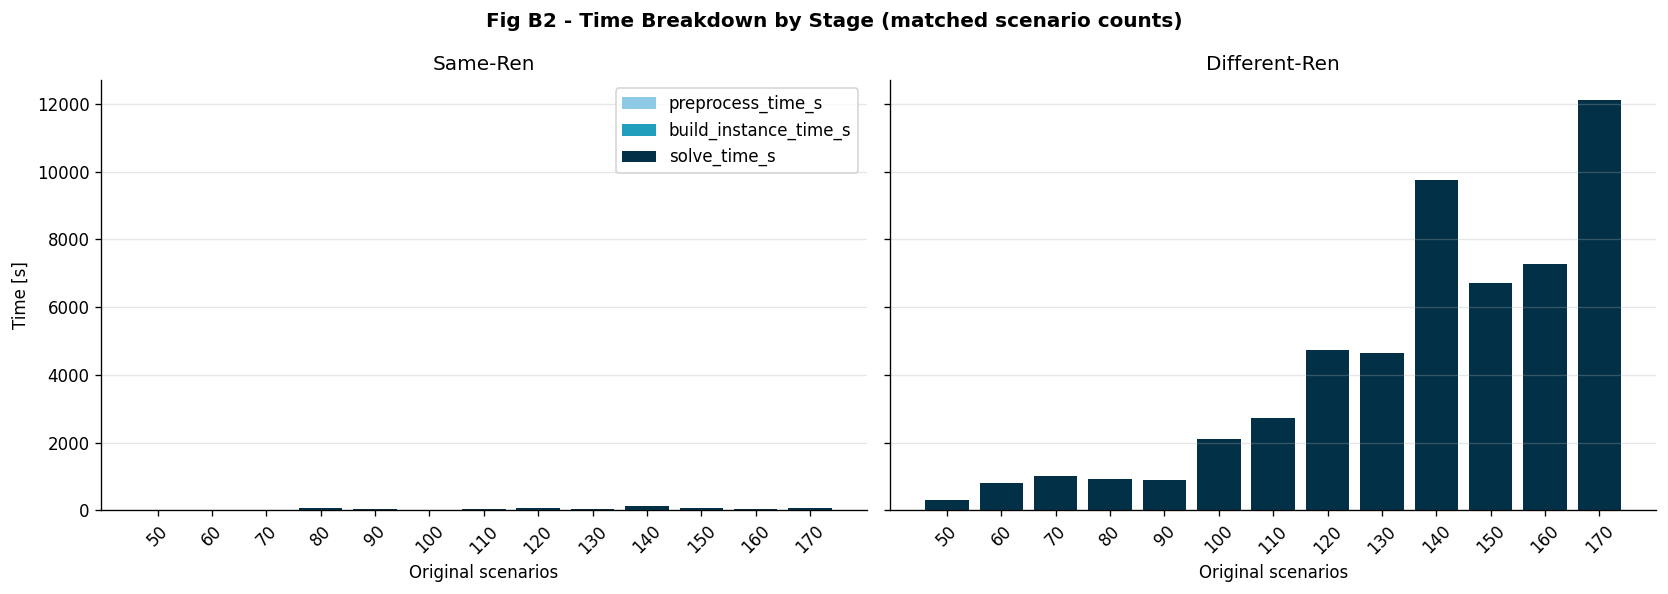

In [39]:
if not batch_ok.empty:
    common_counts = sorted(
        set(batch_ok.loc[batch_ok.method == "same_ren", "num_scenarios_original"])
        & set(batch_ok.loc[batch_ok.method == "dif_ren", "num_scenarios_original"])
    )
    print("Original scenario counts completed by BOTH methods so far:", common_counts)

    if common_counts:
        stage_colors = ["#8ecae6", "#219ebc", "#023047"]
        fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
        fig.suptitle("Fig B2 - Time Breakdown by Stage (matched scenario counts)", fontweight="bold")
        for ax, method in zip(axes, ["same_ren", "dif_ren"]):
            g = (batch_ok[batch_ok.method == method]
                 .set_index("num_scenarios_original").reindex(common_counts))
            xpos = np.arange(len(common_counts))
            bottom = np.zeros(len(common_counts))
            for col, color in zip(TIME_COLS[:3], stage_colors):
                vals = g[col].fillna(0).values
                ax.bar(xpos, vals, bottom=bottom, color=color, label=col)
                bottom += vals
            ax.set_xticks(xpos)
            ax.set_xticklabels(common_counts, rotation=45)
            ax.set_title(BATCH_METHOD_LABELS[method])
            ax.set_xlabel("Original scenarios")
            ax.grid(alpha=0.3, axis="y")
        axes[0].set_ylabel("Time [s]")
        axes[0].legend()
        plt.tight_layout()
        _save(fig, "fig_b2_time_breakdown")
        plt.show()
    else:
        print("No overlapping scenario counts between methods yet - re-run later once more jobs finish.")
else:
    print("Skipped: no batch data.")


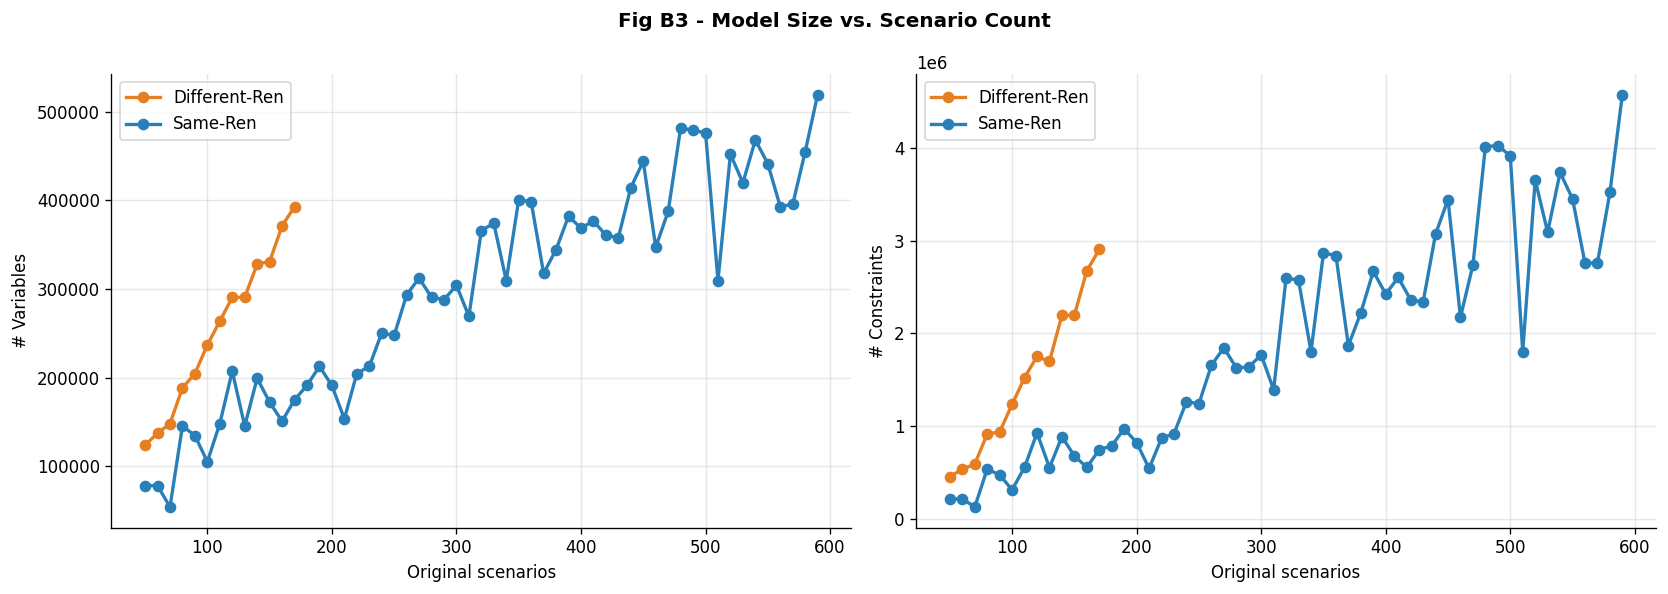

In [40]:
if not batch_ok.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Fig B3 - Model Size vs. Scenario Count", fontweight="bold")
    for ax, col, ylabel in zip(axes, ["num_variables", "num_constraints"], ["# Variables", "# Constraints"]):
        for method, g in batch_ok.groupby("method"):
            g = g.sort_values("num_scenarios_original")
            ax.plot(g["num_scenarios_original"], g[col], marker="o", lw=2,
                    color=BATCH_METHOD_COLORS[method], label=BATCH_METHOD_LABELS[method])
        ax.set_xlabel("Original scenarios")
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)
        ax.legend()
    plt.tight_layout()
    _save(fig, "fig_b3_model_size_vs_scenarios")
    plt.show()
else:
    print("Skipped: no batch data.")


### 14.2 · Insight 2 — Objective Function vs. Scenario Count

Compares the total objective value and its income/cost components between the
two methodologies, again as a function of both original and reduced scenario counts.


In [41]:
OBJ_COLS = ["obj_fun", "obj_DA_income", "obj_RM_income", "obj_IM_income",
            "obj_IB_income", "obj_IB_costs", "obj_IB_net", "obj_FD_costs"]

if not batch_ok.empty:
    print("Mean objective-function components by method and original scenario count:")
    obj_table = batch_ok.pivot_table(
        index="num_scenarios_original", columns="method_label", values=OBJ_COLS, aggfunc="mean"
    ).sort_index()
    display(obj_table)
else:
    print("Skipped: no batch data.")


Mean objective-function components by method and original scenario count:


obj_DA_income              obj_FD_costs           \
method_label           Different-Ren    Same-Ren Different-Ren Same-Ren   
num_scenarios_original                                                    
50                       -38875.7988 -51571.1304       96.2806 108.3670   
60                       -45442.7365 -48051.9860       94.7126 108.3608   
70                       -39873.7181 -51189.1019       89.3272 111.2036   
80                       -37244.1282 -46506.4061       95.3293 106.7745   
90                       -41246.3705 -53491.1363       90.4249 107.9647   
100                      -33115.3206 -49723.2064       96.8189 107.2424   
110                      -35058.7773 -54072.0088       94.9307 108.4064   
120                      -33048.5766 -57039.4093       92.3255 107.0726   
130                      -39650.6297 -47988.5522       90.6966 105.6167   
140                      -34324.2247 -42899.4013       90.6227 107.7164   
150                      -37604.4554 -51232.5644       92.8088 106.5556   
160                      -34923.9741 -52212.8543       94.1233 104.0768   
170                      -37132.6023 -51101.3936       92.7390 109.0839   
180                              NaN -51604.0281           NaN 104.9465   
190                              NaN -52168.2006           NaN 108.8245   
200                              NaN -46569.4387           NaN 108.9549   
210                              NaN -44185.8530           NaN 106.8108   
220                              NaN -47578.8511           NaN 106.6871   
230                              NaN -53576.4745           NaN 107.6604   
240                              NaN -51386.3943           NaN 106.5269   
250                              NaN -56931.4470           NaN 107.5228   
260                              NaN -50092.1658           NaN 109.6838   
270                              NaN -54768.1972           NaN 108.4486   
280                              NaN -48413.2033           NaN 108.6142   
290                              NaN -50399.6913           NaN 106.0226   
300                              NaN -49143.9334           NaN 105.0098   
310                              NaN -48723.4686           NaN 106.2137   
320                              NaN -48810.4290           NaN 106.4252   
330                              NaN -50782.0947           NaN 107.1300   
340                              NaN -49824.8775           NaN 106.0810   
350                              NaN -50974.9351           NaN 105.8354   
360                              NaN -47892.3473           NaN 107.9800   
370                              NaN -49471.7689           NaN 106.5742   
380                              NaN -48797.3371           NaN 107.0497   
390                              NaN -48282.9295           NaN 107.1220   
400                              NaN -50301.2650           NaN 105.1122   
410                              NaN -46765.5107           NaN 109.2980   
420                              NaN -45995.2445           NaN 107.6906   
430                              NaN -50445.2594           NaN 104.8371   
440                              NaN -52076.9024           NaN 108.6536   
450                              NaN -48261.3558           NaN 105.2083   
460                              NaN -49270.5712           NaN 107.5095   
470                              NaN -47566.9593           NaN 106.5317   
480                              NaN -51046.2703           NaN 106.6604   
490                              NaN -49948.7678           NaN 106.9228   
500                              NaN -50657.0508           NaN 105.4008   
510                              NaN -48440.7708           NaN 104.8384   
520                              NaN -49663.3451           NaN 108.4241   
530                              NaN -48876.0076           NaN 106.9612   
540                              NaN -49815.8434           NaN 107.5076   
550                              NaN -47530.4864

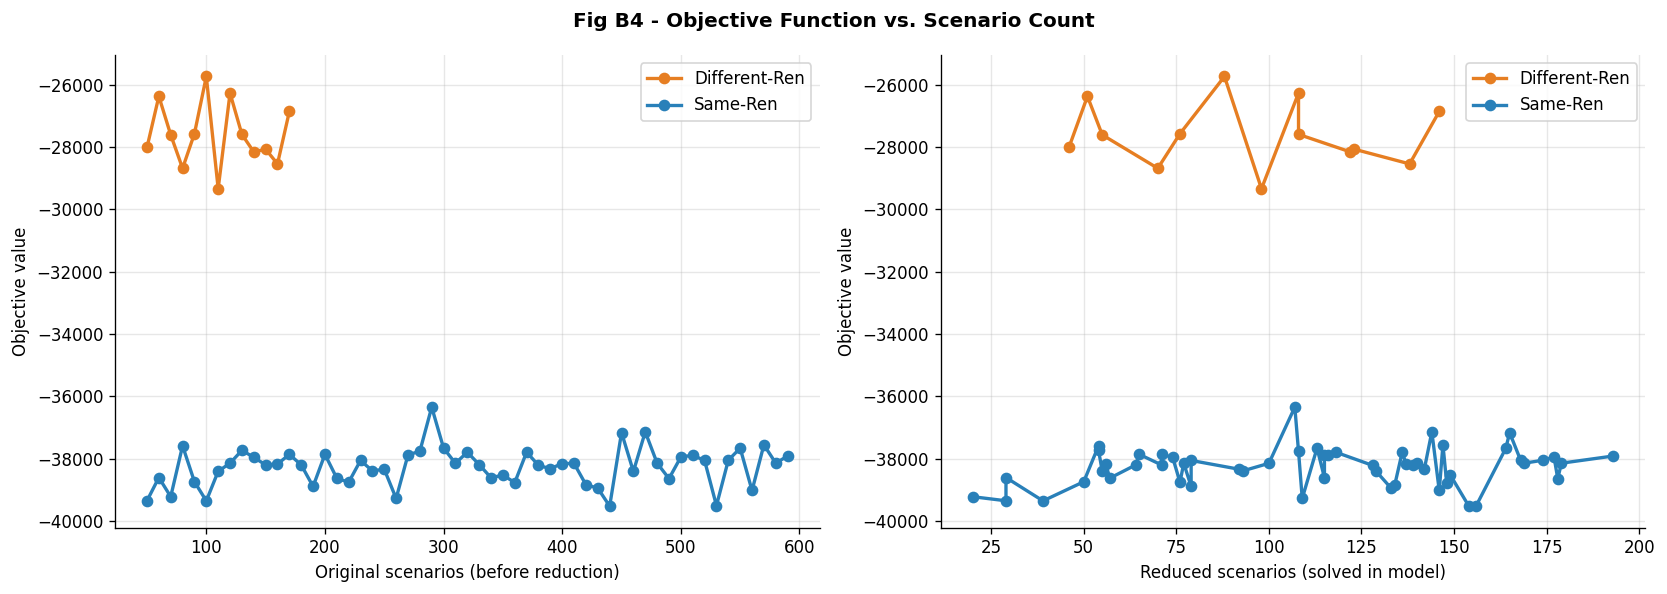

In [42]:
if not batch_ok.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Fig B4 - Objective Function vs. Scenario Count", fontweight="bold")
    for ax, xcol, xlabel in zip(
        axes,
        ["num_scenarios_original", "num_scenarios_reduced"],
        ["Original scenarios (before reduction)", "Reduced scenarios (solved in model)"],
    ):
        for method, g in batch_ok.groupby("method"):
            g = g.sort_values(xcol)
            ax.plot(g[xcol], g["obj_fun"], marker="o", lw=2,
                    color=BATCH_METHOD_COLORS[method], label=BATCH_METHOD_LABELS[method])
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Objective value")
        ax.grid(alpha=0.3)
        ax.legend()
    plt.tight_layout()
    _save(fig, "fig_b4_objective_vs_scenarios")
    plt.show()
else:
    print("Skipped: no batch data.")


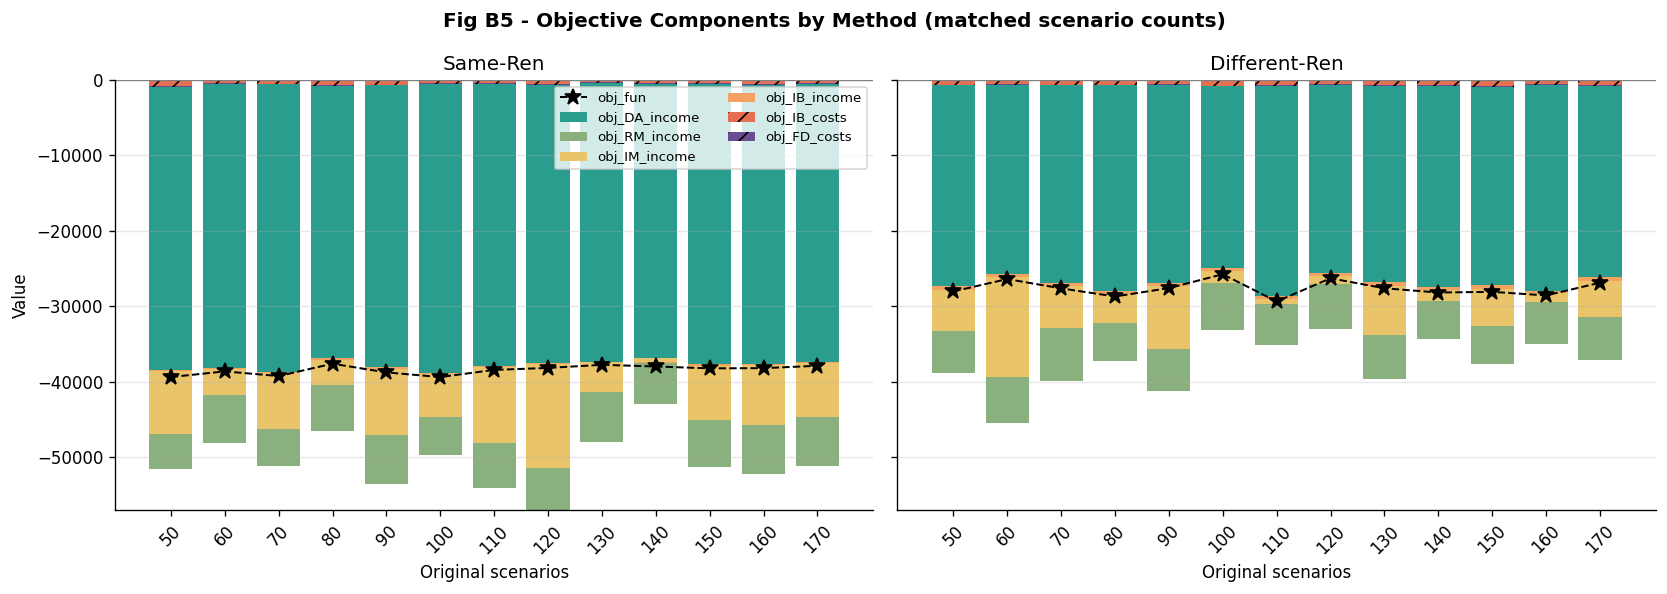

In [43]:
if not batch_ok.empty and common_counts:
    income_cols = ["obj_DA_income", "obj_RM_income", "obj_IM_income", "obj_IB_income"]
    cost_cols = ["obj_IB_costs", "obj_FD_costs"]
    income_colors = ["#2a9d8f", "#8ab17d", "#e9c46a", "#f4a261"]
    cost_colors = ["#e76f51", "#6a4c93"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    fig.suptitle("Fig B5 - Objective Components by Method (matched scenario counts)", fontweight="bold")
    for ax, method in zip(axes, ["same_ren", "dif_ren"]):
        g = (batch_ok[batch_ok.method == method]
             .set_index("num_scenarios_original").reindex(common_counts))
        xpos = np.arange(len(common_counts))

        bottom = np.zeros(len(common_counts))
        for col, color in zip(income_cols, income_colors):
            vals = g[col].fillna(0).values
            ax.bar(xpos, vals, bottom=bottom, color=color, label=col)
            bottom += vals

        bottom = np.zeros(len(common_counts))
        for col, color in zip(cost_cols, cost_colors):
            vals = -g[col].fillna(0).values  # costs plotted as negative bars
            ax.bar(xpos, vals, bottom=bottom, color=color, label=col, hatch="//")
            bottom += vals

        ax.plot(xpos, g["obj_fun"].values, "k*--", lw=1.2, ms=10, label="obj_fun")
        ax.axhline(0, color="grey", lw=0.8)
        ax.set_xticks(xpos)
        ax.set_xticklabels(common_counts, rotation=45)
        ax.set_title(BATCH_METHOD_LABELS[method])
        ax.set_xlabel("Original scenarios")
        ax.grid(alpha=0.3, axis="y")
    axes[0].set_ylabel("Value")
    axes[0].legend(fontsize=8, ncol=2)
    plt.tight_layout()
    _save(fig, "fig_b5_objective_components")
    plt.show()
else:
    print("Skipped: no batch data or no overlapping scenario counts yet.")


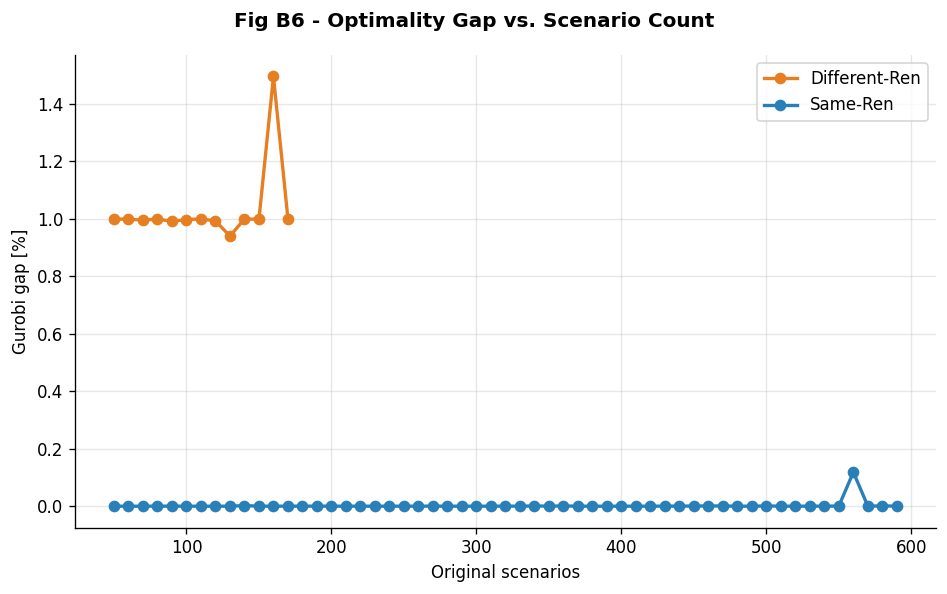

In [44]:
if not batch_ok.empty and batch_ok["gurobi_gap_pct"].notna().any():
    fig, ax = plt.subplots(figsize=(8, 5))
    fig.suptitle("Fig B6 - Optimality Gap vs. Scenario Count", fontweight="bold")
    for method, g in batch_ok.groupby("method"):
        g = g.sort_values("num_scenarios_original")
        ax.plot(g["num_scenarios_original"], g["gurobi_gap_pct"], marker="o", lw=2,
                color=BATCH_METHOD_COLORS[method], label=BATCH_METHOD_LABELS[method])
    ax.set_xlabel("Original scenarios")
    ax.set_ylabel("Gurobi gap [%]")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    _save(fig, "fig_b6_optimality_gap")
    plt.show()
else:
    print("Skipped: no gap data available.")


### 14.3 · Insight 3 — Day-Ahead Commitment Comparison

Compares the actual DA commitments (`eDA_p` = sold, `eDA_m` = bought) produced by
each methodology, matched at the **same** (or closest) original scenario count so
the comparison isolates the effect of the reduction method rather than scenario count.

Each run's `results_dir` (from the batch CSV, e.g. `.../DA/ec/001`) is converted to
its sibling market-results folder (`.../DA/market/001/DA/eDA_p.txt`) where the
per-scenario, per-period commitments are stored as one row per (reduced) scenario:
`scenario_id  probability  v_t=1 ... v_t=T`. Profiles below are probability-weighted
means across scenarios.


In [45]:
def _da_market_dir(results_dir):
    # '.../<famscen>/DA/ec/<sim>' -> '.../<famscen>/DA/market/<sim>' (see simulation_context.py)
    results_dir = str(results_dir)
    marker = os.sep + "ec" + os.sep
    if marker not in results_dir:
        return None
    return results_dir.replace(marker, os.sep + "market" + os.sep)


def load_da_commitment(results_dir, filename):
    # eDA_p.txt / eDA_m.txt: rows = reduced scenarios, cols = [id, prob, v_t=1..T]
    market_dir = _da_market_dir(results_dir)
    if market_dir is None:
        return None
    path = os.path.join(market_dir, "DA", filename)
    if not os.path.isfile(path):
        return None
    df = pd.read_csv(path, sep=r"\s+", header=None, engine="python")
    if df.shape[1] < 3:
        return None
    probs = df.iloc[:, 1].to_numpy(dtype=float)
    values = df.iloc[:, 2:].to_numpy(dtype=float)
    if probs.sum() > 0 and not np.isclose(probs.sum(), 1.0, atol=1e-3):
        probs = probs / probs.sum()
    return probs, values  # probs: (S,), values: (S, T)


def weighted_commitment_profile(results_dir):
    # Probability-weighted mean eDA_p, eDA_m and net (sold - bought) profile over T periods.
    p = load_da_commitment(results_dir, "eDA_p.txt")
    m = load_da_commitment(results_dir, "eDA_m.txt")
    if p is None or m is None:
        return None
    probs_p, vals_p = p
    probs_m, vals_m = m
    mean_p = (probs_p[:, None] * vals_p).sum(axis=0)
    mean_m = (probs_m[:, None] * vals_m).sum(axis=0)
    return mean_p, mean_m, mean_p - mean_m

print("Commitment-loading helpers ready.")


Commitment-loading helpers ready.


In [46]:
commit_records = []
if not batch_ok.empty:
    for _, row in batch_ok.iterrows():
        prof = weighted_commitment_profile(row["results_dir"])
        if prof is None:
            continue
        mean_p, mean_m, net = prof
        dt_h = 24.0 / len(mean_p)  # hours per period (e.g. 0.25 for 15-min, 96 periods)
        commit_records.append({
            "method": row["method"],
            "num_scenarios_original": row["num_scenarios_original"],
            "num_scenarios_reduced": row["num_scenarios_reduced"],
            "results_dir": row["results_dir"],
            "T_periods": len(mean_p),
            "total_sold_MWh": mean_p.sum() * dt_h,
            "total_bought_MWh": mean_m.sum() * dt_h,
            "net_MWh": net.sum() * dt_h,
            "peak_sold_MW": mean_p.max(),
            "peak_bought_MW": mean_m.max(),
        })

commit_df = pd.DataFrame(commit_records)
if not commit_df.empty:
    commit_df["method_label"] = commit_df["method"].map(BATCH_METHOD_LABELS)
    commit_df = commit_df.sort_values(["method", "num_scenarios_original"]).reset_index(drop=True)

print(f"Loaded commitment profiles for {len(commit_df)} / {len(batch_ok)} 'ok' runs.")
if not commit_df.empty:
    display(commit_df.drop(columns=["results_dir"]).head(10))


Loaded commitment profiles for 68 / 68 'ok' runs.


,method,num_scenarios_original,num_scenarios_reduced,T_periods,total_sold_MWh,total_bought_MWh,net_MWh,peak_sold_MW,peak_bought_MW,method_label
0,dif_ren,50,46,96,0.0000,118.5485,-118.5485,0.0000,11.0300,Different-Ren
1,dif_ren,60,51,96,0.0000,136.4254,-136.4254,0.0000,11.0300,Different-Ren
2,dif_ren,70,55,96,0.0000,117.2259,-117.2259,0.0000,11.0300,Different-Ren
3,dif_ren,80,70,96,0.0000,109.2306,-109.2306,0.0000,11.0300,Different-Ren
4,dif_ren,90,76,96,0.0000,124.8998,-124.8998,0.0000,11.0300,Different-Ren
5,dif_ren,100,88,96,0.0000,108.3854,-108.3854,0.0000,11.0300,Different-Ren
6,dif_ren,110,98,96,0.0000,105.5132,-105.5132,0.0000,11.0300,Different-Ren
7,dif_ren,120,108,96,0.0000,108.3574,-108.3574,0.0000,11.0300,Different-Ren
8,dif_ren,130,108,96,0.0000,121.1322,-121.1322,0.0000,11.0300,Different-Ren
9,dif_ren,140,122,96,0.0000,106.8418,-106.8418,0.0000,11.0300,Different-Ren


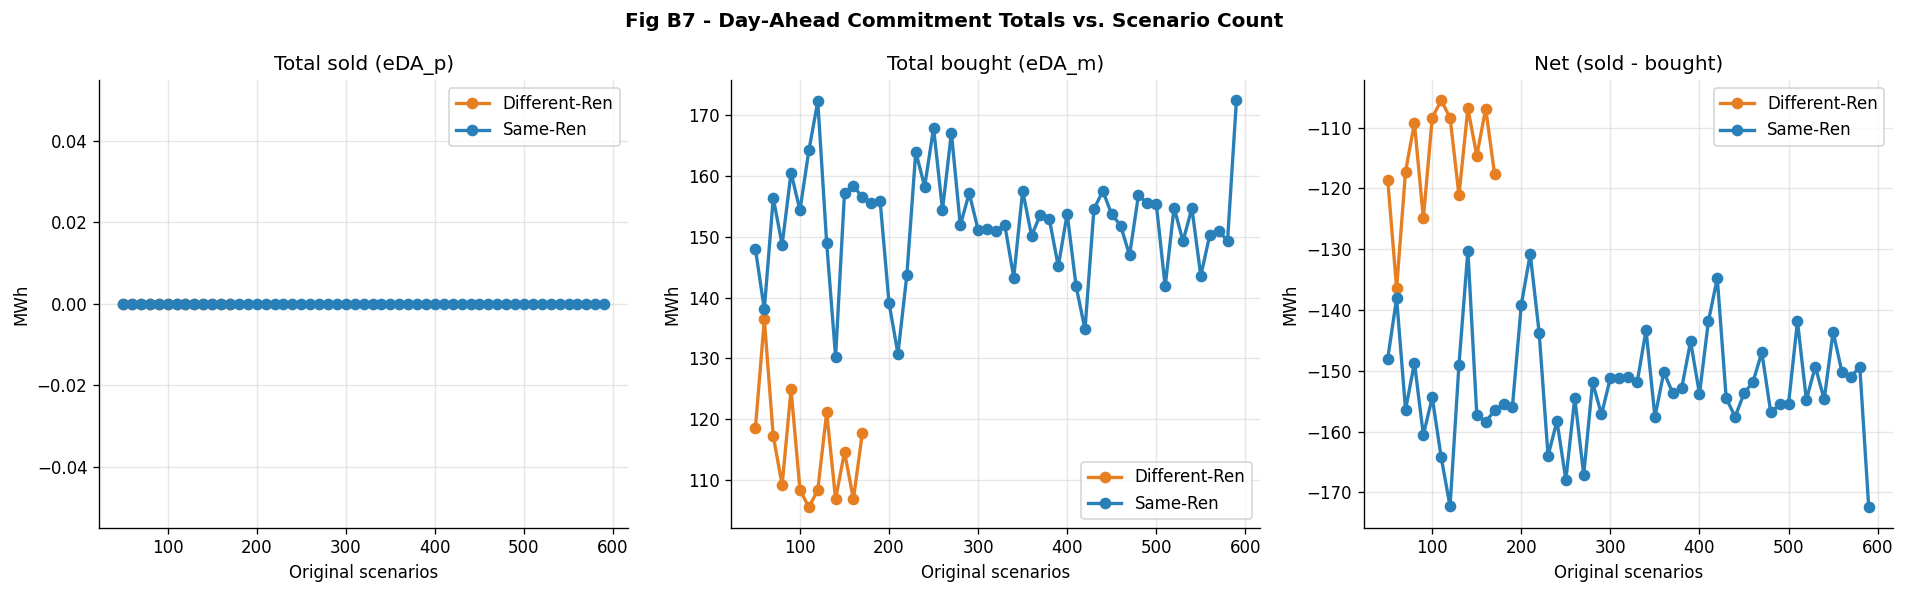

In [47]:
if not commit_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle("Fig B7 - Day-Ahead Commitment Totals vs. Scenario Count", fontweight="bold")
    for ax, col, title in zip(
        axes,
        ["total_sold_MWh", "total_bought_MWh", "net_MWh"],
        ["Total sold (eDA_p)", "Total bought (eDA_m)", "Net (sold - bought)"],
    ):
        for method, g in commit_df.groupby("method"):
            g = g.sort_values("num_scenarios_original")
            ax.plot(g["num_scenarios_original"], g[col], marker="o", lw=2,
                    color=BATCH_METHOD_COLORS[method], label=BATCH_METHOD_LABELS[method])
        ax.set_title(title)
        ax.set_xlabel("Original scenarios")
        ax.set_ylabel("MWh")
        ax.grid(alpha=0.3)
        ax.legend()
    plt.tight_layout()
    _save(fig, "fig_b7_commitment_totals")
    plt.show()
else:
    print("Skipped: no commitment data available yet (result files not generated, or path pattern mismatch).")


Scenario counts shown (matched between methods): [50, 70, 100, 120, 150, 170]


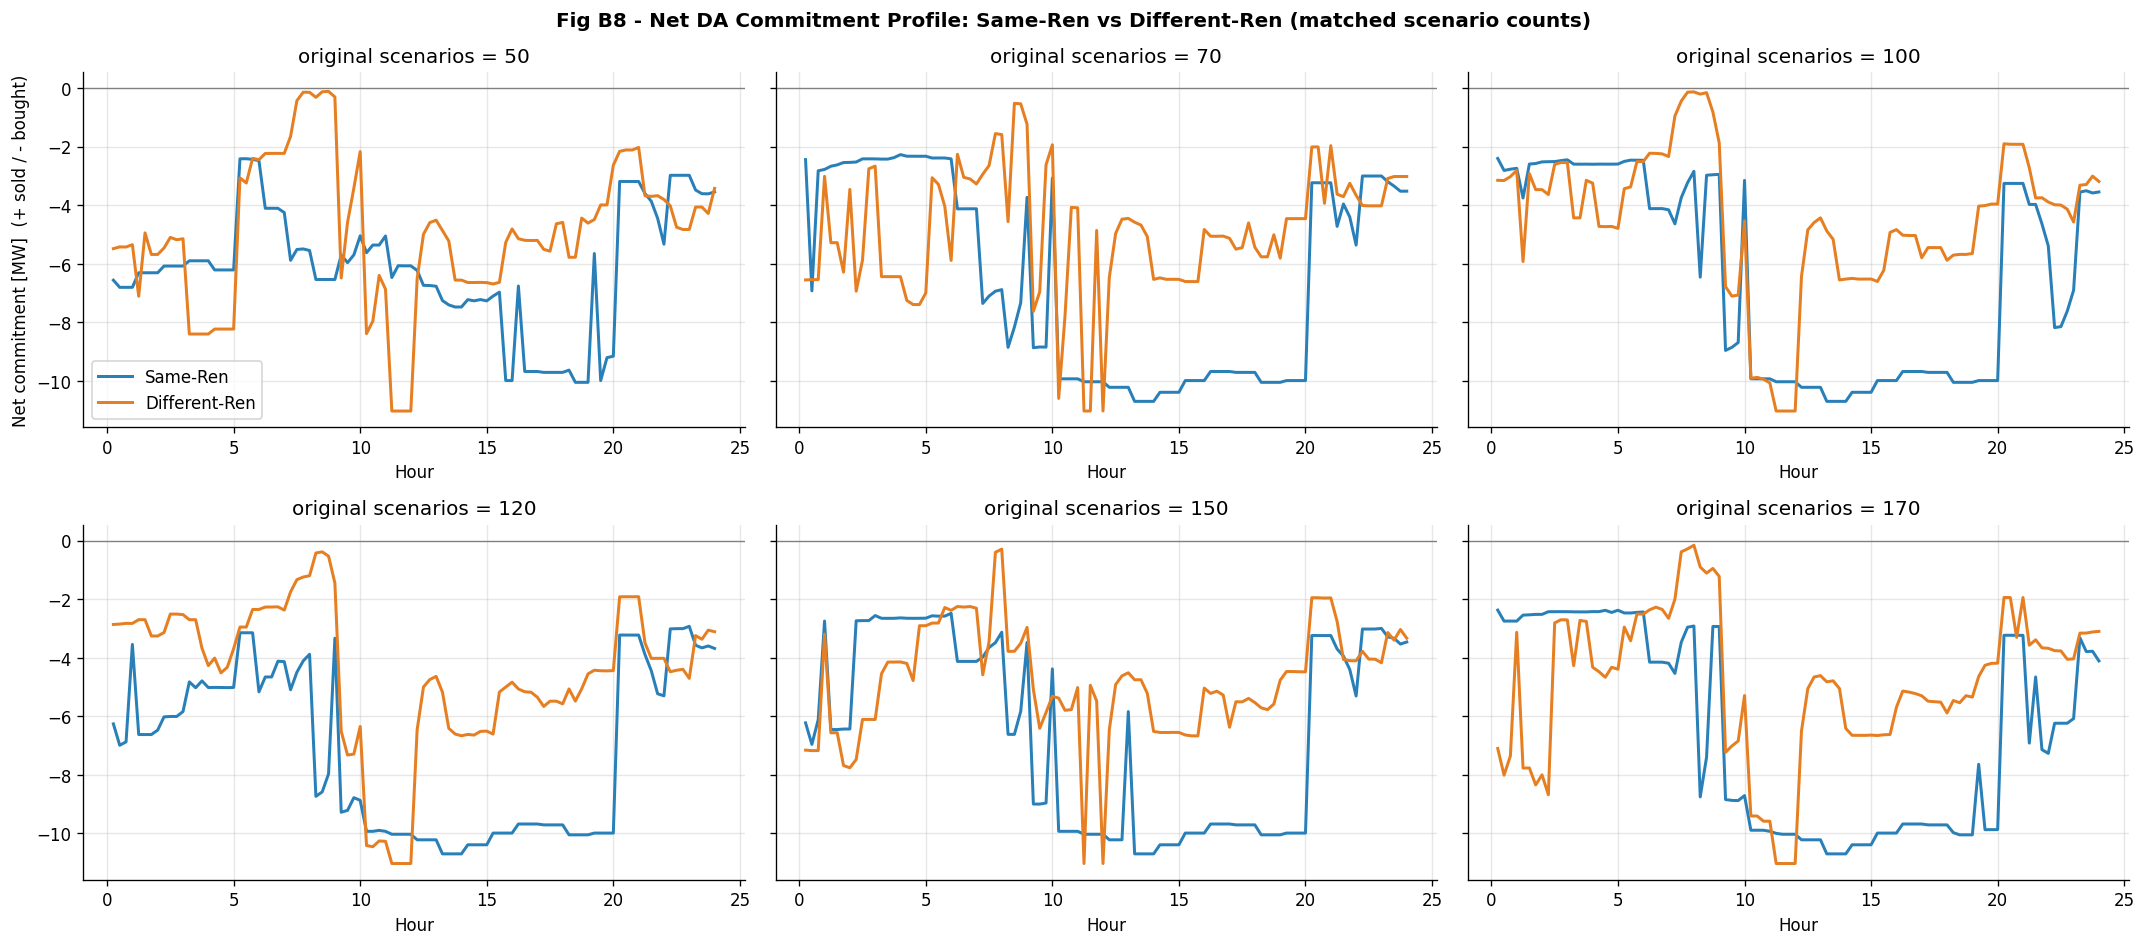

In [48]:
if not commit_df.empty:
    matched_counts = sorted(
        set(commit_df.loc[commit_df.method == "same_ren", "num_scenarios_original"])
        & set(commit_df.loc[commit_df.method == "dif_ren", "num_scenarios_original"])
    )
    show_counts = matched_counts
    if len(matched_counts) > 6:
        idx = np.linspace(0, len(matched_counts) - 1, 6).round().astype(int)
        show_counts = [matched_counts[i] for i in sorted(set(idx))]
    print("Scenario counts shown (matched between methods):", show_counts)

    if show_counts:
        ncols = min(3, len(show_counts))
        nrows = int(np.ceil(len(show_counts) / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), sharey=True, squeeze=False)
        axes = axes.flatten()
        fig.suptitle("Fig B8 - Net DA Commitment Profile: Same-Ren vs Different-Ren (matched scenario counts)",
                     fontweight="bold")
        for ax, sc in zip(axes, show_counts):
            for method in ["same_ren", "dif_ren"]:
                r = batch_ok[(batch_ok.method == method) & (batch_ok.num_scenarios_original == sc)]
                if r.empty:
                    continue
                prof = weighted_commitment_profile(r.iloc[0]["results_dir"])
                if prof is None:
                    continue
                _, _, net = prof
                t = np.arange(1, len(net) + 1) * (24.0 / len(net))
                ax.plot(t, net, lw=1.8, color=BATCH_METHOD_COLORS[method], label=BATCH_METHOD_LABELS[method])
            ax.axhline(0, color="grey", lw=0.8)
            ax.set_title(f"original scenarios = {sc}")
            ax.set_xlabel("Hour")
            ax.grid(alpha=0.3)
        axes[0].set_ylabel("Net commitment [MW]  (+ sold / - bought)")
        axes[0].legend()
        for ax in axes[len(show_counts):]:
            ax.axis("off")
        plt.tight_layout()
        _save(fig, "fig_b8_commitment_profiles")
        plt.show()
    else:
        print("No scenario count is present for both methods yet - re-run later.")
else:
    print("Skipped: no commitment data.")


,num_scenarios_original,mean_abs_diff_MW
0,50,2.4230
1,60,3.6945
2,70,3.2495
3,80,2.6425
4,90,2.6424
5,100,2.5007
6,110,2.7179
7,120,2.9083
8,130,3.3640
9,140,2.3352


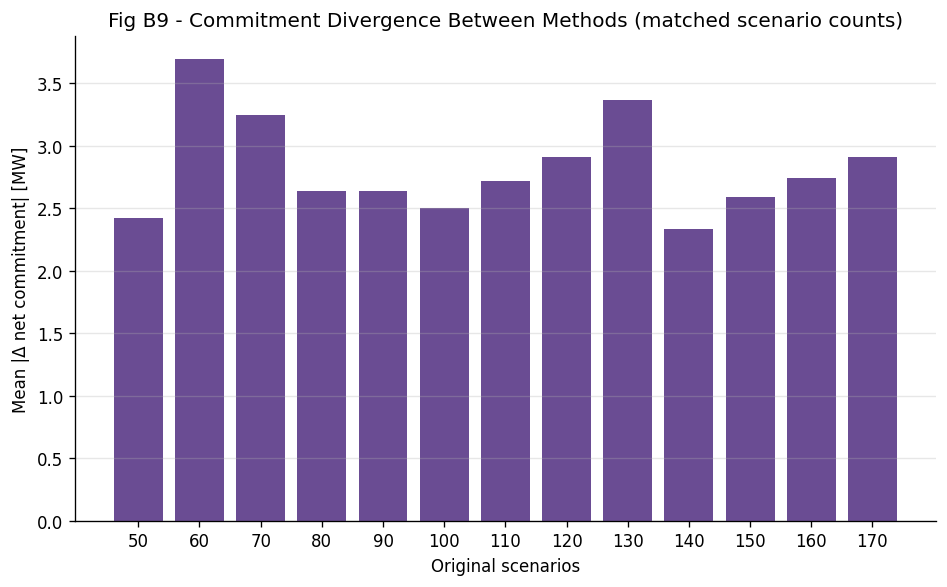

In [49]:
if not commit_df.empty and matched_counts:
    diffs = []
    for sc in matched_counts:
        profiles = {}
        for method in ["same_ren", "dif_ren"]:
            r = batch_ok[(batch_ok.method == method) & (batch_ok.num_scenarios_original == sc)]
            if r.empty:
                continue
            prof = weighted_commitment_profile(r.iloc[0]["results_dir"])
            if prof is None:
                continue
            profiles[method] = prof[2]  # net profile
        if "same_ren" in profiles and "dif_ren" in profiles and \
                len(profiles["same_ren"]) == len(profiles["dif_ren"]):
            mad = float(np.mean(np.abs(profiles["same_ren"] - profiles["dif_ren"])))
            diffs.append({"num_scenarios_original": sc, "mean_abs_diff_MW": mad})

    diff_df = pd.DataFrame(diffs)
    display(diff_df)

    if not diff_df.empty:
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.bar(diff_df["num_scenarios_original"].astype(str), diff_df["mean_abs_diff_MW"], color="#6a4c93")
        ax.set_xlabel("Original scenarios")
        ax.set_ylabel("Mean |Δ net commitment| [MW]")
        ax.set_title("Fig B9 - Commitment Divergence Between Methods (matched scenario counts)")
        ax.grid(alpha=0.3, axis="y")
        plt.tight_layout()
        _save(fig, "fig_b9_commitment_divergence")
        plt.show()
else:
    print("Skipped: no matched scenario counts with commitment data yet.")


### 14.4 · Additional Metrics

A few extra diagnostics that are useful when judging which reduction method is
"better" beyond the three requested comparisons:

- **Reduction ratio** — how aggressively each method prunes the original scenario tree.
- **Solve time per (reduced) scenario** — a size-normalized efficiency metric, since
  `dif_ren` and `same_ren` can keep a different number of scenarios for the same
  original count.
- **Run-status summary** — surfaces any `error` / `timeout_no_solution` rows so
  incomplete batches are visible at a glance.


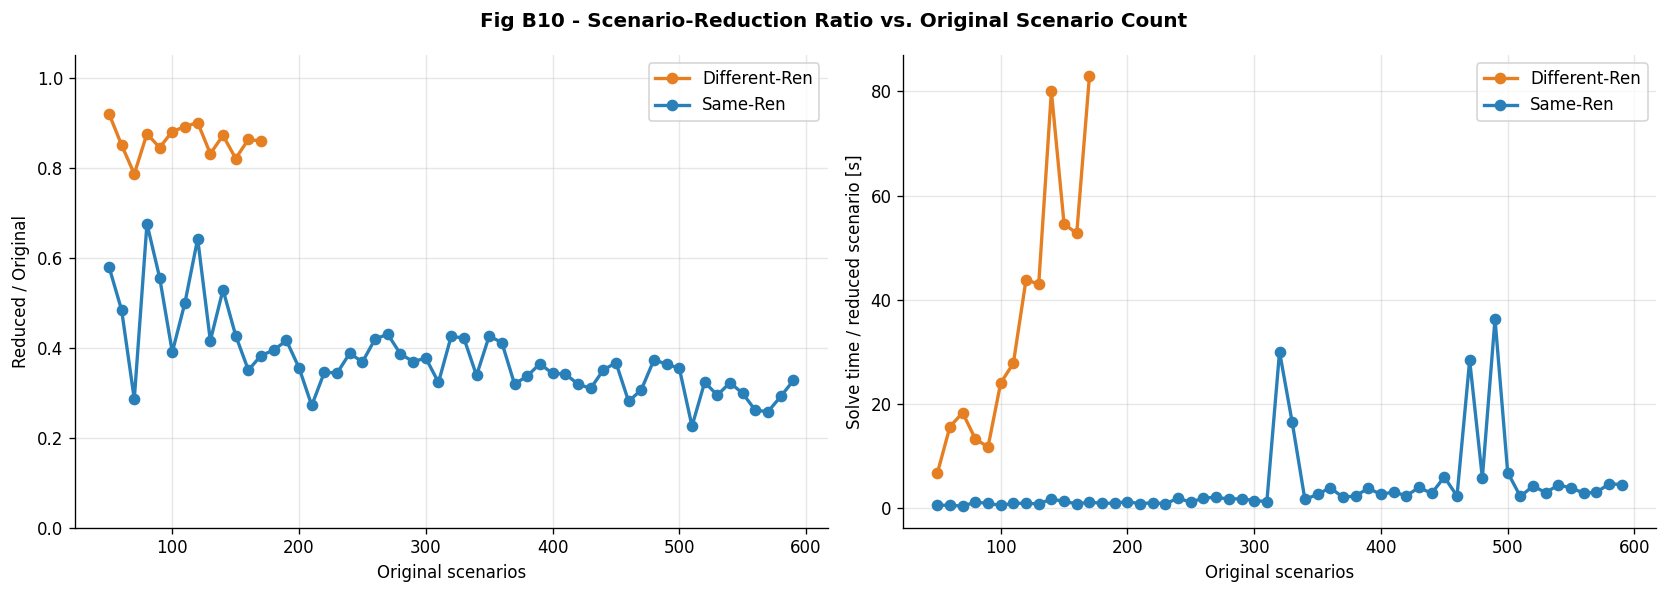

In [50]:
if not batch_ok.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Fig B10 - Scenario-Reduction Ratio vs. Original Scenario Count", fontweight="bold")

    ax = axes[0]
    for method, g in batch_ok.groupby("method"):
        g = g.sort_values("num_scenarios_original")
        ax.plot(g["num_scenarios_original"], g["reduction_ratio"], marker="o", lw=2,
                color=BATCH_METHOD_COLORS[method], label=BATCH_METHOD_LABELS[method])
    ax.set_xlabel("Original scenarios")
    ax.set_ylabel("Reduced / Original")
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.3)
    ax.legend()

    ax = axes[1]
    for method, g in batch_ok.groupby("method"):
        g = g.sort_values("num_scenarios_original")
        ax.plot(g["num_scenarios_original"], g["solve_time_per_scenario_s"], marker="o", lw=2,
                color=BATCH_METHOD_COLORS[method], label=BATCH_METHOD_LABELS[method])
    ax.set_xlabel("Original scenarios")
    ax.set_ylabel("Solve time / reduced scenario [s]")
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()
    _save(fig, "fig_b10_reduction_ratio_and_efficiency")
    plt.show()
else:
    print("Skipped: no batch data.")


In [51]:
if not batch_latest.empty:
    print("Run-status summary by method (latest attempt per scenario-count folder):")
    display(batch_latest.groupby(["method", "status"]).size().rename("n_runs").to_frame())

    if not batch_not_ok.empty:
        print("\nNon-'ok' runs - latest attempt only (inspect 'error' for details):")
        display(batch_not_ok[["method", "num_scenarios_folder", "status",
                               "time_limit_s", "solve_time_s", "error"]]
                .sort_values(["method", "num_scenarios_folder"]))
    else:
        print("\nAll loaded scenario-count folders completed with status 'ok'.")
else:
    print("Skipped: no batch data.")


Run-status summary by method (latest attempt per scenario-count folder):


n_runs
method   status                     
dif_ren  ok                       13
         timeout_no_solution      13
same_ren ok                       55


Non-'ok' runs - latest attempt only (inspect 'error' for details):


,method,num_scenarios_folder,status,time_limit_s,solve_time_s,error
84,dif_ren,180,timeout_no_solution,14400,14495.5853,ValueError: Cannot load a SolverResults object...
85,dif_ren,190,timeout_no_solution,14400,14506.0084,ValueError: Cannot load a SolverResults object...
86,dif_ren,200,timeout_no_solution,14400,14510.0504,ValueError: Cannot load a SolverResults object...
88,dif_ren,210,timeout_no_solution,14400,14520.8541,ValueError: Cannot load a SolverResults object...
87,dif_ren,220,timeout_no_solution,14400,14514.1444,ValueError: Cannot load a SolverResults object...
89,dif_ren,230,timeout_no_solution,14400,14534.1790,ValueError: Cannot load a SolverResults object...
90,dif_ren,240,timeout_no_solution,14400,14551.6284,ValueError: Cannot load a SolverResults object...
93,dif_ren,250,timeout_no_solution,14400,14590.2904,ValueError: Cannot load a SolverResults object...
92,dif_ren,260,timeout_no_solution,14400,14578.3640,ValueError: Cannot load a SolverResults object...
91,dif_ren,270,timeout_no_solution,14400,14562.0996,ValueError: Cannot load a SolverResults object...


### 14.5 · Export Batch Summary Tables


In [52]:
if CONFIG["save_figs"]:
    os.makedirs(CONFIG["fig_dir"], exist_ok=True)
    if not batch_ok.empty:
        out1 = os.path.join(CONFIG["fig_dir"], "batch_summary.csv")
        batch_ok.drop(columns=[c for c in ["traceback"] if c in batch_ok.columns]).to_csv(out1, index=False)
        print(f"Saved -> {out1}")
    if not commit_df.empty:
        out2 = os.path.join(CONFIG["fig_dir"], "commitment_summary.csv")
        commit_df.drop(columns=["results_dir"]).to_csv(out2, index=False)
        print(f"Saved -> {out2}")
else:
    print("Set CONFIG['save_figs'] = True to export batch_summary.csv / commitment_summary.csv.")


Set CONFIG['save_figs'] = True to export batch_summary.csv / commitment_summary.csv.
